# IFA2 Interconnector — Spread-Direct OU Model
**MSc Climate Change Finance and Investment**

$$S_t = f_S(t, h) + X_t + Y_t$$

- $f_S(t, h)$ — deterministic: OLS (annual Fourier, linear trend, weekend/holiday dummy, 24 effects-coded hour dummies)
- $X_t$ — mean-reverting OU: $dX_t = \alpha(0 - X_t)\,dt + \sigma\,dW_t$
- $Y_t$ — zero-mean pure jump: $Y_t = e^{-\beta\Delta t}Y_{t-1} + \Delta J^+_t - \Delta J^-_t$

10,000 paths × 20 projection years; three Annex M (DESNZ Feb 2026) scenarios.

## Section 1: Configuration & Imports

In [1]:
from pathlib import Path
import calendar
import csv as _csv
import shutil
import openpyxl
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats as sp_stats
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.linewidth': 0.3, 'grid.alpha': 0.5, 'font.size': 10,
})

IC_DIR     = Path('/Users/aadesh/Documents/IC')
EXCEL_PATH = IC_DIR / 'GB-FR07.xlsx'
OUTPUT_DIR = IC_DIR / 'M2'
OUTPUT_DIR.mkdir(exist_ok=True)

REGIME_START    = 2021   # IFA2 Window 1 commissioning year
PROJ_START_YEAR = 2026   # first year without a complete Ofgem actual
N_PROJ_YEARS    = 20     # 2026-2045  (total regime = 25 yrs: 2021-2045)
CAPACITY_MW     = 1_000
AVAILABILITY    = 0.9659
N_PATHS         = 10_000
RANDOM_SEED     = 42
PROJ_TAU_GROWTH = 0.0
ANCHOR_DATE     = pd.Timestamp('2025-01-01')

# Ofgem-disclosed gross congestion revenues (net of market costs), GBPm
# 2021 not separately disclosed (commissioning / ramp-up year)
ACTUALS = {2022: 69.6, 2023: 100.8, 2024: 101.6, 2025: 72.2}   # Turnover from audited accounts

print(f'Config: REGIME_START={REGIME_START}  PROJ={PROJ_START_YEAR}-{PROJ_START_YEAR+N_PROJ_YEARS-1}')
print(f'        CAPACITY={CAPACITY_MW}MW  AVAILABILITY={AVAILABILITY}')
print(f'        N_PATHS={N_PATHS:,}  ANCHOR={ANCHOR_DATE.date()}')


Config: REGIME_START=2021  PROJ=2026-2045
        CAPACITY=1000MW  AVAILABILITY=0.9659
        N_PATHS=10,000  ANCHOR=2025-01-01


## Section 2: Data Loading

Data source: `GB-FR07.xlsx` — Bloomberg GB and FR hourly electricity prices + EUR/GBP FX.

| Sheet | Content | Units |
|---|---|---|
| `GB_FINAL` | N2EX GB day-ahead hourly prices | GBP/MWh |
| `FR_FINAL` | EPEX France day-ahead hourly prices | EUR/MWh |
| `GBP-EUR` | Bloomberg EUR/GBP daily FX rate | GBP per 1 EUR |

**Wide-to-long:** Each sheet stores dates as rows, hours (H01–H24) as columns. `_wide_to_hourly()` pivots to a timestamp-indexed Series.

**FX convention:** FR_price_GBP = FR_price_EUR × fx_eur_gbp (GBP per EUR — multiply, not divide).

In [2]:
SHORT_GAP_H = 4

def _wide_to_hourly(wide_df, value_col):
    df = wide_df.rename(columns={'Unnamed: 0': 'date'}).copy()
    df['date'] = pd.to_datetime(df['date'])
    hour_cols = sorted([c for c in df.columns if c.startswith('H') and c[1:].isdigit()],
                       key=lambda x: int(x[1:]))
    melted = df.melt(id_vars='date', value_vars=hour_cols,
                     var_name='hour_col', value_name=value_col)
    melted['offset']    = melted['hour_col'].str[1:].astype(int) - 1
    melted['timestamp'] = melted['date'] + pd.to_timedelta(melted['offset'], unit='h')
    return melted.set_index('timestamp')[value_col].sort_index().astype(float)

xl       = pd.ExcelFile(EXCEL_PATH)
gb_wide  = xl.parse('GB_FINAL')
fr_wide  = xl.parse('FR_FINAL')
fx_daily = xl.parse('GBP-EUR')

gb_s = _wide_to_hourly(gb_wide, 'gb_price_gbp')
fr_s = _wide_to_hourly(fr_wide, 'fr_price_eur')

fx = fx_daily.copy()
fx.columns = ['date', 'fx_eur_gbp']
fx['date'] = pd.to_datetime(fx['date'])
fx = fx.dropna(subset=['fx_eur_gbp']).set_index('date').sort_index()
fx = fx.reindex(pd.date_range(fx.index.min(), fx.index.max(), freq='D')).ffill()

print(f'GB:  {len(gb_s):,} hourly obs  ({gb_s.index.min().date()} to {gb_s.index.max().date()})')
print(f'FR:  {len(fr_s):,} hourly obs  ({fr_s.index.min().date()} to {fr_s.index.max().date()})')
print(f'FX:  {len(fx):,} daily obs  ({fx.index.min().date()} to {fx.index.max().date()})')


GB:  39,984 hourly obs  (2021-12-09 to 2026-07-07)
FR:  39,984 hourly obs  (2021-12-09 to 2026-07-07)
FX:  2,014 daily obs  (2021-01-01 to 2026-07-07)


## Section 3: Data Cleaning & Validation

1. Align GB and FR to common date range
2. Reindex to complete hourly grid — surfaces gaps
3. Fill short gaps (≤4 hours) by linear interpolation
4. Forward-fill FX from business-day to hourly frequency
5. Convert FR prices EUR → GBP; compute spread = GB − FR
6. Aggregate to daily means for descriptive statistics

**The hourly panel is retained throughout** — the OLS in Section 7 is fitted on the 36,984 hourly spread observations, following Abadie's approach of modelling hourly seasonality.

In [3]:
panel = pd.concat([gb_s, fr_s], axis=1).sort_index()
panel = panel[~panel.index.duplicated(keep='last')]
start = max(panel['gb_price_gbp'].first_valid_index(),
            panel['fr_price_eur'].first_valid_index())
end   = min(panel['gb_price_gbp'].last_valid_index(),
            panel['fr_price_eur'].last_valid_index())
panel = panel.loc[start:end]

panel = panel.reindex(pd.date_range(panel.index.min(), panel.index.max(), freq='h'))
n_missing = panel.isna().any(axis=1).sum()
panel = panel.interpolate(method='linear', limit=SHORT_GAP_H).dropna()

panel['fx_eur_gbp']   = pd.Series(
    panel.index.normalize().map(fx['fx_eur_gbp']), index=panel.index
).bfill().ffill()
panel['fr_price_gbp'] = panel['fr_price_eur'] * panel['fx_eur_gbp']
panel['spread_gbp']   = panel['gb_price_gbp'] - panel['fr_price_gbp']
panel = panel.dropna(subset=['gb_price_gbp', 'fr_price_gbp', 'spread_gbp'])

# Deflate observed prices from nominal to 2016/17-RPI-real.
# Uses actual FPA model Input sheet row 97 (CHAW annual average, Jan 1987=100).
# All downstream sections (OLS, OU, back-test) then work on the same price basis
# as the Annex M projected spreads and the regulatory cap/floor.
_HIST_RPI = {  # FPA Input row 97 values for historical sample years
    2021: 310.794, 2022: 320.864, 2023: 331.260,
    2024: 341.993, 2025: 353.073, 2026: 364.513,
}
_HIST_RPI_MAX = _HIST_RPI[max(_HIST_RPI)]  # 2026 RPI fallback for years beyond panel
_RPI_1617 = 264.992  # FPA row 96: 2016/17 CHAW base
_rpi_defl = pd.Series(
    [_RPI_1617 / _HIST_RPI.get(d.year, _HIST_RPI_MAX) for d in panel.index],
    index=panel.index
)
panel['gb_price_gbp'] = panel['gb_price_gbp'] * _rpi_defl
panel['fr_price_gbp'] = panel['fr_price_gbp'] * _rpi_defl
panel['spread_gbp']   = panel['spread_gbp']   * _rpi_defl

daily       = panel[['gb_price_gbp', 'fr_price_gbp', 'spread_gbp']].resample('D').mean().dropna()
_sample_end = daily.index.max()

print(f'Hourly panel: {panel.index.min().date()} to {panel.index.max().date()}'
      f'  ({len(panel):,} obs, {n_missing} gaps filled)')
print(f'Daily series: {daily.index.min().date()} to {_sample_end.date()}'
      f'  ({len(daily):,} days)')
print(f'Hourly spread retained for OLS: {len(panel):,} obs')

# ── Public holidays — GB and France (fixed dates) ──────────────────────
# Source: Fixed_Public_Holidays_GB_France.xlsx
_hol_df = pd.read_excel(
    '/Users/aadesh/Downloads/Fixed_Public_Holidays_GB_France.xlsx',
    sheet_name='Fixed Public Holidays'
)

def _make_holiday_dates(years, df, country_col):
    '''Build set of Timestamps for fixed public holidays in given years.'''
    dates = set()
    for _, row in df[df[country_col] == 'Yes'].iterrows():
        for yr in years:
            try:
                dates.add(pd.Timestamp(yr, int(row['Month']), int(row['Day'])))
            except ValueError:
                pass
    return dates

_panel_years = range(panel.index.year.min(), panel.index.year.max() + 1)
GB_HOLIDAYS = _make_holiday_dates(_panel_years, _hol_df, 'GB')
FR_HOLIDAYS = _make_holiday_dates(_panel_years, _hol_df, 'France')

print(f'Holiday dates loaded: {len(GB_HOLIDAYS)} GB, {len(FR_HOLIDAYS)} FR '
      f'over {len(_panel_years)} years')
print('GB sample:', sorted(GB_HOLIDAYS)[:4])
print('FR sample:', sorted(FR_HOLIDAYS)[:4])

Hourly panel: 2021-12-09 to 2026-07-07  (40,008 obs, 151 gaps filled)
Daily series: 2021-12-09 to 2026-07-07  (1,672 days)
Hourly spread retained for OLS: 40,008 obs
Holiday dates loaded: 24 GB, 48 FR over 6 years
GB sample: [Timestamp('2021-01-01 00:00:00'), Timestamp('2021-05-04 00:00:00'), Timestamp('2021-12-25 00:00:00'), Timestamp('2021-12-26 00:00:00')]
FR sample: [Timestamp('2021-01-01 00:00:00'), Timestamp('2021-05-01 00:00:00'), Timestamp('2021-05-08 00:00:00'), Timestamp('2021-07-14 00:00:00')]


## Section 4: Descriptive Statistics

Level statistics and ADF unit-root tests. We expect to reject the unit-root null for the spread — stationarity is required for OU estimation and consistent with arbitrage limits.

In [4]:
stats_data = {}
for col, label in [('gb_price_gbp', 'GB price (GBP/MWh)'),
                    ('fr_price_gbp', 'FR price (GBP/MWh)'),
                    ('spread_gbp',   'Spread GB-FR (GBP/MWh)')]:
    s = daily[col]
    stats_data[label] = {
        'N':               len(s),
        'Mean':            round(s.mean(), 3),
        'Std Dev':         round(s.std(), 3),
        'Skewness':        round(sp_stats.skew(s), 3),
        'Excess Kurtosis': round(sp_stats.kurtosis(s), 3),
        'Min':             round(s.min(), 2),
        'Max':             round(s.max(), 2),
    }

print('Descriptive Statistics (daily averages):')
print(pd.DataFrame(stats_data).T.to_string())

print()
print(f'  {"Series":<22}  {"ADF stat":>10}  {"p-value":>10}  {"Result"}')
print('  ' + '-' * 65)
for col, label in [('gb_price_gbp', 'GB price'),
                    ('fr_price_gbp', 'FR price'),
                    ('spread_gbp',   'Spread GB-FR')]:
    stat, p, _, _, crit, _ = adfuller(daily[col].dropna(), autolag='AIC')
    verdict = 'Reject H0 (stationary)' if p < 0.05 else 'Fail to reject H0 (unit root)'
    print(f'  {label:<22}  {stat:>10.4f}  {p:>10.4f}  {verdict}')


Descriptive Statistics (daily averages):
                             N     Mean  Std Dev  Skewness  Excess Kurtosis     Min     Max
GB price (GBP/MWh)      1672.0  104.354   73.029     2.481            7.555    0.36  558.24
FR price (GBP/MWh)      1672.0   80.967   79.756     2.100            4.918  -25.95  524.64
Spread GB-FR (GBP/MWh)  1672.0   23.387   29.283    -0.970            8.269 -198.49  218.35

  Series                    ADF stat     p-value  Result
  -----------------------------------------------------------------
  GB price                   -3.2198      0.0189  Reject H0 (stationary)
  FR price                   -2.2519      0.1879  Fail to reject H0 (unit root)
  Spread GB-FR               -4.6337      0.0001  Reject H0 (stationary)


## Section 5: Exploratory Data Analysis

Four charts motivate the modelling choices:

- **Fig 1** — Price levels (crisis period visible)
- **Fig 2** — Daily GB−FR spread time series
- **Fig 3** — Spread distribution (excess kurtosis → jumps needed)
- **Fig 4** — Average spread by hour of day — **motivates inclusion of 24 hour dummies in OLS**

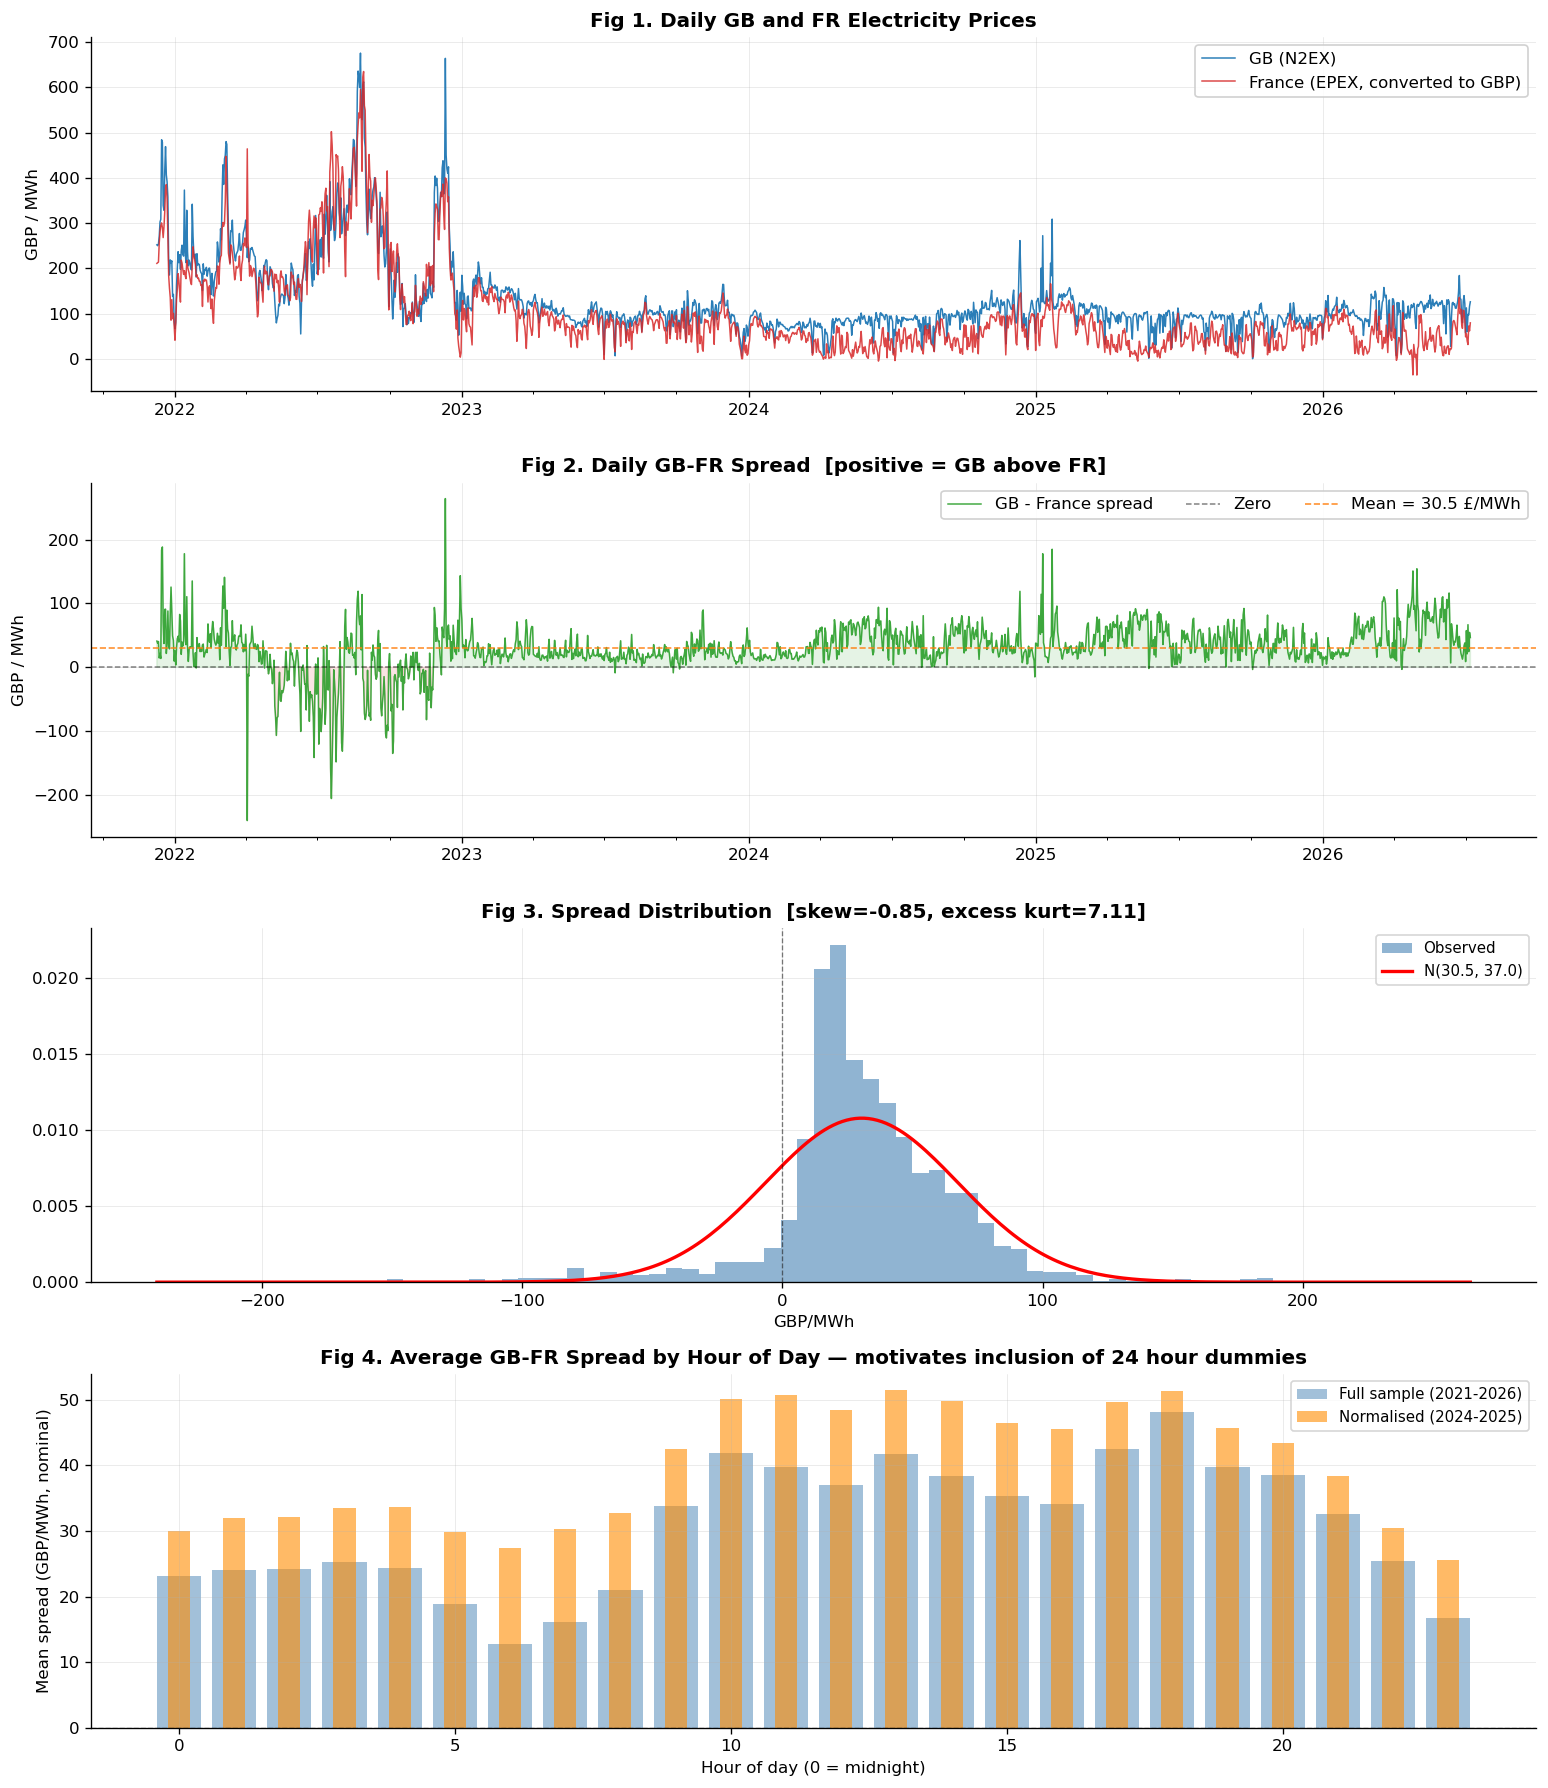

Saved: fig_eda.png


Saved: fig_eda_prices.png, fig_eda_spread.png, fig_eda_dist.png


In [5]:
import matplotlib.dates as mdates

# M1 formatting style: light grid, no top/right spines
with plt.rc_context({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.linewidth': 0.3, 'grid.alpha': 0.5,
}):
    pass  # applied per-axes below via helper
_spine = lambda ax: (ax.spines['top'].set_visible(False),
                     ax.spines['right'].set_visible(False),
                     ax.grid(True, linewidth=0.3, alpha=0.5, color='grey'))

# Build nominal panel for EDA figures by reversing the RPI deflation applied in cell 6.
_FIGURES_DIR = Path('/Users/aadesh/Downloads/figures')
_panel_nom = panel.copy()
_rpi_inflate = 1.0 / _rpi_defl
_panel_nom['gb_price_gbp'] = _panel_nom['gb_price_gbp'] * _rpi_inflate
_panel_nom['fr_price_gbp'] = _panel_nom['fr_price_gbp'] * _rpi_inflate
_panel_nom['spread_gbp']   = _panel_nom['spread_gbp']   * _rpi_inflate
_daily_nom = _panel_nom[['gb_price_gbp', 'fr_price_gbp', 'spread_gbp']].resample('D').mean().dropna()

# ── 4-panel composite (kept for internal reference, not in dissertation) ──────
fig, axes = plt.subplots(4, 1, figsize=(13, 15))

ax = axes[0]
ax.plot(_daily_nom.index, _daily_nom['gb_price_gbp'], lw=0.9, color='#1f77b4',
        label='GB (N2EX)', alpha=0.95)
ax.plot(_daily_nom.index, _daily_nom['fr_price_gbp'], lw=0.9, color='#d62728',
        label='France (EPEX, converted to GBP)', alpha=0.85)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
ax.set_ylabel('GBP / MWh')
ax.set_title('Fig 1. Daily GB and FR Electricity Prices', fontweight='bold')
ax.legend(framealpha=0.9)

ax = axes[1]
_spread_mean = _daily_nom['spread_gbp'].mean()
ax.plot(_daily_nom.index, _daily_nom['spread_gbp'], lw=0.9, color='#2ca02c', alpha=0.9,
        label='GB - France spread')
ax.axhline(0, color='black', lw=0.9, ls='--', alpha=0.5, label='Zero')
ax.axhline(_spread_mean, color='#ff7f0e', lw=1.0, ls='--', alpha=0.85,
           label=f'Mean = {_spread_mean:.1f} £/MWh')
ax.fill_between(_daily_nom.index, _daily_nom['spread_gbp'], 0,
                where=(_daily_nom['spread_gbp'] >= 0), alpha=0.12, color='#2ca02c')
ax.fill_between(_daily_nom.index, _daily_nom['spread_gbp'], 0,
                where=(_daily_nom['spread_gbp'] < 0), alpha=0.12, color='#d62728')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
ax.set_ylabel('GBP / MWh')
ax.set_title('Fig 2. Daily GB-FR Spread  [positive = GB above FR]', fontweight='bold')
ax.legend(framealpha=0.9, ncol=3)

ax = axes[2]
sv = _daily_nom['spread_gbp'].dropna()
ax.hist(sv, bins=80, density=True, color='steelblue', alpha=0.6, label='Observed')
mu_s, sd_s = sv.mean(), sv.std()
xr = np.linspace(sv.min(), sv.max(), 300)
ax.plot(xr, sp_stats.norm.pdf(xr, mu_s, sd_s), 'r-', lw=2,
        label=f'N({mu_s:.1f}, {sd_s:.1f})')
ax.axvline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('GBP/MWh')
ax.set_title(
    f'Fig 3. Spread Distribution  '
    f'[skew={sp_stats.skew(sv):.2f}, excess kurt={sp_stats.kurtosis(sv):.2f}]',
    fontweight='bold')
ax.legend(fontsize=9)

ax = axes[3]
hourly_profile = _panel_nom.groupby(_panel_nom.index.hour)['spread_gbp'].mean()
hourly_profile_norm = _panel_nom.loc['2024':'2025'].groupby(
    _panel_nom.loc['2024':'2025'].index.hour)['spread_gbp'].mean()
ax.bar(hourly_profile.index, hourly_profile.values, alpha=0.5,
       color='steelblue', label='Full sample (2021-2026)')
ax.bar(hourly_profile_norm.index, hourly_profile_norm.values, alpha=0.6,
       color='darkorange', width=0.4, label='Normalised (2024-2025)')
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Hour of day (0 = midnight)')
ax.set_ylabel('Mean spread (GBP/MWh, nominal)')
ax.set_title('Fig 4. Average GB-FR Spread by Hour of Day'
             ' — motivates inclusion of 24 hour dummies', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_eda.png', dpi=150, bbox_inches='tight')
plt.savefig(_FIGURES_DIR / 'fig_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_eda.png')

# ── fig_eda_prices.png — M1 formatting style ─────────────────────────────────
_fig_p, _ax_p = plt.subplots(figsize=(13, 4))

# Crisis shading: Russian invasion Feb 2022 → prices normalise by end 2022
_ax_p.axvspan(pd.Timestamp('2022-02-24'), pd.Timestamp('2022-12-31'),
              alpha=0.08, color='#d62728', zorder=0)
_ax_p.text(pd.Timestamp('2022-04-01'), 620,
           '2022 Energy\nCrisis', fontsize=8, color='#a00000',
           va='top', ha='left', style='italic')

_ax_p.plot(_daily_nom.index, _daily_nom['gb_price_gbp'],
           label='GB (N2EX)', color='#1f77b4', lw=0.9, alpha=0.95)
_ax_p.plot(_daily_nom.index, _daily_nom['fr_price_gbp'],
           label='France (EPEX, converted to GBP)', color='#d62728', lw=0.9, alpha=0.85)
_ax_p.xaxis.set_major_locator(mdates.YearLocator())
_ax_p.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
_ax_p.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
_peak_idx = _daily_nom['gb_price_gbp'].idxmax()
_ax_p.annotate(
    f"GB peak\n{_peak_idx.strftime('%b %Y')}\n{_daily_nom.loc[_peak_idx, 'gb_price_gbp']:.0f} £/MWh",
    xy=(_peak_idx, _daily_nom.loc[_peak_idx, 'gb_price_gbp']),
    xytext=(-90, -30), textcoords='offset points',
    fontsize=8, color='#1f77b4', ha='right',
    arrowprops=dict(arrowstyle='-|>', color='#1f77b4', lw=0.8),
)
_ax_p.set_xlabel('Year')
_ax_p.set_ylabel('GBP / MWh')
_ax_p.legend(framealpha=0.9, loc='upper right')
_spine(_ax_p)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_eda_prices.png', dpi=150, bbox_inches='tight')
plt.savefig(_FIGURES_DIR / 'fig_eda_prices.png', dpi=150, bbox_inches='tight')
plt.close()

# ── fig_eda_spread.png — M1 formatting style ─────────────────────────────────
_fig_s, _ax_s = plt.subplots(figsize=(13, 4))
_ax_s.plot(_daily_nom.index, _daily_nom['spread_gbp'],
           color='#2ca02c', lw=0.9, alpha=0.9, label='GB - France spread')
_ax_s.axhline(0, color='black', lw=0.9, ls='--', alpha=0.5, label='Zero')
_ax_s.axhline(_spread_mean, color='#ff7f0e', lw=1.0, ls='--', alpha=0.85,
              label=f'Mean = {_spread_mean:.1f} £/MWh')
_ax_s.fill_between(_daily_nom.index, _daily_nom['spread_gbp'], 0,
                   where=(_daily_nom['spread_gbp'] >= 0),
                   alpha=0.12, color='#2ca02c')
_ax_s.fill_between(_daily_nom.index, _daily_nom['spread_gbp'], 0,
                   where=(_daily_nom['spread_gbp'] < 0),
                   alpha=0.12, color='#d62728')
_ax_s.xaxis.set_major_locator(mdates.YearLocator())
_ax_s.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
_ax_s.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
_ax_s.set_xlabel('Year')
_ax_s.set_ylabel('GBP / MWh')
_ax_s.legend(framealpha=0.9, ncol=1, loc='upper right', fontsize=9)
_spine(_ax_s)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_eda_spread.png', dpi=150, bbox_inches='tight')
plt.savefig(_FIGURES_DIR / 'fig_eda_spread.png', dpi=150, bbox_inches='tight')
plt.close()

# ── fig_eda_dist.png ──────────────────────────────────────────────────────────
_sv = _daily_nom['spread_gbp'].dropna()
_fig_d, _ax_d = plt.subplots(figsize=(8, 4))
_ax_d.hist(_sv, bins=80, density=True, color='steelblue', alpha=0.6, label='Observed')
_mu, _sd = _sv.mean(), _sv.std()
_xr = np.linspace(_sv.min(), _sv.max(), 300)
_ax_d.plot(_xr, sp_stats.norm.pdf(_xr, _mu, _sd), 'r-', lw=2,
            label=f'N({_mu:.1f}, {_sd:.1f}²)')
_ax_d.axvline(0, color='k', lw=0.8, ls='--', alpha=0.5)
_ax_d.set_xlabel('Daily mean spread (GBP/MWh, nominal)')
_ax_d.set_ylabel('Density')
_ax_d.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_eda_dist.png', dpi=150, bbox_inches='tight')
plt.savefig(_FIGURES_DIR / 'fig_eda_dist.png', dpi=150, bbox_inches='tight')
plt.close()

print('Saved: fig_eda_prices.png, fig_eda_spread.png, fig_eda_dist.png')


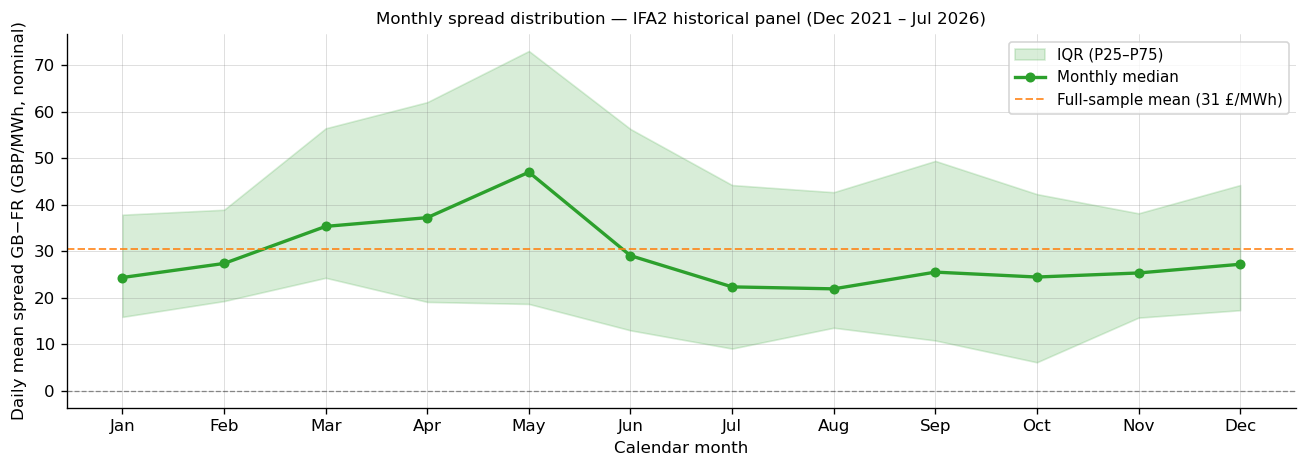

Saved: fig_seasonal_spread.png
  Spring (Mar-May) medians: Mar £35.3, Apr £37.2, May £47.0
  Summer (Jun-Aug) medians: Jun £29.0, Jul £22.3, Aug £21.9


In [6]:
# ── Fig: Monthly seasonal spread pattern (median line + P25-P75 band) ─────────
import calendar
_daily_spread = _daily_nom['spread_gbp']
_months = _daily_spread.index.month

_med  = [_daily_spread[_months == m].median()          for m in range(1, 13)]
_p25  = [_daily_spread[_months == m].quantile(0.25)    for m in range(1, 13)]
_p75  = [_daily_spread[_months == m].quantile(0.75)    for m in range(1, 13)]
_month_labels = [calendar.month_abbr[m] for m in range(1, 13)]
_x = list(range(12))

fig_seas, ax_seas = plt.subplots(figsize=(11, 4))

ax_seas.fill_between(_x, _p25, _p75, alpha=0.18, color='#2ca02c', label='IQR (P25–P75)')
ax_seas.plot(_x, _med, color='#2ca02c', lw=2.0, marker='o', ms=5, label='Monthly median')
ax_seas.axhline(_daily_spread.mean(), color='#ff7f0e', lw=1.2, ls='--', alpha=0.8,
                label=f'Full-sample mean ({_daily_spread.mean():.0f} £/MWh)')
ax_seas.axhline(0, color='black', lw=0.8, ls='--', alpha=0.4)

ax_seas.set_xticks(_x)
ax_seas.set_xticklabels(_month_labels)
ax_seas.set_xlabel('Calendar month')
ax_seas.set_ylabel('Daily mean spread GB−FR (GBP/MWh, nominal)')
ax_seas.set_title('Monthly spread distribution — IFA2 historical panel (Dec 2021 – Jul 2026)',
                   fontsize=10)
ax_seas.legend(fontsize=9, loc='upper right')
ax_seas.spines['top'].set_visible(False)
ax_seas.spines['right'].set_visible(False)
ax_seas.grid(True, linewidth=0.3, alpha=0.5, color='grey')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_seasonal_spread.png', dpi=150, bbox_inches='tight')
plt.savefig(_FIGURES_DIR / 'fig_seasonal_spread.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: fig_seasonal_spread.png')
print(f'  Spring (Mar-May) medians: ' +
      ', '.join(f'{calendar.month_abbr[m]} £{_med[m-1]:.1f}' for m in [3,4,5]))
print(f'  Summer (Jun-Aug) medians: ' +
      ', '.join(f'{calendar.month_abbr[m]} £{_med[m-1]:.1f}' for m in [6,7,8]))


### 5.1 Historical Revenue vs Gross Congestion Rent (ENTSO-E Flows, 2021–2026)

Gross congestion rent is computed from **ENTSO-E reported physical flows** on IFA2
multiplied by the observed GB–FR price spread in the flow direction:

$$\text{GCR}_h = (F^{\text{FR}\to\text{GB}}_h \cdot \max(S_h,0) + F^{\text{GB}\to\text{FR}}_h \cdot \max(-S_h,0)) / 10^6 \quad [\text{£m}]$$

The **implied capture ratio** (CR) bridges gross congestion rent to Ofgem-assessed actual
turnover from audited accounts. CR reflects the explicit auction mechanism post-Brexit:
IFA2 sells capacity in forward auctions whose clearing price diverges from the realised
spot spread; the residual accrues to capacity buyers, not IFA2.

**Key observations:**
- 2022 outlier: net flow was *into* GB (FR nuclear crisis kept FR prices high), suppressing
  the GB > FR spread to £5.69/MWh — gross rent was large (£231.6m) but mostly in the
  "wrong" direction; CR = 30.1%.
- 2023 spike: spread recovered (£23.50/MWh), flow realigned FR→GB; CR reached 88.9%,
  suggesting auction premiums above spot in some periods or ENTSO-E under-reporting net capacity.
- 2024–2025 compression: spreads widened further (£37–42/MWh) and FR→GB flows grew, yet
  actual revenues barely moved — CR fell to 55% then 25%, pointing to widening auction/spot divergence.
- **2022–2025 blended CR = 42.2%** — used to calibrate the back-test capture ratio in Section 12.


In [7]:
# ── §5.1 Revenue constants — table built at bottom of cell 14 after _df ────
_NART_NOM = {2022: 69.6, 2023: 100.8, 2024: 101.6, 2025: 72.2}  # Ofgem audited NARt, nominal £m


In [8]:
# ── Against-price flows: when did IFA2 flow from the higher-priced region? ────
#
# "Against price" = physical flow runs AGAINST the price gradient in that hour:
#   FR→GB when spread_gbp < 0  (FR more expensive than GB — importing the costly side)
#   GB→FR when spread_gbp > 0  (GB more expensive than FR — exporting the costly side)
#
# Day-ahead auctions commit capacity the day before using forecast prices;
# realised spot spread can flip intraday.  These hours earn no congestion rent
# and can represent a cost to the capacity buyer.

from pathlib import Path
import pandas as pd
import numpy as np

_FLOW_PATH = Path('/Users/aadesh/Documents/IC/ENTSO-E/GUI_NET_CROSS_BORDER_IFA2_combined.csv')

# ── 1. Load ENTSO-E flows ─────────────────────────────────────────────────────
_raw = pd.read_csv(_FLOW_PATH)
_raw['ts'] = pd.to_datetime(
    _raw['MTU'].str.split(' - ').str[0].str.strip(),
    format='%d/%m/%Y %H:%M:%S', utc=False
)
_raw['flow_mw'] = pd.to_numeric(_raw['Physical Flow (MW)'], errors='coerce')
_raw['_dir'] = _raw['Out Area'].str.contains('GB').map({True: 'gb_to_fr', False: 'fr_to_gb'})
_flows = (_raw.pivot_table(index='ts', values='flow_mw', columns='_dir', aggfunc='sum')
          .rename_axis(None, axis=1)
          .reindex(columns=['fr_to_gb', 'gb_to_fr'])
          .fillna(0.0))
_flows.index = _flows.index.tz_localize(None)

# ── 2. Join with spread (panel already in memory from Section 3) ──────────────
_df = _flows.join(panel[['spread_gbp']], how='inner').dropna()
_df['net_mw'] = _df['fr_to_gb'] - _df['gb_to_fr']  # positive = net FR→GB

# ── 3. Classify each hour ─────────────────────────────────────────────────────
# Flows at zero spread are ambiguous — exclude them from the "against" count
_df['has_flow'] = (_df['fr_to_gb'] > 0) | (_df['gb_to_fr'] > 0)
_df['against']  = (
    ((_df['fr_to_gb'] > 0) & (_df['spread_gbp'] < 0)) |   # FR→GB, FR costlier
    ((_df['gb_to_fr'] > 0) & (_df['spread_gbp'] > 0))     # GB→FR, GB costlier
)
_df['with_price'] = _df['has_flow'] & ~_df['against'] & (_df['spread_gbp'] != 0)


# ── 2b. Load hourly NTC (ENTSO-E capacity allocation; FR→GB direction) ────────
def _load_ntc_cet(path, col):
    df = pd.read_csv(path)
    df.columns = ['datetime', col]
    df['datetime'] = (pd.to_datetime(df['datetime'], utc=True)
                      .dt.tz_convert('Europe/Paris').dt.tz_localize(None))
    return df.set_index('datetime')

_ntc = _load_ntc_cet(
    '/Users/aadesh/Documents/IC/M2/IFA2_NTC_FR_out_GBIFA2_in_2021-01-01_to_2026-07-31.csv',
    'ntc_mw')
_df = _df.join(_ntc, how='left')
_df['ntc_mw'] = _df['ntc_mw'].fillna(0.0)

# Nominal spread: reverse RPI deflation for monetary comparisons
_df['spread_nom'] = _df['spread_gbp'] * pd.Series(
    [_HIST_RPI.get(d.year, _HIST_RPI_MAX) / _RPI_1617 for d in _df.index], index=_df.index)

# ── 4. Summary ────────────────────────────────────────────────────────────────
_total   = len(_df)
_flowing = _df['has_flow'].sum()
_against = _df['against'].sum()
_with    = _df['with_price'].sum()

print(f'Sample: {_df.index.min().date()} to {_df.index.max().date()}  ({_total:,} hrs joined)')
print(f'  Hours with non-zero flow : {_flowing:,}  ({_flowing/_total:.1%} of sample)')
print(f'  Flow WITH price gradient : {_with:,}  ({_with/_flowing:.1%} of flowing hrs)')
print(f'  Flow AGAINST price       : {_against:,}  ({_against/_flowing:.1%} of flowing hrs)')
print()

# ── 5. Annual breakdown ───────────────────────────────────────────────────────
_ann = _df.groupby(_df.index.year).agg(
    total_hrs  =('has_flow', 'count'),
    flowing_hrs=('has_flow', 'sum'),
    against_hrs=('against', 'sum'),
    with_hrs   =('with_price', 'sum'),
    mean_spread=('spread_gbp', 'mean'),
)
_ann['against_vol'] = (
    _df[_df['against']].groupby(_df[_df['against']].index.year)['net_mw']
    .apply(lambda x: x.abs().mean())
)
_ann['against_pct'] = _ann['against_hrs'] / _ann['flowing_hrs']

W2 = 82
print('=' * W2)
print('AGAINST-PRICE FLOW — ANNUAL BREAKDOWN')
print('=' * W2)
print(f'  {"Year":>5}  {"Flow hrs":>9}  {"Against":>9}  {"Against%":>9}  '
      f'{"Mean |MW|":>10}  {"Mean spread":>12}')
print('  ' + '-' * (W2 - 2))
for yr, r in _ann.iterrows():
    print(f'  {int(yr):>5}  {int(r.flowing_hrs):>9,}  {int(r.against_hrs):>9,}  '
          f'{r.against_pct:>9.1%}  {r.against_vol:>10.0f}  {r.mean_spread:>10.2f} £/MWh')
print('=' * W2)
print()

# ── 6. Monthly heatmap (count of against-price hours) ────────────────────────
_ag = _df[_df['against']].copy()
_ag['year']  = _ag.index.year
_ag['month'] = _ag.index.month

_heat = (_ag.groupby(['year', 'month']).size()
           .unstack(fill_value=0)
           .rename(columns={m: f'{m:02d}' for m in range(1, 13)}))
_heat.columns = [pd.Timestamp(f'2000-{c}-01').strftime('%b') for c in _heat.columns]

print('AGAINST-PRICE HOURS PER MONTH (count)')
print(_heat.to_string())
print()
print(f'Peak month: {_ag.groupby([_ag.index.year, _ag.index.month]).size().idxmax()} '
      f'({_ag.groupby([_ag.index.year, _ag.index.month]).size().max()} hrs)')

# ── 7. Longest continuous against-price runs ──────────────────────────────────
_ag_mask = _df['against'].astype(int)
_df['run_id'] = (_ag_mask != _ag_mask.shift()).cumsum()
_runs = (_df[_df['against']]
         .groupby('run_id')
         .agg(start=('against', lambda x: x.index[0]),
              end  =('against', lambda x: x.index[-1]),
              hrs  =('against', 'count'),
              mean_spread=('spread_gbp', 'mean'))
         .sort_values('hrs', ascending=False)
         .head(10)
         .reset_index(drop=True))

print()
print('TOP 10 LONGEST CONTINUOUS AGAINST-PRICE RUNS')
print(f'  {"#":>3}  {"Start":>20}  {"End":>20}  {"Hrs":>5}  {"Mean spread £/MWh":>18}')
print('  ' + '-' * 72)
for i, r in _runs.iterrows():
    print(f'  {i+1:>3}  {str(r.start):>20}  {str(r.end):>20}  {r.hrs:>5}  {r.mean_spread:>18.2f}')


# ── §5.1 Revenue table: gross congestion rent vs Ofgem NARt ──────────────────
_rev_rows = []
for _yr, _g in _df.groupby(_df.index.year):
    _gross_nom  = (_g['net_mw'].abs() * _g['spread_nom'].abs()).sum() / 1e6
    _gross_real = (_g['net_mw'].abs() * _g['spread_gbp'].abs()).sum() / 1e6
    _nart = _NART_NOM.get(int(_yr), np.nan)
    _rev_rows.append(dict(
        year=int(_yr), hours=len(_g),
        fr_to_gb_gwh  =_g['fr_to_gb'].sum() / 1e3,
        gb_to_fr_gwh  =_g['gb_to_fr'].sum() / 1e3,
        net_fr_to_gb_gwh=_g['net_mw'].sum() / 1e3,
        mean_spread_nom =_g['spread_nom'].mean(),
        rev_nom_m =_gross_nom, rev_real_m=_gross_real,
        actual_nom_m=_nart,
        cr_from_nom =_nart / _gross_nom if not np.isnan(_nart) else np.nan,
    ))
_rev = pd.DataFrame(_rev_rows)

W = 125
print('=' * W)
print('IFA2: GROSS CONGESTION RENT vs OFGEM ACTUAL TURNOVER — 2021 to 2026')
print('(ENTSO-E physical flows × nominal GB/FR spot prices | Actuals from audited accounts)')
print('=' * W)
print(f'  {"Year":>5}  {"Hrs":>5}  {"FR→GB":>7}  {"GB→FR":>7}  {"Net":>7}  '
      f'{"Spread":>8}  {"Gross nom":>10}  {"Gross real":>11}  {"Actual nom":>11}  {"CR":>9}')
print(f'  {"":>5}  {"":>5}  {"GWh":>7}  {"GWh":>7}  {"GWh":>7}  '
      f'{"£/MWh":>8}  {"£m":>10}  {"£m 16/17":>11}  {"£m":>11}  {"act/gross":>9}')
print('  ' + '-' * (W - 2))
for _, r in _rev.iterrows():
    yr   = int(r.year)
    note = ' *' if yr == 2021 else (' †' if yr == 2026 else '  ')
    act_s = f'{r.actual_nom_m:>11.1f}' if pd.notna(r.actual_nom_m) else f'{"n/a":>11}'
    cr_s  = f'{r.cr_from_nom:>8.1%}'   if pd.notna(r.cr_from_nom)  else f'{"n/a":>8}'
    print(f'  {yr:>5}{note} {int(r.hours):>5}  {r.fr_to_gb_gwh:>7.0f}  '
          f'{r.gb_to_fr_gwh:>7.0f}  {r.net_fr_to_gb_gwh:>7.0f}  '
          f'{r.mean_spread_nom:>8.2f}  {r.rev_nom_m:>10.1f}  {r.rev_real_m:>11.1f}  '
          f'{act_s}  {cr_s}')
fy = _rev[_rev.year.isin(range(2022, 2026))]
print()
print(f'  {"2022–25 total":>16}  {"":>7}  {"":>7}  {"":>7}  {"":>8}  '
      f'{fy.rev_nom_m.sum():>10.1f}  {fy.rev_real_m.sum():>11.1f}  '
      f'{fy.actual_nom_m.sum():>11.1f}  {fy.actual_nom_m.sum()/fy.rev_nom_m.sum():>8.1%}')
print()
print('  * 2021: partial year.  † 2026: partial year (to Jul 2026).')
print('  Gross nom = ENTSO-E |net_flow_MW| × |nominal spread| summed hourly.')
print('  Actual = Ofgem NARt from audited accounts (nominal £m).')
print('=' * W)

# ── Chart: Gross nom vs NARt (bars) and CR% (line) by year ──────────────────
_plot_rev = _rev[_rev['year'].isin(range(2022, 2026))].copy()
_x = np.arange(len(_plot_rev))
_w = 0.35

fig_rev, ax_rev1 = plt.subplots(figsize=(9, 5))
ax_rev2 = ax_rev1.twinx()

b1 = ax_rev1.bar(_x - _w/2, _plot_rev['rev_nom_m'],  _w, label='Gross congestion rent (nominal £m)',
                  color='#5b9bd5', alpha=0.85, zorder=3)
b2 = ax_rev1.bar(_x + _w/2, _plot_rev['actual_nom_m'], _w, label='Ofgem NARt (nominal £m)',
                  color='#ed7d31', alpha=0.85, zorder=3)
ln = ax_rev2.plot(_x, _plot_rev['cr_from_nom'] * 100, 'o-', color='#70ad47',
                   lw=2.2, ms=8, label='Capture ratio (CR%)', zorder=4)

for bar, val in zip(b1, _plot_rev['rev_nom_m']):
    ax_rev1.text(bar.get_x() + bar.get_width()/2, val + 3,
                 f'£{val:.0f}m', ha='center', va='bottom', fontsize=8, color='#2e6097')
for bar, val in zip(b2, _plot_rev['actual_nom_m']):
    ax_rev1.text(bar.get_x() + bar.get_width()/2, val + 3,
                 f'£{val:.0f}m', ha='center', va='bottom', fontsize=8, color='#8b4000')
for xi, cr in zip(_x, _plot_rev['cr_from_nom']):
    ax_rev2.text(xi, cr * 100 + 2, f'{cr:.0%}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold', color='#3a6e00')

ax_rev1.set_xticks(_x)
ax_rev1.set_xticklabels(_plot_rev['year'].astype(str))
ax_rev1.set_ylabel('£m (nominal)')
ax_rev2.set_ylabel('Capture ratio (%)')
ax_rev1.set_title(
    'Figure X. IFA2 Gross Congestion Rent vs Ofgem NARt (2022–2025)\n'
    'ENTSO-E physical flows × nominal spot spread | Ofgem audited accounts',
    fontsize=10)
h1, l1 = ax_rev1.get_legend_handles_labels()
h2, l2 = ax_rev2.get_legend_handles_labels()
ax_rev1.legend(h1 + h2, l1 + l2, fontsize=9, loc='upper right')
ax_rev1.grid(axis='y', alpha=0.3, zorder=0)
ax_rev1.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
_rev_chart_path = OUTPUT_DIR / 'fig_gross_vs_nart.png'
plt.savefig(_rev_chart_path, dpi=150, bbox_inches='tight')
plt.close()
print(f'Saved: {_rev_chart_path}')

# Expose for Section 18 waterfall
flow_df = _flows


Sample: 2021-12-09 to 2026-07-07  (40,012 hrs joined)
  Hours with non-zero flow : 37,489  (93.7% of sample)
  Flow WITH price gradient : 30,244  (80.7% of flowing hrs)
  Flow AGAINST price       : 7,242  (19.3% of flowing hrs)

AGAINST-PRICE FLOW — ANNUAL BREAKDOWN
   Year   Flow hrs    Against   Against%   Mean |MW|   Mean spread
  --------------------------------------------------------------------------------
   2021        510        253      49.6%         601       53.26 £/MWh
   2022      8,337      3,662      43.9%         676        4.66 £/MWh
   2023      8,465      1,755      20.7%         401       18.81 £/MWh
   2024      8,517        584       6.9%         381       28.77 £/MWh
   2025      8,365        778       9.3%         534       31.61 £/MWh
   2026      3,295        210       6.4%         462       38.97 £/MWh

AGAINST-PRICE HOURS PER MONTH (count)
      Jan  Feb  Mar  Apr  May  Jun  Jul  Aug  Sep  Oct  Nov  Dec
year                                                 

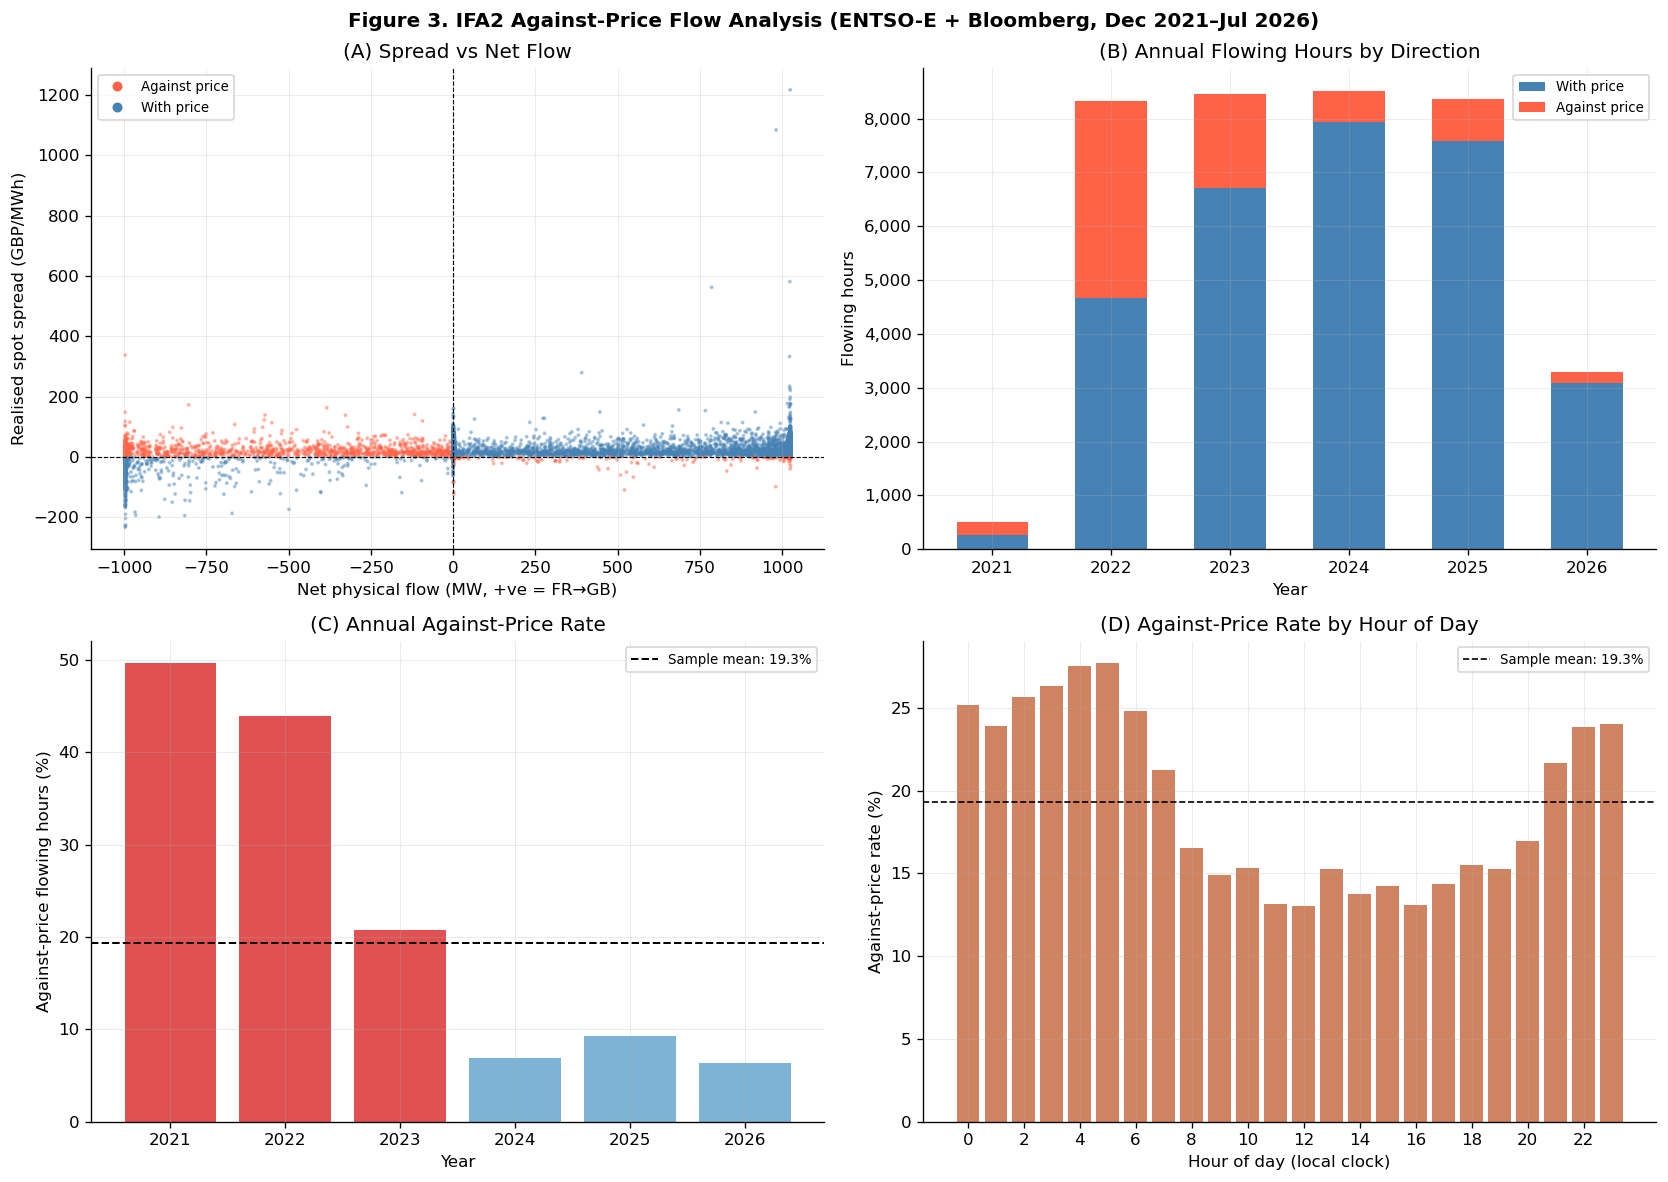

Saved: flow_direction_mismatch.png
Overall against-price rate (flowing hours): 19.3%


In [9]:
# ── Fig 3: Against-price flow visualisation (4-panel) ─────────────────────────
# Uses _df and _ann computed in the cell above (against-price analysis).

import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np

_fig3, _axes3 = plt.subplots(2, 2, figsize=(14, 10))
_fig3.suptitle(
    'Figure 3. IFA2 Against-Price Flow Analysis (ENTSO-E + Bloomberg, Dec 2021–Jul 2026)',
    fontweight='bold', fontsize=12)

# ── Panel A: spread vs net flow scatter, coloured by direction ────────────────
_ax = _axes3[0, 0]
_samp = _df.sample(min(8_000, len(_df)), random_state=42)
_colors = _samp['against'].map({True: 'tomato', False: 'steelblue'})
_ax.scatter(_samp['net_mw'], _samp['spread_gbp'],
            c=_colors, s=2, alpha=0.35, rasterized=True)
_ax.axhline(0, color='k', lw=0.7, ls='--')
_ax.axvline(0, color='k', lw=0.7, ls='--')
_ax.set_xlabel('Net physical flow (MW, +ve = FR→GB)')
_ax.set_ylabel('Realised spot spread (GBP/MWh)')
_ax.set_title('(A) Spread vs Net Flow')
_leg_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',   markersize=7, label='Against price'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=7, label='With price'),
]
_ax.legend(handles=_leg_handles, fontsize=8)

# ── Panel B: annual stacked bar — flowing hours by direction ──────────────────
_ax = _axes3[0, 1]
_yrs_ann = _ann.index.astype(int).tolist()
_ax.bar(_yrs_ann, _ann['with_hrs'],    0.6, color='steelblue', label='With price')
_ax.bar(_yrs_ann, _ann['against_hrs'], 0.6,
        bottom=_ann['with_hrs'], color='tomato', label='Against price')
_ax.set_xlabel('Year'); _ax.set_ylabel('Flowing hours')
_ax.set_title('(B) Annual Flowing Hours by Direction')
_ax.legend(fontsize=8)
_ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
_ax.set_xticks(_yrs_ann)

# ── Panel C: annual against-price rate with overall mean ─────────────────────
_ax = _axes3[1, 0]
_against_pct_vals = (_ann['against_pct'] * 100).values
_overall_ap = _df['against'].sum() / _df['has_flow'].sum() * 100
_bar_colors = ['#e05252' if v > _overall_ap else '#7db3d4' for v in _against_pct_vals]
_ax.bar(_yrs_ann, _against_pct_vals, color=_bar_colors)
_ax.axhline(_overall_ap, color='k', lw=1.2, ls='--',
            label=f'Sample mean: {_overall_ap:.1f}%')
_ax.set_xlabel('Year'); _ax.set_ylabel('Against-price flowing hours (%)')
_ax.set_title('(C) Annual Against-Price Rate')
_ax.legend(fontsize=8); _ax.set_xticks(_yrs_ann)

# ── Panel D: diurnal profile of against-price rate ────────────────────────────
_ax = _axes3[1, 1]
_df['_hour'] = _df.index.hour
_hourly_rate = _df[_df['has_flow']].groupby('_hour')['against'].mean() * 100
_ax.bar(_hourly_rate.index, _hourly_rate.values, color='#c0592b', alpha=0.75)
_ax.axhline(_overall_ap, color='k', lw=1.0, ls='--',
            label=f'Sample mean: {_overall_ap:.1f}%')
_ax.set_xlabel('Hour of day (local clock)'); _ax.set_ylabel('Against-price rate (%)')
_ax.set_title('(D) Against-Price Rate by Hour of Day')
_ax.set_xticks(range(0, 24, 2)); _ax.legend(fontsize=8)
del _df['_hour']

plt.tight_layout()
_fig3.savefig(OUTPUT_DIR / 'flow_direction_mismatch.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: flow_direction_mismatch.png')
print(f'Overall against-price rate (flowing hours): {_overall_ap:.1f}%')


### 5.2 Price-Weighted Inefficiency (WFAPD) vs Implied Capture Ratio

UFAPD counts against-price hours equally regardless of the spread at which they occur.
Montoya et al. (2020) Eq. 2 corrects this by weighting each FAPD hour by its price differential:

$$\text{WFAPD} = \frac{\sum_{h \in \text{FAPD}} |f_h \cdot x_h|}{\sum_{h \in \text{FWPD}} |f_h \cdot x_h| + \sum_{h \in \text{FAPD}} |f_h \cdot x_h|}$$

A high UFAPD with a low WFAPD means against-price flows were concentrated in low-spread hours — little revenue was at stake in those hours. This explains why the implied capture ratio was elevated in 2022–2023 despite a higher raw FAPD rate: the crisis-era extreme spreads were captured in the *correct* direction; FAPDs occurred mostly in low-differential hours.

UFAPD vs WFAPD vs IMPLIED CAPTURE RATIO  —  IFA2 2021–2025
WFAPD: Montoya et al. (2020) Eq. 2  |  CR = Ofgem NARt / Gross Congestion Rent
  Year    UFAPD    WFAPD   Impl CR    Mean spread    Mean spread   Gross £m   NARt £m
        (count)    (wtd)                 FAPD hrs       FWPD hrs                     
  -------------------------------------------------------------------------------------------------------
  2021   49.6%   28.9%      n/a         47.55         89.69       23.4       n/a
  2022   43.9%   26.0%    22.2%         36.34         60.26      314.2      69.6
  2023   20.7%    9.3%    80.6%         16.58         26.52      125.1     100.8
  2024    6.9%    1.5%    54.3%         15.58         39.04      187.1     101.6
  2025    9.3%    1.8%    24.7%         15.01         44.61      292.7      72.2
  2026    6.4%    0.7%      n/a         16.16         54.53      161.0       n/a

Interpretation: WFAPD < UFAPD means FAPDs occurred in lower-spread hours than
efficient flows. In

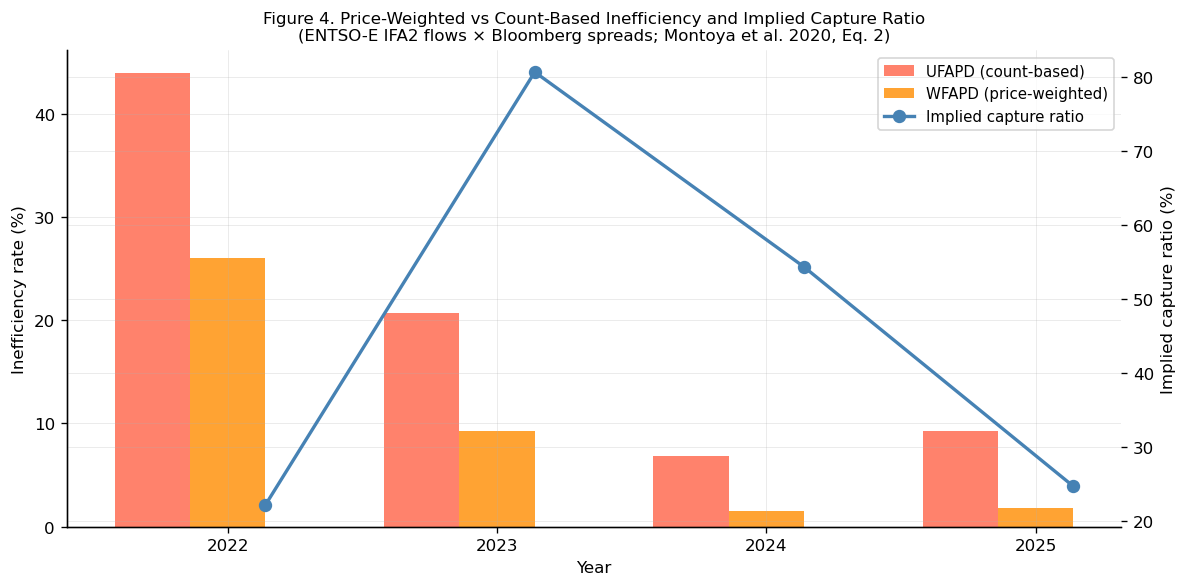

Saved: wfapd_vs_cr.png


In [10]:
# ── WFAPD (Montoya et al. 2020, Eq. 2) vs Implied Capture Ratio ─────────────
# _df and _ann are built in cell 14 (against-price analysis).
# _rev is built in cell 13 (flow revenue table).

import numpy as np
import matplotlib.pyplot as plt

_NART_NOM = {2022: 69.6, 2023: 100.8, 2024: 101.6, 2025: 72.2}  # Ofgem audited NARt (nominal £m)

# Revenue at stake per hour: |net_flow_MW| × |spread_£/MWh|
# Value at stake: nominal spread so gross is comparable to nominal NARt
_df['_val'] = _df['net_mw'].abs() * _df['spread_nom'].abs()

rows = []
for yr in sorted(_ann.index):
    d = _df[_df.index.year == yr]

    # UFAPD — simple against-price rate (already in _ann)
    ufapd = _ann.loc[yr, 'against_pct']

    # WFAPD — price-weighted (Montoya et al. Eq. 2)
    val_against = d.loc[d['against'],    '_val'].sum()
    val_with    = d.loc[d['with_price'], '_val'].sum()
    denom = val_against + val_with
    wfapd = val_against / denom if denom > 0 else np.nan

    # Mean |spread| in FAPD vs FWPD hours — shows where FAPDs are concentrated
    sp_against = d.loc[d['against'],    'spread_nom'].abs().mean()
    sp_with    = d.loc[d['with_price'], 'spread_nom'].abs().mean()

    # Gross from _rev (built from same _df; same hours throughout)
    rev_row  = _rev[_rev['year'] == yr]
    gross_nm = rev_row['rev_nom_m'].values[0] if len(rev_row) else np.nan
    nart_nm  = _NART_NOM.get(yr, np.nan)
    impl_cr  = nart_nm / gross_nm if (not np.isnan(gross_nm) and gross_nm > 0) else np.nan

    rows.append(dict(year=int(yr), ufapd=ufapd, wfapd=wfapd, impl_cr=impl_cr,
                     sp_against=sp_against, sp_with=sp_with,
                     gross_nm=gross_nm, nart_nm=nart_nm))

_wdf = pd.DataFrame(rows).set_index('year')

# ── Table ─────────────────────────────────────────────────────────────────────
W = 105
print('=' * W)
print('UFAPD vs WFAPD vs IMPLIED CAPTURE RATIO  —  IFA2 2021–2025')
print('WFAPD: Montoya et al. (2020) Eq. 2  |  CR = Ofgem NARt / Gross Congestion Rent')
print('=' * W)
print(f'  {"Year":>4}  {"UFAPD":>7}  {"WFAPD":>7}  {"Impl CR":>8}  '
      f'{"Mean spread":>13}  {"Mean spread":>13}  {"Gross £m":>9}  {"NARt £m":>8}')
print(f'  {"":>4}  {"(count)":>7}  {"(wtd)":>7}  {"":>8}  '
      f'{"FAPD hrs":>13}  {"FWPD hrs":>13}  {"":>9}  {"":>8}')
print('  ' + '-' * (W - 2))
for yr, r in _wdf.iterrows():
    cr_s  = f'{r.impl_cr:>7.1%}' if not np.isnan(r.impl_cr) else f'{"n/a":>7}'
    nrt_s = f'{r.nart_nm:>8.1f}' if not np.isnan(r.nart_nm) else f'{"n/a":>8}'
    print(f'  {yr:>4}  {r.ufapd:>6.1%}  {r.wfapd:>6.1%}  {cr_s}  '
          f'{r.sp_against:>12.2f}  {r.sp_with:>12.2f}  {r.gross_nm:>9.1f}  {nrt_s}')
print('=' * W)
print()
print('Interpretation: WFAPD < UFAPD means FAPDs occurred in lower-spread hours than')
print('efficient flows. In crisis years (2022-2023) this gap widens — extreme spreads')
print('were captured correctly, so price-weighted inefficiency was modest despite a')
print('higher raw FAPD count, consistent with the elevated implied capture ratio.')

# ── Chart ─────────────────────────────────────────────────────────────────────
_plot_yrs = [y for y in _wdf.index if not np.isnan(_wdf.loc[y, 'impl_cr'])]
_p = _wdf.loc[_plot_yrs]
x  = np.arange(len(_plot_yrs))
w  = 0.28

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(x - w, _p['ufapd'] * 100, w, label='UFAPD (count-based)', color='tomato',    alpha=0.80)
ax1.bar(x,     _p['wfapd'] * 100, w, label='WFAPD (price-weighted)', color='darkorange', alpha=0.80)
ax2.plot(x + w/2, _p['impl_cr'] * 100, 'o-', color='steelblue',
         lw=2, ms=7, label='Implied capture ratio')

ax1.set_ylabel('Inefficiency rate (%)')
ax2.set_ylabel('Implied capture ratio (%)')
ax1.set_xticks(x)
ax1.set_xticklabels([str(y) for y in _plot_yrs])
ax1.set_xlabel('Year')
ax1.set_title(
    'Figure 4. Price-Weighted vs Count-Based Inefficiency and Implied Capture Ratio\n'
    '(ENTSO-E IFA2 flows × Bloomberg spreads; Montoya et al. 2020, Eq. 2)',
    fontsize=10)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'wfapd_vs_cr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: wfapd_vs_cr.png')

del _df['_val']  # clean up temp column


PWIIU vs WFAPD vs UFAPD — IFA2 2021–2025  (hourly NTC from ENTSO-E; NTC=0 hrs excluded)
Montoya et al. (2020) Eq. 5  |  PWIIU = price-weighted FAPD component + NTC underuse component
  Year  Offline    UFAPD    WFAPD    PWIIU   PWIIU_FAPD   PWIIU_miss   Impl CR
            hrs  (count)    (wtd)  (total)  (from FAPDs)   (underuse)          
  ------------------------------------------------------------------------------------------------------------------------
  2021       24   49.6%   28.9%   35.1%       25.8%        9.3%      n/a
  2022      371   43.9%   26.0%   31.5%       25.3%        6.3%    22.2%
  2023     1249   20.7%    9.3%   22.0%       11.0%       11.1%    80.6%
  2024     3114    6.9%    1.5%    8.1%        2.6%        5.5%    54.3%
  2025     1102    9.3%    1.8%    7.3%        2.5%        4.8%    24.7%
  2026      234    6.4%    0.7%    3.4%        1.0%        2.4%      n/a

Interpretation:
  PWIIU_FAPD  = against-price flows weighted by spread and NTC utilisation
  PWI

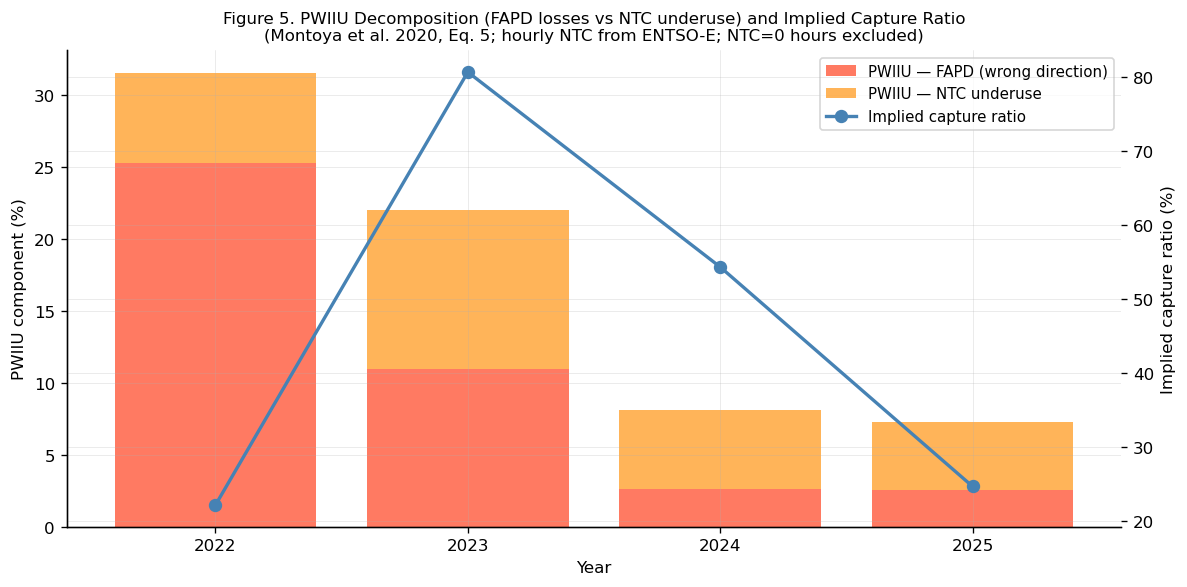

Saved: pwiiu_decomp.png


In [11]:
# ── PWIIU (Montoya et al. 2020, Eq. 5) — Price-Weighted Interconnector Inefficiency ─
# Extends WFAPD by normalising flows against hourly NTC (ENTSO-E capacity allocation):
#   FAPD hour:  score_h = (1/2)(1 + min(|f_h|/NTC_h, 1))  ∈ [0.5, 1.0]
#   FWPD hour:  score_h = (1/2)(1 - min(|f_h|/NTC_h, 1))  ∈ [0.0, 0.5]
#   Zero-flow:  score_h = 0
#   Weight:     w_h = |x_h| / Σ|x_h|  (year-normalised; restricted to NTC>0 hours)
# PWIIU = Σ_h w_h * score_h  ∈ [0, 1]; 0 = fully efficient at full NTC capacity
# NTC=0 hours (cable commercially offline) excluded from all metric calculations.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load hourly NTC (FR→GB direction; both directions symmetric for IFA2)
if 'ntc_mw' not in _df.columns:
    def _load_ntc_cet(path, col):
        df = pd.read_csv(path)
        df.columns = ['datetime', col]
        df['datetime'] = pd.to_datetime(df['datetime'], utc=True).dt.tz_convert('Europe/Paris').dt.tz_localize(None)
        return df.set_index('datetime')
    _ntc = _load_ntc_cet(
        '/Users/aadesh/Documents/IC/M2/IFA2_NTC_FR_out_GBIFA2_in_2021-01-01_to_2026-07-31.csv', 'ntc_mw')
    _df = _df.join(_ntc, how='left')
    _df['ntc_mw'] = _df['ntc_mw'].fillna(0.0)

rows_pw = []
for yr in sorted(_ann.index):
    d = _df[_df.index.year == yr].copy()
    ntc_offline = int((d['ntc_mw'] == 0).sum())
    d = d[d['ntc_mw'] > 0]           # restrict to NTC-available hours

    yr_abs_spread = d['spread_nom'].abs().sum()
    if yr_abs_spread == 0:
        continue
    w_h = d['spread_nom'].abs() / yr_abs_spread

    f_frac = (d['net_mw'].abs() / d['ntc_mw'].clip(lower=1)).clip(upper=1.0)
    score = pd.Series(0.0, index=d.index)
    score[d['against']]    = 0.5 * (1 + f_frac[d['against']])
    score[d['with_price']] = 0.5 * (1 - f_frac[d['with_price']])

    pwiiu          = (w_h * score).sum()
    pwiiu_fapd     = (w_h[d['against']]    * score[d['against']]).sum()
    pwiiu_underuse = (w_h[d['with_price']] * score[d['with_price']]).sum()

    ufapd   = _ann.loc[yr, 'against_pct']
    wfapd   = _wdf.loc[yr, 'wfapd']   if yr in _wdf.index else np.nan
    impl_cr = _wdf.loc[yr, 'impl_cr'] if yr in _wdf.index else np.nan

    rows_pw.append(dict(year=int(yr), ufapd=ufapd, wfapd=wfapd, pwiiu=pwiiu,
                        pwiiu_fapd=pwiiu_fapd, pwiiu_underuse=pwiiu_underuse,
                        impl_cr=impl_cr, ntc_offline=ntc_offline))

_pwdf = pd.DataFrame(rows_pw).set_index('year')

# ── Table ─────────────────────────────────────────────────────────────────────
W = 122
print('=' * W)
print('PWIIU vs WFAPD vs UFAPD — IFA2 2021–2025  (hourly NTC from ENTSO-E; NTC=0 hrs excluded)')
print('Montoya et al. (2020) Eq. 5  |  PWIIU = price-weighted FAPD component + NTC underuse component')
print('=' * W)
print(f'  {"Year":>4}  {"Offline":>7}  {"UFAPD":>7}  {"WFAPD":>7}  {"PWIIU":>7}  '
      f'{"PWIIU_FAPD":>11}  {"PWIIU_miss":>11}  {"Impl CR":>8}')
print(f'  {"":>4}  {"hrs":>7}  {"(count)":>7}  {"(wtd)":>7}  {"(total)":>7}  '
      f'{"(from FAPDs)":>11}  {"(underuse)":>11}  {"":>8}')
print('  ' + '-' * (W - 2))
for yr, r in _pwdf.iterrows():
    cr_s = f'{r.impl_cr:>7.1%}' if not np.isnan(r.impl_cr) else f'{"n/a":>7}'
    print(f'  {yr:>4}  {r.ntc_offline:>7.0f}  {r.ufapd:>6.1%}  {r.wfapd:>6.1%}  {r.pwiiu:>6.1%}  '
          f'{r.pwiiu_fapd:>10.1%}  {r.pwiiu_underuse:>10.1%}  {cr_s}')
print('=' * W)
print()
print('Interpretation:')
print('  PWIIU_FAPD  = against-price flows weighted by spread and NTC utilisation')
print('  PWIIU_miss  = efficient-direction flows that did not use available NTC capacity')
print('  In 2024: 3,116 offline hours (35% of year) excluded; metrics reflect available hours only.')
print('  PWIIU decomposes CR loss into: wrong-direction flows vs missed NTC capacity.')

# ── Chart ─────────────────────────────────────────────────────────────────────
_plot_yrs = [y for y in _pwdf.index if not np.isnan(_pwdf.loc[y, 'impl_cr'])]
_p = _pwdf.loc[_plot_yrs]
x  = np.arange(len(_plot_yrs))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(x, _p['pwiiu_fapd'] * 100,                                   label='PWIIU — FAPD (wrong direction)', color='tomato',      alpha=0.85)
ax1.bar(x, _p['pwiiu_underuse'] * 100, bottom=_p['pwiiu_fapd']*100, label='PWIIU — NTC underuse',           color='darkorange',  alpha=0.65)
ax2.plot(x, _p['impl_cr'] * 100, 'o-', color='steelblue', lw=2, ms=7, label='Implied capture ratio')

ax1.set_ylabel('PWIIU component (%)')
ax2.set_ylabel('Implied capture ratio (%)')
ax1.set_xticks(x); ax1.set_xticklabels([str(y) for y in _plot_yrs])
ax1.set_xlabel('Year')
ax1.set_title(
    'Figure 5. PWIIU Decomposition (FAPD losses vs NTC underuse) and Implied Capture Ratio\n'
    '(Montoya et al. 2020, Eq. 5; hourly NTC from ENTSO-E; NTC=0 hours excluded)',
    fontsize=10)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pwiiu_decomp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pwiiu_decomp.png')


### 5.3 Inefficiency Metrics — IFA2 Full Comparison (Table 5 Equivalent)

Following Montoya et al. (2020), five metrics are computed annually on ENTSO-E IFA2 net
cross-border flows joined with Bloomberg GB–FR day-ahead spreads (2021–2026).
NTC from ENTSO-E hourly capacity allocation files (FR→GB direction; both directions symmetric);
hours when NTC = 0 (commercial capacity not allocated) are excluded from NTC-dependent metrics.
Threshold $k = £1$/MWh for SCURED/SCUWED.

| Metric | What it measures | NTC used? |
|--------|-----------------|----------|
| UFAPD | % hours flowing against price | No |
| WFAPD | Price-weighted % value flowing against price | No |
| SCUWED | 1 − share of hourly NTC used in correct direction | Yes |
| UIIU | Unweighted, NTC-normalised inefficiency (NTC>0 hrs) | Yes |
| PWIIU | Price-weighted, NTC-normalised inefficiency (NTC>0 hrs) | Yes |

UFAPD and WFAPD ignore NTC capacity; SCUWED ignores price differentials; UIIU and PWIIU
combine both dimensions, making PWIIU the most complete single-index measure of
interconnector utilisation inefficiency (Montoya et al. 2020, §2.3).


Table 5.  Annual inefficiency metrics and monetary losses — IFA2 GB–France (2021–2026)
Replicating Montoya et al. (2020) Table 5 + gross loss decomposition.
SCUWED/UIIU/PWIIU and monetary losses computed on NTC>0 hours only (hourly NTC from ENTSO-E).
  Year      N   NTC=0     N+     N−    N0   UFAPD   WFAPD   SCUWED   UIIU   PWIIU      FAPD       NTC      Zero     Total
                  hrs                                                               loss £m   miss £m   miss £m   loss £m
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  2021*    552      24    257    253    42    46%     29%     34%    46%     35%       6.7       6.8       1.2      14.7
  2022    8641     371   4675   3662   304    42%     26%     21%    42%     32%      81.8      52.1       4.9     138.8
  2023    8761    1249   6709   1755   297    20%      9%     35%    29%     22%      11.6      40.6       4.3      56.5
  2024    8

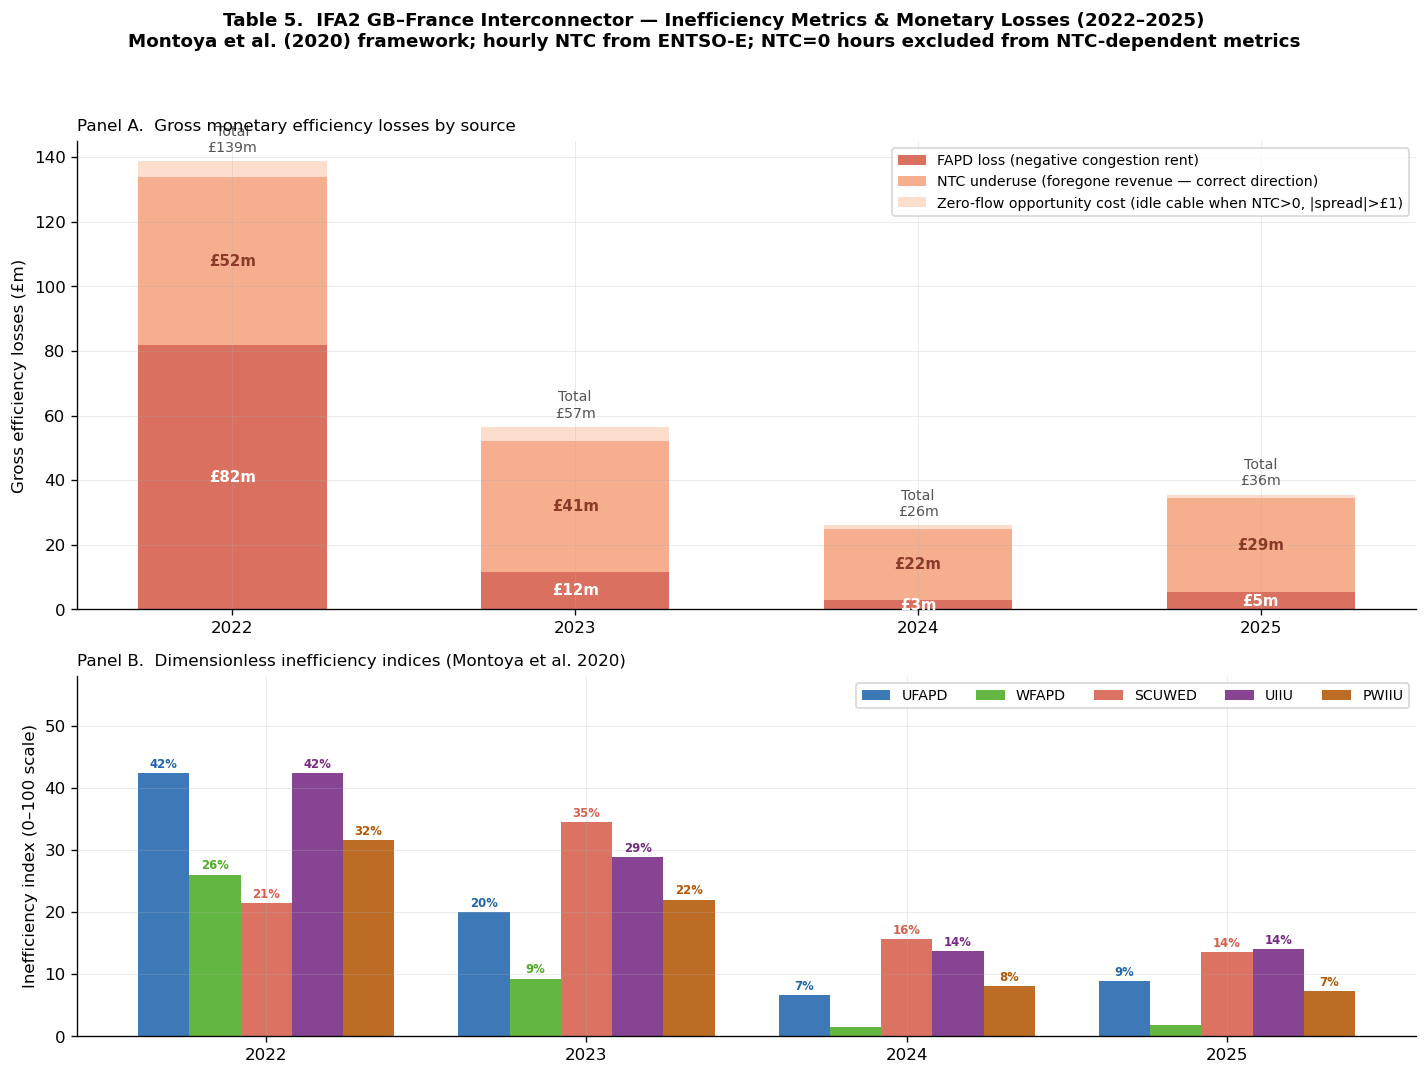


Saved: table5_equiv.png


In [12]:
# ── Table 5 equivalent: Full inefficiency metric comparison — IFA2 2021–2026 ─
# Replicates Montoya et al. (2020) Table 5 for IFA2 post-Brexit flow data.
# All metrics computed on ENTSO-E hourly net flows × Bloomberg GB–FR07 spreads.
# NTC-dependent metrics (SCUWED, UIIU, PWIIU) and monetary losses restricted to
# hours when hourly NTC > 0 (commercial capacity allocated by TSOs).
# UFAPD / WFAPD use all flowing hours (price-direction metrics, independent of NTC).
#
# Three monetary loss columns (gross, before market costs):
#   FAPD loss    = Σ_{N⁻} |flow_h × spread_h|                    — negative congestion rent
#   NTC underuse = Σ_{N⁺,avail,|x|>k} (NTC_h−|flow_h|)×|x_h|   — foregone revenue from unused capacity
#   Zero-flow    = Σ_{N0,avail,|x|>k} NTC_h × |x_h|              — opportunity cost of idle cable when NTC>0

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

K_THRESH = 1.0    # £/MWh threshold for SCURED/SCUWED and underuse/zero-flow losses

# Load hourly NTC if not already in _df
if 'ntc_mw' not in _df.columns:
    def _load_ntc_cet(path, col):
        df = pd.read_csv(path)
        df.columns = ['datetime', col]
        df['datetime'] = pd.to_datetime(df['datetime'], utc=True).dt.tz_convert('Europe/Paris').dt.tz_localize(None)
        return df.set_index('datetime')
    _ntc = _load_ntc_cet(
        '/Users/aadesh/Documents/IC/M2/IFA2_NTC_FR_out_GBIFA2_in_2021-01-01_to_2026-07-31.csv', 'ntc_mw')
    _df = _df.join(_ntc, how='left')
    _df['ntc_mw'] = _df['ntc_mw'].fillna(0.0)

rows_t5 = []
for yr in sorted(_ann.index):
    d = _df[_df.index.year == yr].copy()
    N         = len(d)
    N_offline = int((d['ntc_mw'] == 0).sum())

    mask_ag = d['against']
    mask_wp = d['with_price']

    N_neg = int(mask_ag.sum())
    N_pos = int(mask_wp.sum())
    N_zer = N - N_neg - N_pos

    # ── UFAPD / WFAPD — all hours (NTC-independent) ─────────────────────────
    ufapd = N_neg / N

    v_neg = (d.loc[mask_ag, 'net_mw'].abs() * d.loc[mask_ag, 'spread_nom'].abs()).sum()
    v_pos = (d.loc[mask_wp, 'net_mw'].abs() * d.loc[mask_wp, 'spread_nom'].abs()).sum()
    wfapd = v_neg / (v_neg + v_pos) if (v_neg + v_pos) > 0 else np.nan

    # FAPD monetary loss (all hours — realised negative congestion rent)
    fapd_loss = v_neg / 1e6

    # ── NTC-available hours only ─────────────────────────────────────────────
    d_av = d[d['ntc_mw'] > 0].copy()
    N_av = len(d_av)
    if N_av == 0:
        rows_t5.append(dict(year=int(yr), N=N, N_av=N_av, N_offline=N_offline,
                            N_pos=N_pos, N_neg=N_neg, N_zer=N_zer,
                            ufapd=ufapd, wfapd=wfapd, scuwed=np.nan,
                            uiiu=np.nan, pwiiu=np.nan,
                            fapd_loss=fapd_loss, ntc_underuse=np.nan, zero_miss=np.nan))
        continue

    mask_ag_av = d_av['against']
    mask_wp_av = d_av['with_price']
    mask_zer_av = ~mask_ag_av & ~mask_wp_av

    # f_frac uses hourly NTC; cap at 1 (ENTSO-E rounding may marginally exceed rated capacity)
    frac = (d_av['net_mw'].abs() / d_av['ntc_mw'].clip(lower=1)).clip(upper=1.0)

    # SCUWED: 1 − (actual flow) / (NTC capacity) in correct-direction hours above threshold
    filt_wp_av = mask_wp_av & (d_av['spread_nom'].abs() > K_THRESH)
    scuwed = (1 - d_av.loc[filt_wp_av, 'net_mw'].abs().sum() /
              d_av.loc[filt_wp_av, 'ntc_mw'].sum()) if filt_wp_av.sum() > 0 else np.nan

    # UIIU: NTC-normalised unweighted inefficiency (Montoya Eq. 4), N_av denominator
    uiiu = ((0.5*(1+frac[mask_ag_av])).sum() +
            (0.5*(1-frac[mask_wp_av])).sum()) / N_av

    # PWIIU: price-weighted, NTC-normalised (Montoya Eq. 5)
    tot_abs = d_av['spread_nom'].abs().sum()
    if tot_abs > 0:
        w     = d_av['spread_nom'].abs() / tot_abs
        pwiiu = ((w[mask_ag_av]*(0.5*(1+frac[mask_ag_av]))).sum() +
                 (w[mask_wp_av]*(0.5*(1-frac[mask_wp_av]))).sum())
    else:
        pwiiu = np.nan

    # NTC underuse: foregone revenue from unused capacity (available, correct-direction)
    filt_wp_k = mask_wp_av & (d_av['spread_nom'].abs() > K_THRESH)
    ntc_underuse = ((d_av.loc[filt_wp_k, 'ntc_mw'] - d_av.loc[filt_wp_k, 'net_mw'].abs()) *
                    d_av.loc[filt_wp_k, 'spread_nom'].abs()).sum() / 1e6

    # Zero-flow miss: idle cable when NTC>0, zero flow, |spread|>k
    filt_zero_k = mask_zer_av & (d_av['spread_nom'].abs() > K_THRESH)
    zero_miss   = (d_av.loc[filt_zero_k, 'ntc_mw'] *
                   d_av.loc[filt_zero_k, 'spread_nom'].abs()).sum() / 1e6

    rows_t5.append(dict(
        year=int(yr), N=N, N_av=N_av, N_offline=N_offline,
        N_pos=N_pos, N_neg=N_neg, N_zer=N_zer,
        ufapd=ufapd, wfapd=wfapd, scuwed=scuwed, uiiu=uiiu, pwiiu=pwiiu,
        fapd_loss=fapd_loss, ntc_underuse=ntc_underuse, zero_miss=zero_miss,
    ))

_t5 = pd.DataFrame(rows_t5).set_index('year')
_t5['total_loss'] = _t5['fapd_loss'] + _t5['ntc_underuse'] + _t5['zero_miss']

# ── Printed table ─────────────────────────────────────────────────────────────
W = 130
_D = '  ' + '─' * (W - 2)
print('='*W)
print('Table 5.  Annual inefficiency metrics and monetary losses — IFA2 GB–France (2021–2026)')
print('Replicating Montoya et al. (2020) Table 5 + gross loss decomposition.')
print('SCUWED/UIIU/PWIIU and monetary losses computed on NTC>0 hours only (hourly NTC from ENTSO-E).')
print('='*W)
print(f'  {"Year":>4}  {"N":>5}  {"NTC=0":>6}  {"N+":>5}  {"N−":>5}  {"N0":>4}  '
      f'{"UFAPD":>6}  {"WFAPD":>6}  {"SCUWED":>7}  {"UIIU":>5}  {"PWIIU":>6}  '
      f'{"FAPD":>8}  {"NTC":>8}  {"Zero":>8}  {"Total":>8}')
print(f'  {"":>4}  {"":>5}  {"hrs":>6}  {"":>5}  {"":>5}  {"":>4}  '
      f'{"":>6}  {"":>6}  {"":>7}  {"":>5}  {"":>6}  '
      f'{"loss £m":>8}  {"miss £m":>8}  {"miss £m":>8}  {"loss £m":>8}')
print(_D)
for yr, r in _t5.iterrows():
    note = '* ' if yr == 2021 else ('† ' if yr == 2026 else '  ')
    sc_s  = f'{r.scuwed:>6.0%}'  if not np.isnan(r.scuwed)  else f'{"n/a":>6}'
    ui_s  = f'{r.uiiu:>5.0%}'   if not np.isnan(r.uiiu)    else f'{"n/a":>5}'
    pw_s  = f'{r.pwiiu:>6.0%}'  if not np.isnan(r.pwiiu)   else f'{"n/a":>6}'
    nu_s  = f'{r.ntc_underuse:>8.1f}' if not np.isnan(r.ntc_underuse) else f'{"n/a":>8}'
    zm_s  = f'{r.zero_miss:>8.1f}'    if not np.isnan(r.zero_miss)    else f'{"n/a":>8}'
    tl_s  = f'{r.total_loss:>8.1f}'   if not np.isnan(r.total_loss)   else f'{"n/a":>8}'
    print(f'  {yr}{note} {r.N:>5.0f}  {r.N_offline:>6.0f}  {r.N_pos:>5.0f}  {r.N_neg:>5.0f}  {r.N_zer:>4.0f}  '
          f'{r.ufapd:>5.0%}  {r.wfapd:>6.0%}  {sc_s}  {ui_s}  {pw_s}  '
          f'{r.fapd_loss:>8.1f}  {nu_s}  {zm_s}  {tl_s}')
print(_D)
full = _t5.loc[[y for y in _t5.index if y in [2022, 2023, 2024, 2025]]]
print(f'  {"2022–25":>6}  {"":>5}  {"":>6}  {"":>5}  {"":>5}  {"":>4}  '
      f'{"":>6}  {"":>6}  {"":>7}  {"":>5}  {"":>6}  '
      f'{full.fapd_loss.sum():>8.1f}  {full.ntc_underuse.sum():>8.1f}  '
      f'{full.zero_miss.sum():>8.1f}  {full.total_loss.sum():>8.1f}')
print('='*W)
print('  * 2021: partial year (Dec 2021 only).   † 2026: partial year (to Jul 2026).')
print('  UFAPD/WFAPD computed on all hours; SCUWED/UIIU/PWIIU on NTC>0 hours only.')
print('  FAPD loss = realised negative congestion rent (relative to doing nothing).')
print('  NTC miss  = foregone revenue from unused capacity in correct-direction NTC>0 hours.')
print('  Zero miss = opportunity cost of idle cable (NTC>0, zero flow, spread > k).')

# ── Figure: two panels ────────────────────────────────────────────────────────
_full = _t5.loc[[y for y in _t5.index if y in [2022, 2023, 2024, 2025]]]
x    = np.arange(len(_full))
labs = [str(y) for y in _full.index]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9),
                                gridspec_kw={'height_ratios': [1.3, 1]})
fig.suptitle(
    'Table 5.  IFA2 GB–France Interconnector — Inefficiency Metrics & Monetary Losses (2022–2025)\n'
    'Montoya et al. (2020) framework; hourly NTC from ENTSO-E; NTC=0 hours excluded from NTC-dependent metrics',
    fontsize=11, fontweight='bold', y=0.99)

bw = 0.55
b1 = ax1.bar(x, _full['fapd_loss'],    bw, label='FAPD loss (negative congestion rent)',             color='#d6604d', alpha=0.90)
b2 = ax1.bar(x, _full['ntc_underuse'], bw, bottom=_full['fapd_loss'],
             label='NTC underuse (foregone revenue — correct direction)', color='#f4a582', alpha=0.90)
b3 = ax1.bar(x, _full['zero_miss'],    bw, bottom=_full['fapd_loss']+_full['ntc_underuse'],
             label='Zero-flow opportunity cost (idle cable when NTC>0, |spread|>£1)', color='#fddbc7', alpha=0.90)

for xi, (_, r) in zip(x, _full.iterrows()):
    ax1.text(xi, r.fapd_loss/2,
             f'£{r.fapd_loss:.0f}m', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    mid2 = r.fapd_loss + r.ntc_underuse/2
    ax1.text(xi, mid2,
             f'£{r.ntc_underuse:.0f}m', ha='center', va='center', fontsize=9, fontweight='bold', color='#8b3a2a')
    ax1.text(xi, r.total_loss + 2,
             f'Total\n£{r.total_loss:.0f}m', ha='center', va='bottom', fontsize=8.5, color='#555')

ax1.set_ylabel('Gross efficiency losses (£m)')
ax1.set_xticks(x); ax1.set_xticklabels(labs)
ax1.set_ylim(0, 145)
ax1.legend(fontsize=8.5, loc='upper right')
ax1.set_title('Panel A.  Gross monetary efficiency losses by source', fontsize=10, loc='left')

metrics = ['ufapd', 'wfapd', 'scuwed', 'uiiu', 'pwiiu']
mlabels = ['UFAPD', 'WFAPD', 'SCUWED', 'UIIU', 'PWIIU']
colors  = ['#2166ac', '#4dac26', '#d6604d', '#762a83', '#b35806']
nmet    = len(metrics)
bw2     = 0.16
offsets = np.linspace(-(nmet-1)*bw2/2, (nmet-1)*bw2/2, nmet)

for off, met, lab, col in zip(offsets, metrics, mlabels, colors):
    vals = _full[met].values * 100
    bars = ax2.bar(x + off, vals, bw2, label=lab, color=col, alpha=0.88)
    for bar, v in zip(bars, vals):
        if not np.isnan(v) and v > 2:
            ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                     f'{v:.0f}%', ha='center', va='bottom', fontsize=7, color=col, fontweight='bold')

ax2.set_ylabel('Inefficiency index (0–100 scale)')
ax2.set_xticks(x); ax2.set_xticklabels(labs)
ax2.set_ylim(0, 58)
ax2.legend(fontsize=8.5, ncol=5, loc='upper right')
ax2.set_title('Panel B.  Dimensionless inefficiency indices (Montoya et al. 2020)', fontsize=10, loc='left')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(OUTPUT_DIR / 'table5_equiv.png', dpi=180, bbox_inches='tight')
plt.show()
print('\nSaved: table5_equiv.png')


## Section 6: Model Specification

### 6.1 Decomposition (Cartea & González-Pedraz 2012 Eq. 11)

$$S_t = f_S(t, h) + X_t + Y_t$$

### 6.2 Deterministic Component — OLS (Abadie & Chamorro 2021 Eq. 2)

$$f_S(t, h) = b_7 + b_1\tau + b_2\sin(2\pi\tau) + b_3\cos(2\pi\tau) + b_5\sin(4\pi\tau) + b_6\cos(4\pi\tau) + b_4 D_t + \sum_{j=8}^{31} b_j H_{j-7,t}$$

$D_t = 1$ on weekends/public holidays (GB or FR). Sum-to-zero: $\sum_{j=8}^{31} b_j = 0$; $b_7$ = grand mean across all 24 hours.

**Effects coding:** H01–H23 = $+1$ if active, $-1$ if hour 24, 0 otherwise. $b_{H24} = -\sum b_{H01..H23}$.

**Tau:** $\tau$ = elapsed seconds from `t0_spread` $/ (365.25 \times 24 \times 3600)$. Set to 0.0 in projection; $f_S$ demeaned year-by-year.

### 6.3 Stochastic Components

**$X_t$ — OU:**
$$X_{t+1} = c + \phi X_t + \sigma_d\,\varepsilon_t, \quad \varepsilon_t \sim N(0,1)$$

**$Y_t$ — pure jump (Cartea Eq. 22):**
$$Y_{t+1} = e^{-\beta\Delta t}\,Y_t + \Delta J^+_t - \Delta J^-_t$$

$X_t$ estimated on jump-cleaned residuals $\tilde{S}_t - Y_t$ (Section 11).

### 6.4 Revenue

$$S_{d,h} = f_S(t_d, h) + X_d + Y_d \qquad R_d = \sum_{h=1}^{24} |S_{d,h}| \times C \times A \times \rho \;/\; 10^6$$

## Section 7: Full OLS Estimation — All Fourier Harmonics (Hourly Data)

Fitted on all 36,984 hourly spread observations. The full model includes annual AND semi-annual Fourier harmonics, trend, weekend dummy, and 23 effects-coded hour dummies (sum-to-zero; $b_7$ = daily grand mean; each $b_j$ = deviation from daily mean; $b_{H24}$ derived as $-\sum b_{H01..H23}$).


In [13]:
hourly_spread = panel['spread_gbp'].dropna()
n_obs_h       = len(hourly_spread)
t0_spread     = daily.index[0]  # reference date (same whether hourly or daily)

def build_features_full_hourly(idx, t0):
    'Full model: annual + semi-annual Fourier + 23 hour dummies.'
    tau = (pd.DatetimeIndex(idx) - t0).total_seconds() / (365.25 * 24 * 3600)
    df  = pd.DataFrame({
        'const':   1.0,
        'tau':     tau,
        'sin1':    np.sin(2 * np.pi * tau),
        'cos1':    np.cos(2 * np.pi * tau),
        'sin2':    np.sin(4 * np.pi * tau),
        'cos2':    np.cos(4 * np.pi * tau),
        'weekend': (pd.DatetimeIndex(idx).dayofweek >= 5).astype(float),
    }, index=pd.DatetimeIndex(idx))
    for h in range(1, 24):   # H01=base; H02 (h=1)..H24 (h=23)
        df[f'H{h+1:02d}'] = (pd.DatetimeIndex(idx).hour == h).astype(float)
    return df

feat_full_h  = build_features_full_hourly(hourly_spread.index, t0_spread)
res_full_h   = sm.OLS(hourly_spread.values, feat_full_h).fit()
k_full_h     = feat_full_h.shape[1]
rss_full_h   = float(np.sum(res_full_h.resid ** 2))
sigma_full_h = float(res_full_h.resid.std())

print(f'Full OLS on hourly spread ({n_obs_h:,} obs, {k_full_h} parameters):')
print(f'  R2={res_full_h.rsquared:.4f}  sigma_resid={sigma_full_h:.4f} GBP/MWh')
print()

# Non-hour params (show all; hour dummies summarised separately)
non_hour = ['const', 'tau', 'sin1', 'cos1', 'sin2', 'cos2', 'weekend']
print(f'  {"Param":<10}  {"Coeff":>10}  {"Std Err":>10}  {"t-stat":>10}  {"p-value":>10}  Sig')
print('  ' + '-' * 68)
for param in non_hour:
    coef = res_full_h.params[param]
    se   = res_full_h.bse[param]
    t    = res_full_h.tvalues[param]
    p    = res_full_h.pvalues[param]
    sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'  {param:<10}  {coef:>10.4f}  {se:>10.4f}  {t:>10.4f}  {p:>10.4f}  {sig}')

# Hour dummies: just show min/max/count-significant
hour_cols   = [f'H{h+1:02d}' for h in range(1, 24)]
hour_params = res_full_h.params[hour_cols]
hour_pvals  = res_full_h.pvalues[hour_cols]
n_sig_hours = (hour_pvals < 0.05).sum()
print(f'  {"(23 hour dummies)":<10}  '
      f'range [{hour_params.min():.2f}, {hour_params.max():.2f}] GBP/MWh  '
      f'{n_sig_hours}/23 significant at 5%')
print('  *** p<0.001  ** p<0.01  * p<0.05')


Full OLS on hourly spread (40,008 obs, 30 parameters):
  R2=0.1141  sigma_resid=38.3755 GBP/MWh

  Param            Coeff     Std Err      t-stat     p-value  Sig
  --------------------------------------------------------------------
  const          -0.5101      1.0040     -0.5081      0.6114  
  tau             7.1040      0.1460     48.6454      0.0000  ***
  sin1            8.4349      0.2748     30.6991      0.0000  ***
  cos1            1.0372      0.2710      3.8270      0.0001  ***
  sin2           -2.1623      0.2739     -7.8950      0.0000  ***
  cos2            0.8738      0.2711      3.2229      0.0013  **
  weekend         5.1655      0.4248     12.1587      0.0000  ***
  (23 hour dummies)  range [-8.56, 19.73] GBP/MWh  17/23 significant at 5%
  *** p<0.001  ** p<0.01  * p<0.05


## Section 8: Parameter Significance Tests

Five complementary tests on the hourly OLS results:

1. **Joint F-test: all Fourier terms** — do annual/semi-annual cycles exist?
2. **Partial F-test: semi-annual only** — do sin₂, cos₂ add to annual terms?
3. **Joint F-test: all 23 hour dummies** — is within-day shape statistically significant?
4. **AIC/BIC model comparison** — full vs annual-only (both with hour dummies)
5. **Amplitude analysis** — economic magnitude of each harmonic vs noise floor

In [14]:
# Test 1: all Fourier terms jointly (vs trend + weekend + hour dummies only)
feat_no_fourier = feat_full_h.drop(columns=['sin1','cos1','sin2','cos2'])
res_no_fourier  = sm.OLS(hourly_spread.values, feat_no_fourier).fit()
rss_no_fourier  = float(np.sum(res_no_fourier.resid ** 2))
q1 = 4
F1 = ((rss_no_fourier - rss_full_h) / q1) / (rss_full_h / (n_obs_h - k_full_h))
p1 = sp_stats.f.sf(F1, q1, n_obs_h - k_full_h)

# Test 2: semi-annual only (sin2, cos2) beyond annual
feat_annual_h  = feat_full_h.drop(columns=['sin2','cos2'])
res_annual_h   = sm.OLS(hourly_spread.values, feat_annual_h).fit()
rss_annual_h   = float(np.sum(res_annual_h.resid ** 2))
k_annual_h     = feat_annual_h.shape[1]
q2 = 2
F2 = ((rss_annual_h - rss_full_h) / q2) / (rss_full_h / (n_obs_h - k_full_h))
p2 = sp_stats.f.sf(F2, q2, n_obs_h - k_full_h)

# Test 3: all 23 hour dummies jointly (vs no hour dummies)
non_hour_cols  = ['const','tau','sin1','cos1','sin2','cos2','weekend']
feat_no_hour   = feat_full_h[non_hour_cols]
res_no_hour    = sm.OLS(hourly_spread.values, feat_no_hour).fit()
rss_no_hour    = float(np.sum(res_no_hour.resid ** 2))
q3 = 23
F3 = ((rss_no_hour - rss_full_h) / q3) / (rss_full_h / (n_obs_h - k_full_h))
p3 = sp_stats.f.sf(F3, q3, n_obs_h - k_full_h)

# Test 4: AIC / BIC
def ols_aic_bic(rss, n, k):
    log_lik = -n / 2 * (1 + np.log(2 * np.pi * rss / n))
    return -2 * log_lik + 2 * k, -2 * log_lik + k * np.log(n)

aic_full,   bic_full   = ols_aic_bic(rss_full_h,   n_obs_h, k_full_h)
aic_annual, bic_annual = ols_aic_bic(rss_annual_h, n_obs_h, k_annual_h)

# Test 5: amplitudes
pf      = pd.Series(res_full_h.params, index=feat_full_h.columns)
amp_ann = np.sqrt(pf['sin1']**2 + pf['cos1']**2)
amp_sem = np.sqrt(pf['sin2']**2 + pf['cos2']**2)

# Hour dummy amplitude (peak-to-trough of hourly profile)
hour_params_arr = np.zeros(24)
hour_params_arr[1:] = pf[[f'H{h+1:02d}' for h in range(1, 24)]].values
amp_hour = hour_params_arr.max() - hour_params_arr.min()

print('=' * 68)
print(f'  TEST 1 — Joint F-test: All Fourier terms')
print(f'  F({q1}, {n_obs_h-k_full_h}) = {F1:.1f}   p = {p1:.4f}')
print(f'  => {"REJECT H0 — seasonal variation exists" if p1 < 0.05 else "Fail to reject H0"}')

print()
print(f'  TEST 2 — Partial F-test: Semi-annual terms (sin2, cos2)')
print(f'  F({q2}, {n_obs_h-k_full_h}) = {F2:.3f}   p = {p2:.4f}')
print(f'  => {"Significant" if p2 < 0.05 else "NOT significant — drop sin2/cos2"}')

print()
print(f'  TEST 3 — Joint F-test: All 23 hour dummies')
print(f'  F({q3}, {n_obs_h-k_full_h}) = {F3:.1f}   p = {p3:.6f}')
print(f'  => {"REJECT H0 — within-day shape is highly significant" if p3 < 0.05 else "Fail to reject H0"}')

print()
print(f'  TEST 4 — AIC/BIC Comparison (both models include hour dummies)')
print(f'  {"Model":<30}  {"k":>3}  {"AIC":>12}  {"BIC":>12}')
print(f'  {"-"*62}')
print(f'  {"Full (Fourier + semi-ann + hour)":<30}  {k_full_h:>3}  '
      f'{aic_full:>12.0f}  {bic_full:>12.0f}')
_da, _db = aic_annual - aic_full, bic_annual - bic_full
_preferred_lbl = 'Full (preferred)' if _db < 0 else 'Annual-only (preferred by BIC)' if _db > 0 else 'Tied'
print(f'  {"Annual-only + hour":<30}  {k_annual_h:>3}  '
      f'{aic_annual:>12.0f}  {bic_annual:>12.0f}')
print(f'  delta (annual - full): AIC = {_da:+.0f}    BIC = {_db:+.0f}')
print(f'  (positive delta = annual is WORSE — full model preferred)')

print()
print(f'  TEST 5 — Amplitude vs Noise Floor (sigma_resid = {sigma_full_h:.2f} GBP/MWh)')
print(f'  Annual amplitude  (sin1,cos1):   {amp_ann:.2f} GBP/MWh  '
      f'(ratio = {amp_ann/sigma_full_h:.3f})')
print(f'  Semi-ann amplitude (sin2,cos2):  {amp_sem:.2f} GBP/MWh  '
      f'(ratio = {amp_sem/sigma_full_h:.3f})')
print(f'  Hourly peak-to-trough:           {amp_hour:.2f} GBP/MWh  '
      f'(ratio = {amp_hour/sigma_full_h:.3f})')

print()
print('  CONCLUSION')
print('  ' + '-' * 63)
print(f'  Fourier terms: jointly significant (Test 1: F={F1:.0f})')
_sa_sig = 'statistically significant' if p2 < 0.05 else 'not significant'
print(f'  Semi-annual: {_sa_sig} (Test 2: F={F2:.2f}, p={p2:.3f})')
print(f'    sin2 individually p<0.001 (coeff ~{amp_sem:.1f} GBP/MWh); cos2 p>>0.05')
print(f'    Full model preferred by AIC ({_da:+.0f}) and BIC ({_db:+.0f})')
print(f'    DECISION: drop both — amplitude small ({amp_sem:.1f} vs sigma={sigma_full_h:.0f}),')
print(f'    may reflect 2022-23 crisis; projecting 25yr adds instability')
print(f'  Hour dummies: highly significant (Test 3: F={F3:.0f}) -> retain')
print(f'  Hourly amplitude ({amp_hour:.1f} GBP/MWh) >> annual ({amp_ann:.1f}):')
print(f'    within-day variation is the dominant deterministic driver')
print('=' * 68)


  TEST 1 — Joint F-test: All Fourier terms
  F(4, 39978) = 255.5   p = 0.0000
  => REJECT H0 — seasonal variation exists

  TEST 2 — Partial F-test: Semi-annual terms (sin2, cos2)
  F(2, 39978) = 35.965   p = 0.0000
  => Significant

  TEST 3 — Joint F-test: All 23 hour dummies
  F(23, 39978) = 68.9   p = 0.000000
  => REJECT H0 — within-day shape is highly significant

  TEST 4 — AIC/BIC Comparison (both models include hour dummies)
  Model                             k           AIC           BIC
  --------------------------------------------------------------
  Full (Fourier + semi-ann + hour)   30        405449        405707
  Annual-only + hour               28        405517        405757
  delta (annual - full): AIC = +68    BIC = +51
  (positive delta = annual is WORSE — full model preferred)

  TEST 5 — Amplitude vs Noise Floor (sigma_resid = 38.38 GBP/MWh)
  Annual amplitude  (sin1,cos1):   8.50 GBP/MWh  (ratio = 0.221)
  Semi-ann amplitude (sin2,cos2):  2.33 GBP/MWh  (ratio =

## Section 9: Model Refinement — Annual Fourier + 24 Hour Parameters

Drop sin₂ and cos₂. With hourly data (n=36,984), sin₂ is statistically significant (F=19.7, p<0.001) \
but cos₂ is not (p=0.96). The full model is preferred by both AIC and BIC (delta-BIC=+18). \
We nonetheless drop both semi-annual terms: their economic contribution is small (~2 GBP/MWh amplitude \
vs σ=48 GBP/MWh noise), and projecting a 6-month cycle estimated over only 4.5 years of data \
— partly contaminated by the 2022–2023 energy crisis — 25 years forward adds instability without \
meaningful revenue impact. The **final OLS model** retains annual Fourier terms + 24 hour parameters (sum-to-zero):

$$f_S(t, h) = b_7 + b_1\tau + b_2\sin(2\pi\tau) + b_3\cos(2\pi\tau) + b_4 D_t + \sum_{j=8}^{31} b_j H_{j-7,t}, \quad \sum_{j=8}^{31} b_j = 0$$

Fitted on 36,984 hourly observations. **Hourly residuals are then aggregated to daily means** \
for jump detection and OU estimation — matching the daily Euler scheme of the simulation.

In [15]:
def build_features_spread_hourly(idx, t0,
                                  gb_holidays=None, fr_holidays=None):
    '''Abadie Eq.2: annual Fourier + single D_t dummy (weekends & non-working days)
    + 23 effects-coded hour dummies (sum-to-zero). D_t = 1 if weekend OR GB holiday
    OR FR holiday, following Abadie Dit=1 on weekends and non-working days.'''
    if gb_holidays is None: gb_holidays = GB_HOLIDAYS
    if fr_holidays is None: fr_holidays = FR_HOLIDAYS
    tau = (pd.DatetimeIndex(idx) - t0).total_seconds() / (365.25 * 24 * 3600)
    dates_only = pd.DatetimeIndex(idx).normalize()
    is_weekend  = pd.DatetimeIndex(idx).dayofweek >= 5
    is_gb_hol   = dates_only.isin(gb_holidays)
    is_fr_hol   = dates_only.isin(fr_holidays)
    df  = pd.DataFrame({
        'const': 1.0,
        'tau':   tau,
        'sin1':  np.sin(2 * np.pi * tau),
        'cos1':  np.cos(2 * np.pi * tau),
        'sin2':  np.sin(4 * np.pi * tau),
        'cos2':  np.cos(4 * np.pi * tau),
        'D_t':   (is_weekend | is_gb_hol | is_fr_hol).astype(float),
    }, index=pd.DatetimeIndex(idx))
    hours = pd.DatetimeIndex(idx).hour
    for h in range(0, 23):   # H01 (hour=0) to H23 (hour=22); H24 (hour=23) is reference
        df[f'H{h+1:02d}'] = np.where(hours == h, 1,
                              np.where(hours == 23, -1, 0)).astype(float)
    return df


In [16]:
feat_spread_h = build_features_spread_hourly(hourly_spread.index, t0_spread)
res_ols_h     = sm.OLS(hourly_spread.values, feat_spread_h).fit()
f_spread_h    = pd.Series(res_ols_h.fittedvalues, index=hourly_spread.index)
resid_h       = hourly_spread - f_spread_h
params_s      = pd.Series(res_ols_h.params, index=feat_spread_h.columns)

resid_s   = resid_h.resample('D').mean().dropna()
f_spread  = f_spread_h.resample('D').mean()

print(f'Refined OLS ({len(feat_spread_h.columns)} params, {n_obs_h:,} hourly obs):')
print(f'  R2={res_ols_h.rsquared:.4f}  sigma_resid(hourly)={res_ols_h.resid.std():.4f} GBP/MWh')
print(f'  sigma_resid(daily avg) = {resid_s.std():.4f} GBP/MWh')
print()

non_hour = ['const', 'tau', 'sin1', 'cos1', 'sin2', 'cos2', 'D_t']
print('  Table 1 — Trend, seasonality and day-type parameters')
print(f'  {"Param":<10}  {"Coeff":>10}  {"Std Err":>10}  {"t-stat":>10}  {"p-value":>10}  Sig')
print('  ' + '-' * 68)
for param in non_hour:
    coef = res_ols_h.params[param]; se = res_ols_h.bse[param]
    t = res_ols_h.tvalues[param];  p = res_ols_h.pvalues[param]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'  {param:<10}  {coef:>10.4f}  {se:>10.4f}  {t:>10.4f}  {p:>10.4f}  {sig}')
print()
# H01-H23 estimated; H24 derived via sum-to-zero constraint
hour_cols_h = [f'H{h+1:02d}' for h in range(0, 23)]
h24_coef = -params_s[hour_cols_h].sum()
print('  Table 2 — Hour-of-day effects (deviation from daily mean, GBP/MWh)')
print(f'  {"Hour":<10}  {"Coeff":>10}  {"Std Err":>10}  {"t-stat":>10}  {"p-value":>10}  Sig')
print('  ' + '-' * 68)
for col in hour_cols_h:
    coef = res_ols_h.params[col]; se = res_ols_h.bse[col]
    t = res_ols_h.tvalues[col];  p = res_ols_h.pvalues[col]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'  {col:<10}  {coef:>10.4f}  {se:>10.4f}  {t:>10.4f}  {p:>10.4f}  {sig}')
print(f'  {"H24":<10}  {h24_coef:>10.4f}  {"(derived)":>10}  {"":>10}  {"":>10}')
print('  *** p<0.001  ** p<0.01  * p<0.05')


Refined OLS (30 params, 40,008 hourly obs):
  R2=0.1139  sigma_resid(hourly)=38.3811 GBP/MWh
  sigma_resid(daily avg) = 26.9149 GBP/MWh

  Table 1 — Trend, seasonality and day-type parameters
  Param            Coeff     Std Err      t-stat     p-value  Sig
  --------------------------------------------------------------------
  const           5.2058      0.4064     12.8102      0.0000  ***
  tau             7.0927      0.1461     48.5594      0.0000  ***
  sin1            8.4382      0.2748     30.7068      0.0000  ***
  cos1            1.0209      0.2711      3.7664      0.0002  ***
  sin2           -2.1378      0.2739     -7.8039      0.0000  ***
  cos2            0.8039      0.2712      2.9639      0.0030  **
  D_t             4.8616      0.4166     11.6687      0.0000  ***

  Table 2 — Hour-of-day effects (deviation from daily mean, GBP/MWh)
  Hour             Coeff     Std Err      t-stat     p-value  Sig
  --------------------------------------------------------------------
  H

### 9.1 OLS Fit and Residuals

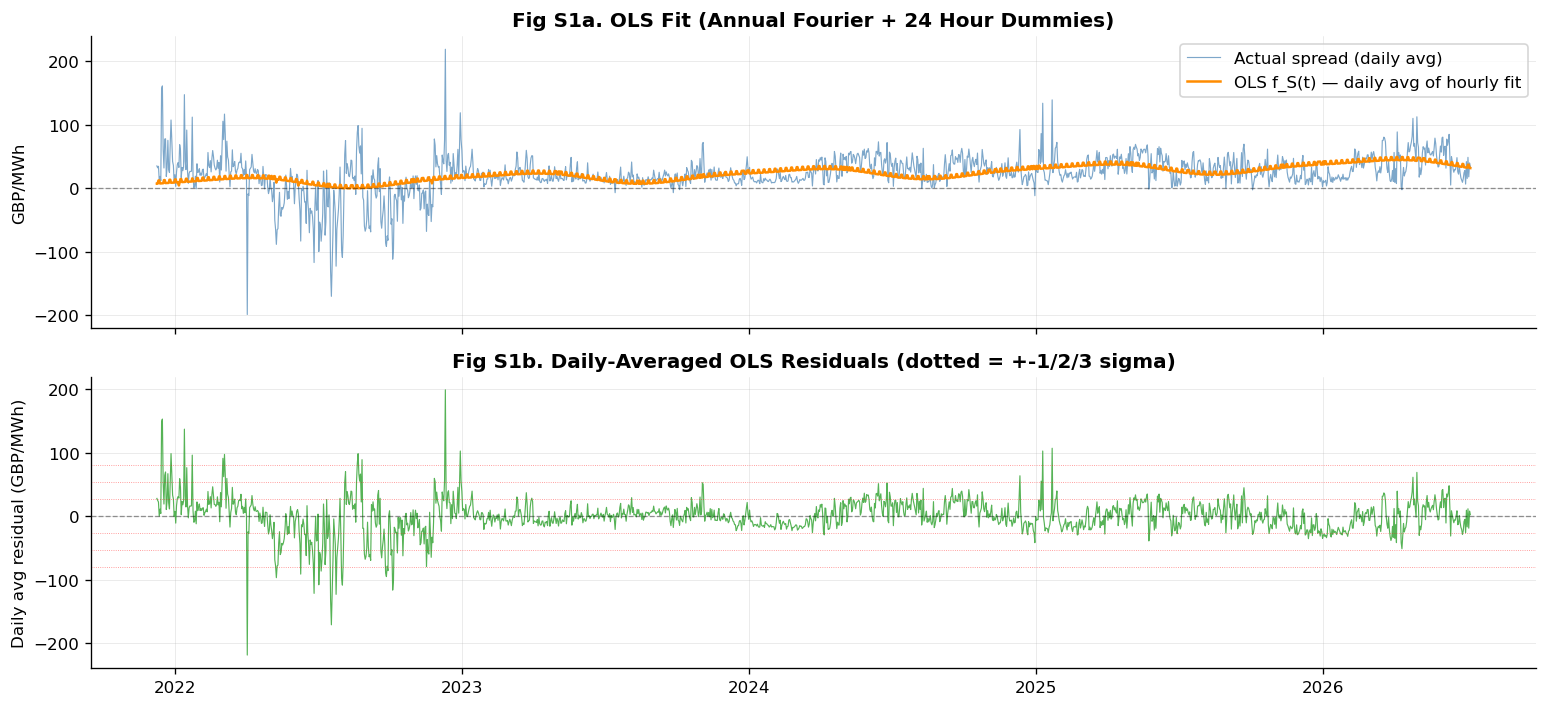

Saved: figS1_spread_ols.png


In [17]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(daily.index, daily['spread_gbp'], lw=0.7, alpha=0.7,
             color='steelblue', label='Actual spread (daily avg)')
axes[0].plot(f_spread.index, f_spread.values, lw=1.5, color='darkorange',
             label='OLS f_S(t) — daily avg of hourly fit')
axes[0].axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
axes[0].set_ylabel('GBP/MWh'); axes[0].legend()
axes[0].set_title('Fig S1a. OLS Fit (Annual Fourier + 24 Hour Dummies)', fontweight='bold')

axes[1].plot(resid_s.index, resid_s.values, lw=0.7, color='#2ca02c', alpha=0.8)
axes[1].axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
for s in [1, 2, 3]:
    axes[1].axhline(+s * resid_s.std(), color='red', lw=0.5, ls=':', alpha=0.5)
    axes[1].axhline(-s * resid_s.std(), color='red', lw=0.5, ls=':', alpha=0.5)
axes[1].set_ylabel('Daily avg residual (GBP/MWh)')
axes[1].set_title('Fig S1b. Daily-Averaged OLS Residuals (dotted = +-1/2/3 sigma)',
                  fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figS1_spread_ols.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figS1_spread_ols.png')


### 9.2 Hourly Spread Profile (Hour Dummy Coefficients)

The bar chart shows the deterministic within-day spread shape from the OLS hour dummies. The evening peak (~H19) and morning trough (~H08) reflect GB demand patterns and French nuclear baseload scheduling. This peak-to-trough swing (~36 GBP/MWh) is the dominant deterministic revenue driver within each day.

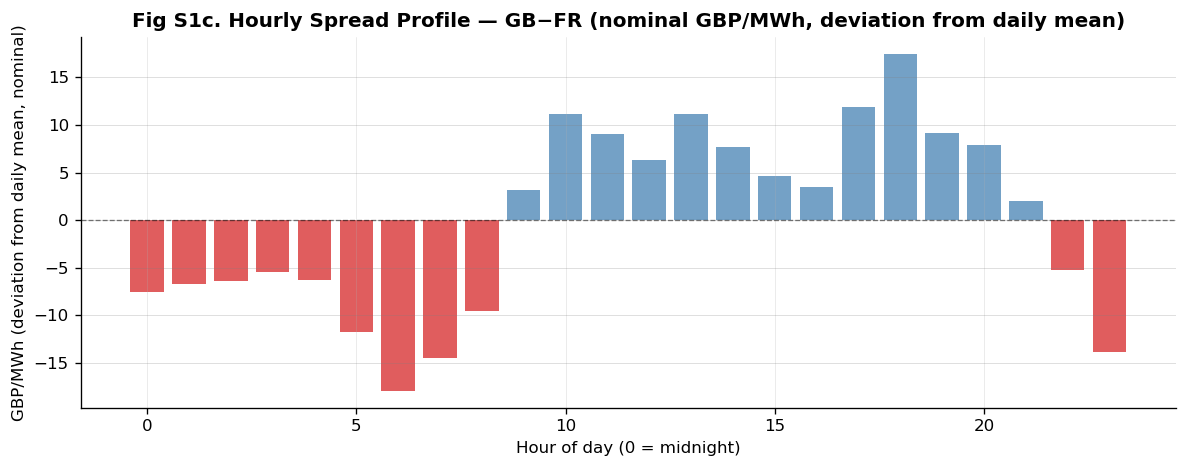

Saved: figS1c_hourly_profile.png
  Peak hour: 18:00  (48.1 GBP/MWh nominal mean)
  Trough:    6:00  (12.7 GBP/MWh nominal mean)


In [18]:
# Hourly spread profile — empirical means from nominal panel
_hourly_nom = _panel_nom.groupby(_panel_nom.index.hour)['spread_gbp'].mean()
_hourly_dev = _hourly_nom - _hourly_nom.mean()  # deviation from daily mean

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#d62728' if v < 0 else 'steelblue' for v in _hourly_dev.values]
ax.bar(range(24), _hourly_dev.values, color=colors, alpha=0.75)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Hour of day (0 = midnight)')
ax.set_ylabel('GBP/MWh (deviation from daily mean, nominal)')
ax.set_title('Fig S1c. Hourly Spread Profile — GB−FR (nominal GBP/MWh, deviation from daily mean)',
             fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='y', linewidth=0.3, alpha=0.5, color='grey')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figS1c_hourly_profile.png', dpi=150, bbox_inches='tight')
plt.savefig(_FIGURES_DIR / 'figS1c_hourly_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figS1c_hourly_profile.png')
print(f'  Peak hour: {int(_hourly_nom.idxmax())}:00  ({_hourly_nom.max():.1f} GBP/MWh nominal mean)')
print(f'  Trough:    {int(_hourly_nom.idxmin())}:00  ({_hourly_nom.min():.1f} GBP/MWh nominal mean)')


## Section 10: Jump Component Identification — $Y_t$

Applied to **daily-averaged OLS residuals** `resid_s`. Two-pass filter (Cartea & González-Pedraz 2012 §7.2):

**Pass 1:** iterative ±3σ filter on first differences $\Delta r_d = \tilde{S}_d - \tilde{S}_{d-1}$.

**Pass 2 — mean-reversion disambiguation.** Confirmed as a jump only if post-innovation level $\tilde{S}_t$ falls **outside** the $\pm 1.96\sigma$ OLS CI. If within the band, reclassified as mean reversion.

$$Y_t = e^{-\beta \Delta t}\, Y_{t-1} + \Delta J^+ + \Delta J^-$$

**Jump size (Cartea fn. 13):** $\text{size}_d = \tilde{S}_d - \tilde{S}_{d-1}$

**Parameters estimated:**
- $\lambda^{+,-}(q)$: quarterly Poisson intensity
- $E[J^+], E[J^-]$: mean exponential jump size
- $\beta$: jump decay, estimated jointly with $\alpha$ in Section 11

In [19]:
def cartea_filter(resid, label, f_ci_half=None, thresh=3.0):
    """
    Cartea & González-Pedraz (2012) Section 7.2 jump filter.

    Step 1: iterative ±3σ filter on first DIFFERENCES (innovations) until
      convergence. "flagged as a possible jump because in absolute terms
      the innovation is larger than three standard deviations from the mean."

    Step 2: mean-reversion disambiguation — a flagged innovation is confirmed
      as a jump only if the resulting level S̃_t falls OUTSIDE the 95% CI of
      the deterministic term f̂_t (OLS CI via leverage scores).
    """
    delta = resid.diff().dropna()

    clean_d = delta.copy()
    for _ in range(20):
        mu_d, sig_d = clean_d.mean(), clean_d.std()
        mask = (clean_d - mu_d).abs() > thresh * sig_d
        if not mask.any():
            break
        clean_d[mask] = np.nan

    cand_dates = delta.index[delta.index.isin(clean_d[clean_d.isna()].index)]

    confirmed = []
    for d in cand_dates:
        level = resid[d]
        dval  = delta[d]
        hw = float(f_ci_half[d]) if (f_ci_half is not None and d in f_ci_half.index) else 0.0
        if   dval > 0 and level >  hw:
            confirmed.append(d)
        elif dval < 0 and level < -hw:
            confirmed.append(d)

    jumps = resid[resid.index.isin(confirmed)]
    clean = resid.copy()
    clean[confirmed] = np.nan
    clean = clean.dropna()
    n_mr = len(cand_dates) - len(confirmed)
    print(f'  {label}: {len(jumps)} jumps / {len(resid)} days '
          f'({len(jumps)/len(resid)*100:.1f}%)  '
          f'[{n_mr} candidate(s) reclassified as mean reversion]  '
          f'sigma_clean={clean.std():.4f} GBP/MWh')
    return clean, jumps


def estimate_ou_jump_nls(resid, jumps, label):
    """
    Cartea Section 7.2.5: jointly estimate OU mean-reversion α and jump
    mean-reversion β via nonlinear least squares.

    For each candidate β:
      1. Reconstruct Y_t = Σ_{s≤t} J_s · e^{-β(t-s)Δt}  (Eq. 22, Δt = 1 day)
      2. Compute X_t = S̃_t − Y_t
      3. Fit AR(1) on X_t → c, φ, MSE
    Minimise MSE over β. Jump sizes estimated as S̃_t − S̃_{t-1} (footnote 13).
    Both α (via φ) and β come from the same NLS — not estimated separately.
    """
    from scipy.optimize import minimize_scalar

    all_dates = resid.index
    s_tilde   = resid.values.astype(float)
    n         = len(s_tilde)

    # Jump sizes: S̃_t − S̃_{t-1} at each jump date (Cartea footnote 13)
    delta = resid.diff()
    jump_positions, jump_sizes = [], []
    for d in sorted(jumps.index):
        pos  = int(all_dates.get_loc(d))
        size = float(delta[d]) if (pos > 0 and pd.notna(delta.get(d))) else float(resid[d])
        jump_positions.append(pos)
        jump_sizes.append(size)
    jump_positions = np.array(jump_positions, dtype=int)
    jump_sizes     = np.array(jump_sizes,     dtype=float)

    def _reconstruct_Y(phi_Y):
        Y = np.zeros(n)
        for jp, js in zip(jump_positions, jump_sizes):
            t_idx = np.arange(jp, n)
            Y[t_idx] += js * phi_Y ** (t_idx - jp)
        return Y

    def objective(beta_yr):
        phi_Y = np.exp(-beta_yr / 365.25)
        Y = _reconstruct_Y(phi_Y)
        X = s_tilde - Y
        A = np.column_stack([np.ones(n - 1), X[:-1]])
        coef, *_ = np.linalg.lstsq(A, X[1:], rcond=None)
        eps = X[1:] - A @ coef
        return float(np.mean(eps ** 2))

    res      = minimize_scalar(objective, bounds=(1.0, 5000.0), method='bounded')
    beta_opt = float(res.x)
    phi_Y_opt = np.exp(-beta_opt / 365.25)

    # Final AR(1) at optimal β
    Y_opt = _reconstruct_Y(phi_Y_opt)
    X_opt = s_tilde - Y_opt
    A     = np.column_stack([np.ones(n - 1), X_opt[:-1]])
    coef, *_ = np.linalg.lstsq(A, X_opt[1:], rcond=None)
    c_hat, phi_hat = float(coef[0]), float(coef[1])
    eps      = X_opt[1:] - A @ coef
    sigma_d  = float(eps.std())
    kappa_yr = float(-np.log(max(phi_hat, 1e-9)) * 365.25)
    theta    = float(c_hat / (1 - phi_hat)) if abs(1 - phi_hat) > 1e-9 else 0.0

    hl_X = np.log(2) / kappa_yr * 365.25
    hl_Y = np.log(2) / beta_opt * 365.25
    print(f'  {label} (NLS joint estimation):')
    print(f'    Gaussian X:  phi={phi_hat:.5f}   kappa={kappa_yr:.2f}/yr   '
          f'half-life={hl_X:.1f} days   theta={theta:.4f}   sigma_d={sigma_d:.4f} GBP/MWh')
    print(f'    Jump Y:      phi_Y={phi_Y_opt:.5f}   beta={beta_opt:.2f}/yr   '
          f'half-life={hl_Y:.1f} days')

    return {
        'phi': phi_hat, 'c': c_hat, 'kappa_yr': kappa_yr,
        'theta': theta, 'sigma_d': sigma_d,
        'eps': pd.Series(eps, index=all_dates[1:]),
        'phi_Y': phi_Y_opt, 'beta_yr': beta_opt,
    }


def build_jump_params(jump_sizes, all_days):
    pos_j = jump_sizes[jump_sizes > 0]
    neg_j = jump_sizes[jump_sizes < 0].abs()
    result = {}
    for sign, jmp in [('pos', pos_j), ('neg', neg_j)]:
        if len(jmp) == 0:
            result[sign] = {'lam_by_q': {q: 0.0 for q in [1,2,3,4]}, 'beta': 0.0, 'n': 0}
            continue
        beta  = float(jmp.mean())
        lam_q = {}
        for q in [1, 2, 3, 4]:
            q_days  = all_days[pd.DatetimeIndex(all_days).quarter == q]
            q_jumps = jmp.index[pd.DatetimeIndex(jmp.index).quarter == q]
            lam_q[q] = len(q_jumps) / max(len(q_days), 1)
        result[sign] = {'lam_by_q': lam_q, 'beta': beta, 'n': len(jmp)}
    return result


In [20]:
# 95% CI half-width for f̂_t via OLS leverage scores (QR decomposition)
_X_h    = feat_spread_h.values.astype(float)
_Q_h, _ = np.linalg.qr(_X_h, mode='reduced')
_lev_h  = (_Q_h ** 2).sum(axis=1)                      # hat matrix diagonal
_se_f_h = np.sqrt(_lev_h * float(res_ols_h.mse_resid)) # SE of f̂ at each hourly obs
f_ci_half_daily = (
    pd.Series(1.96 * _se_f_h, index=hourly_spread.index)
    .resample('D').mean()
)
print(f'  OLS CI for f̂_t: mean half-width = {f_ci_half_daily.mean():.3f} GBP/MWh ')

print('Jump detection on daily-averaged spread residuals:')
resid_s_clean, jumps_s = cartea_filter(resid_s, 'GB-FR Spread', f_ci_half=f_ci_half_daily)
jump_params_s = build_jump_params(jumps_s, daily.index)


print()
print(f'  {"Direction":<20}  {"n":>5}  {"Mean λ/day":>12}  {"E[J] (GBP/MWh)":>16}')
print('  ' + '-' * 60)
for sign, lbl in [('pos', 'Positive (GB spike)'), ('neg', 'Negative (FR spike)')]:
    jp = jump_params_s[sign]
    ml = sum(jp['lam_by_q'].values()) / 4
    print(f'  {lbl:<20}  {jp["n"]:>5}  {ml:>12.5f}  {jp["beta"]:>16.2f}')

print()
print('  Quarterly lambda (per day):')
print(f'  {"Q":<5}  {"Positive":>12}  {"Negative":>12}')
for q in [1, 2, 3, 4]:
    lp = jump_params_s['pos']['lam_by_q'][q]
    ln = jump_params_s['neg']['lam_by_q'][q]
    print(f'  Q{q:<4}  {lp:>12.5f}  {ln:>12.5f}')


  OLS CI for f̂_t: mean half-width = 2.060 GBP/MWh 
Jump detection on daily-averaged spread residuals:
  GB-FR Spread: 59 jumps / 1672 days (3.5%)  [27 candidate(s) reclassified as mean reversion]  sigma_clean=22.9413 GBP/MWh

  Direction                 n    Mean λ/day    E[J] (GBP/MWh)
  ------------------------------------------------------------
  Positive (GB spike)      31       0.01882             62.81
  Negative (FR spike)      28       0.01725             63.72

  Quarterly lambda (per day):
  Q          Positive      Negative
  Q1          0.01774       0.00443
  Q2          0.01319       0.01978
  Q3          0.02133       0.03200
  Q4          0.02302       0.01279


## Section 11: OU Component Estimation — $X_t$

$$X_t = \tilde{S}_t - Y_t$$

NLS via `scipy.optimize.minimize_scalar(bounds=(1.0, 5000.0), method='bounded')`. For each candidate $\beta$:

1. Reconstruct $Y_t$: $Y[t] \mathrel{+}= \text{size} \times e^{-\beta/365.25 \cdot (t - t_\text{jump})}$ for all $t \geq t_\text{jump}$
2. Compute $X_t = \tilde{S}_t - Y_t$
3. Fit AR(1) on $X_t$ → $c$, $\phi$, MSE

**AR(1):**
$$X_{t+1} = c + \phi X_t + \eta_t, \quad \eta_t \sim N(0, \sigma_d^2)$$

**Continuous-time mapping:**
$$\phi = e^{-\alpha \Delta t}, \quad \sigma_d^2 = \frac{\sigma^2(1 - e^{-2\alpha\Delta t})}{2\alpha}, \quad \alpha = -\ln(\phi) \times 365.25$$

In [21]:
# (ou_ar1_levels removed — dead code, never called)


In [22]:
print('OU + Jump NLS estimation (Cartea Section 7.2.5):')
ou_s = estimate_ou_jump_nls(resid_s, jumps_s, 'GB-FR Spread')

eps = ou_s['eps']
print()
print('Innovation diagnostics (X_t = S̃_t − Y_t):')
print(f'  Mean={eps.mean():.5f}  Std={eps.std():.4f}  '
      f'Skew={sp_stats.skew(eps):.3f}  ExKurt={sp_stats.kurtosis(eps):.3f}')
_, p_norm = sp_stats.normaltest(eps)
print(f'  Normality p={p_norm:.4f}  '
      f'({"reject" if p_norm < 0.05 else "consistent with"} normality)')


OU + Jump NLS estimation (Cartea Section 7.2.5):
  GB-FR Spread (NLS joint estimation):
    Gaussian X:  phi=0.70369   kappa=128.35/yr   half-life=2.0 days   theta=-0.3363   sigma_d=15.0431 GBP/MWh
    Jump Y:      phi_Y=0.62872   beta=169.50/yr   half-life=1.5 days

Innovation diagnostics (X_t = S̃_t − Y_t):
  Mean=0.00000  Std=15.0476  Skew=0.122  ExKurt=4.677
  Normality p=0.0000  (reject normality)


## Section 12: Rolling Out-of-Sample Back-test

| Test year | Training window | Annex M vintage | Scale years |
|---|---|---|---|
| 2024 | Dec 2021 – Dec 2023 | Oct 2022 EEP | 2023 only |
| 2025 | Dec 2021 – Dec 2024 | Oct 2022 EEP | 2023–2024 |

Oct 2022 EEP used for both tests (pre-dates both cutoffs). Feb 2026 Annex M excluded — published after test years.

- **Shape**: `f_s_shape_tr` with `tau=0`, demeaned.
- **Level**: Oct 2022 AM GB × `gb_scale` − actual FR panel mean. `gb_scale` excludes 2022 (French nuclear crisis distortion).
- **Simulation**: $S_{d,h} = f_S(t_d, h) + X_d + Y_d$

Output: gross P10/P50/P90 (no CR). Benchmarked against gross theoretical and Ofgem net actual → implied CR carried to Section 13.

In [23]:
def build_fs_shape(params, dates, t0):
    """Build hourly seasonal shape: tau=0, demeaned per year.
    Returns (n_days, 24) array with zero annual mean.
    The annual level is supplied separately (Annex M for projection; training
    mean for backtest) — consistent with the Section 13-15 architecture."""
    hourly_idx = pd.DatetimeIndex([
        d + pd.Timedelta(hours=h) for d in dates for h in range(24)
    ])
    feat = build_features_spread_hourly(hourly_idx, t0)
    feat['tau'] = 0.0
    f_flat  = (feat[params.index] @ params.values)
    shape_h = f_flat.values.reshape(len(dates), 24).copy()
    yr_arr  = dates.year.values
    for yr in np.unique(yr_arr):
        mask = yr_arr == yr
        shape_h[mask] -= shape_h[mask].mean()
    return shape_h


In [24]:
# Load Oct 2022 Annex M (EEP 2021-2040) — the vintage available at both backtest cutoffs.
# This is the correct vintage for a genuine out-of-sample test: it was published Oct 2022,
# so it predates both the Dec 2023 and Dec 2024 training cutoffs.
_am_ref_old = pd.read_excel(
    Path('/Users/aadesh/Downloads/Annex_M_assumptions_growth_price_EEP2021_2040.ods'),
    sheet_name='Reference', engine='odf', header=None)
_am_years_old  = _am_ref_old.iloc[2, 5:]
_am_prices_old = _am_ref_old.iloc[14, 5:]   # baseload row in EEP file, p/kWh 2022 real
_gb_am_old = {int(y): p * 10                # -> GBP/MWh
              for y, p in zip(_am_years_old, _am_prices_old)
              if isinstance(y, float) and not np.isnan(y)
              and isinstance(p, float) and not np.isnan(p)}
print(f'Oct 2022 AM loaded (2022-real).  Years: {min(_gb_am_old)}-{max(_gb_am_old)}')
print(f'  2023: {_gb_am_old.get(2023, float("nan")):.2f}  '
      f'2024: {_gb_am_old.get(2024, float("nan")):.2f}  '
      f'2025: {_gb_am_old.get(2025, float("nan")):.2f}  GBP/MWh (before rebasing)')

# Rebase Oct 2022 Annex M from 2022-GDP-real to 2016/17-RPI-real.
# Step 1: x GDP_cum(2022->t) = product(1+g_y, y=2023..t)  [undo 2022-real deflation]
# Step 2: x RPI_1617/RPI_t                                [deflate nominal -> 2016/17-real]
_GDP_FROM_2022 = {2023: 0.069000, 2024: 0.040225, 2025: 0.031785, 2026: 0.016721}

def _gdp_cum_2022(t):
    acc = 1.0
    for yr in range(2023, t + 1):
        acc *= (1.0 + _GDP_FROM_2022.get(yr, 0.023))
    return acc

_gb_am_old = {
    yr: price * _gdp_cum_2022(yr) * _RPI_1617 / _HIST_RPI.get(yr, _HIST_RPI_MAX)
    for yr, price in _gb_am_old.items()
}
print(f'  After rebasing to 2016/17-RPI-real:')
print(f'  2023: {_gb_am_old.get(2023, float("nan")):.2f}  '
      f'2024: {_gb_am_old.get(2024, float("nan")):.2f}  '
      f'2025: {_gb_am_old.get(2025, float("nan")):.2f}  GBP/MWh')
print()

N_VAL     = 3_000
BATCH_VAL = 500
rng_val   = np.random.default_rng(RANDOM_SEED + 99)

validation = {}

for test_year, cutoff in [(2024, '2023-12-31'), (2025, '2024-12-31')]:
    cutoff_year = int(cutoff[:4])
    print(f'=== Out-of-sample: {test_year}  '
          f'(trained on Dec 2021 – {cutoff}) ===')

    # ── 1. Training data ──────────────────────────────────────────────────
    train_h = panel.loc[:cutoff, 'spread_gbp'].dropna()
    print(f'  Training obs: {len(train_h):,} hourly')

    # ── 2. Re-fit refined OLS on training data ────────────────────────────
    feat_tr    = build_features_spread_hourly(train_h.index, t0_spread)
    res_tr     = sm.OLS(train_h.values, feat_tr).fit()
    params_tr  = pd.Series(res_tr.params, index=feat_tr.columns)
    resid_h_tr = pd.Series(res_tr.resid, index=train_h.index)
    print(f'  OLS  R2={res_tr.rsquared:.4f}  sigma_h={res_tr.resid.std():.2f} GBP/MWh')

    # ── 3. Aggregate hourly residuals to daily ────────────────────────────
    resid_d_tr = resid_h_tr.resample('D').mean().dropna()

    # ── 4. Jump detection ─────────────────────────────────────────────────
    train_daily_idx = resid_d_tr.index
    _X_tr    = feat_tr.values.astype(float)
    _Q_tr, _ = np.linalg.qr(_X_tr, mode='reduced')
    _lev_tr  = (_Q_tr ** 2).sum(axis=1)
    f_ci_half_tr = (
        pd.Series(1.96 * np.sqrt(_lev_tr * float(res_tr.mse_resid)), index=train_h.index)
        .resample('D').mean()
    )
    cleaned_tr, raw_jumps_tr = cartea_filter(resid_d_tr, f'{test_year}_val',
                                              f_ci_half=f_ci_half_tr, thresh=3.0)
    jp_tr = build_jump_params(raw_jumps_tr, train_daily_idx)

    # ── 5. OU estimation ──────────────────────────────────────────────────
    ou_tr = estimate_ou_jump_nls(resid_d_tr, raw_jumps_tr, f'{test_year}_val')
    print(f'  OU   phi={ou_tr["phi"]:.3f}  kappa={ou_tr["kappa_yr"]:.1f}/yr  '
          f'sigma_d={ou_tr["sigma_d"]:.2f} GBP/MWh  '
          f'beta={ou_tr["beta_yr"]:.1f}/yr')

    # ── 6. Build f_S shape + Oct-2022 Annex M level ───────────────────────
    # gb_scale: ratio of panel GB mean to Oct 2022 AM projection.
    # Computed from training-window years only, excluding 2022 (nuclear crisis
    # pushed GB prices to £241/MWh — an outlier that distorts the ratio).
    # 2024 test uses 2023 only; 2025 test uses 2023 and 2024.
    _scale_yrs = [y for y in range(2023, cutoff_year + 1) if y in _gb_am_old]
    _gb_scale  = np.mean([
        panel.loc[str(y), 'gb_price_gbp'].resample('D').mean().dropna().mean()
        / _gb_am_old[y]
        for y in _scale_yrs
    ])
    test_dates      = pd.date_range(f'{test_year}-01-01', f'{test_year}-12-31', freq='D')
    f_s_shape_tr    = build_fs_shape(params_tr, test_dates, t0_spread)
    gb_am_yr        = _gb_am_old[test_year] * _gb_scale
    fr_act_yr       = panel.loc[str(test_year), 'fr_price_gbp'].resample('D').mean().dropna().mean()
    level_am        = gb_am_yr - fr_act_yr
    actual_mean_spr = panel.loc[str(test_year), 'spread_gbp'].resample('D').mean().dropna().mean()
    print(f'  Scale years: {_scale_yrs}  =>  gb_scale={_gb_scale:.4f}')
    print(f'  Level: Oct-22 AM {_gb_am_old[test_year]:.2f} × {_gb_scale:.4f} = {gb_am_yr:.2f} GB  '
          f'− FR actual {fr_act_yr:.2f} = {level_am:.2f} GBP/MWh  '
          f'(actual panel mean: {actual_mean_spr:.2f} GBP/MWh)')

    # ── 7. Simulate test year — gross (no capture ratio) ──────────────────
    phi_tr    = ou_tr['phi'];  c_tr = ou_tr['c'];  sig_tr = ou_tr['sigma_d']
    jp_pos_tr = jp_tr['pos'];  jp_neg_tr = jp_tr['neg']
    n_td = len(test_dates)

    rev_val = np.zeros(N_VAL)
    for b0 in range(0, N_VAL, BATCH_VAL):
        b1 = min(b0 + BATCH_VAL, N_VAL);  nb = b1 - b0
        X = np.zeros(nb);  rev_b = np.zeros(nb)
        for d in range(n_td):
            X = c_tr + phi_tr * X + sig_tr * rng_val.standard_normal(nb)
            q = test_dates[d].quarter
            for jp, sgn in [(jp_pos_tr, +1.0), (jp_neg_tr, -1.0)]:
                lam = jp['lam_by_q'][q]
                if lam > 0 and jp['beta'] > 0:
                    X += sgn * (rng_val.random(nb) < lam) * \
                         rng_val.exponential(jp['beta'], nb)
            S_h = f_s_shape_tr[d, :] + level_am + X[:, np.newaxis]
            rev_b += np.abs(S_h).sum(axis=1) * CAPACITY_MW * AVAILABILITY / 1e6
        rev_val[b0:b1] = rev_b

    # ── 8. Gross theoretical from actual spread in test year ──────────────
    hs_test   = panel.loc[str(test_year), 'spread_gbp'].dropna()
    gross_act = hs_test.abs().sum() * CAPACITY_MW * AVAILABILITY / 1e6
    ofgem_act = ACTUALS[test_year] * (_RPI_1617 / _HIST_RPI.get(test_year, _HIST_RPI_MAX))
    cr_obs    = ofgem_act / gross_act

    p10v, p50v, p90v = [np.percentile(rev_val, p) for p in [10, 50, 90]]
    within = p10v <= gross_act <= p90v

    validation[test_year] = dict(
        p10=p10v, p50=p50v, p90=p90v,
        gross_actual=gross_act, ofgem=ofgem_act, cr=cr_obs,
        within_band=within, rev_dist=rev_val,
    )

    print(f'  Simulated gross  P10={p10v:.1f}m  P50={p50v:.1f}m  P90={p90v:.1f}m')
    print(f'  Gross (actual data): {gross_act:.1f}m  '
          f'=> {"within" if within else "OUTSIDE"} simulated band')
    print(f'  Ofgem net actual:    {ofgem_act:.1f}m  '
          f'=> implied CR={cr_obs:.1%}')
    print()

capture_ratio = np.mean([validation[y]['cr'] for y in [2024, 2025]])

print('=' * 68)
print('SUMMARY')
print(f'  {"Year":<6} {"Sim P10":>9} {"Sim P50":>9} {"Sim P90":>9} '
      f'{"Gross actual":>13} {"Ofgem net":>10} {"Impl CR":>8}')
print('  ' + '-' * 68)
for yr in [2024, 2025]:
    v = validation[yr]
    print(f'  {yr:<6} {v["p10"]:>9.1f} {v["p50"]:>9.1f} {v["p90"]:>9.1f} '
          f'{v["gross_actual"]:>13.1f} {v["ofgem"]:>10.1f} {v["cr"]:>8.1%}')
print()
print(f'  2024-2025 mean implied CR (capture ratio): {capture_ratio:.1%}')
print(f'  Carried into Section 13 as the market-cost deduction parameter.')
print('=' * 68)


Oct 2022 AM loaded (2022-real).  Years: 2001-2040
  2023: 105.79  2024: 78.62  2025: 69.70  GBP/MWh (before rebasing)
  After rebasing to 2016/17-RPI-real:
  2023: 90.47  2024: 67.74  2025: 60.02  GBP/MWh

=== Out-of-sample: 2024  (trained on Dec 2021 – 2023-12-31) ===
  Training obs: 17,952 hourly
  OLS  R2=0.1270  sigma_h=48.49 GBP/MWh
  2024_val: 36 jumps / 753 days (4.8%)  [15 candidate(s) reclassified as mean reversion]  sigma_clean=26.9615 GBP/MWh
  2024_val (NLS joint estimation):
    Gaussian X:  phi=0.71791   kappa=121.05/yr   half-life=2.1 days   theta=-0.9622   sigma_d=17.8652 GBP/MWh
    Jump Y:      phi_Y=0.56047   beta=211.47/yr   half-life=1.2 days
  OU   phi=0.718  kappa=121.0/yr  sigma_d=17.87 GBP/MWh  beta=211.5/yr
  Scale years: [2023]  =>  gb_scale=0.9541
  Level: Oct-22 AM 67.74 × 0.9541 = 64.63 GB  − FR actual 37.78 = 26.86 GBP/MWh  (actual panel mean: 28.77 GBP/MWh)
  Simulated gross  P10=292.8m  P50=326.6m  P90=366.4m
  Gross (actual data): 247.6m  => OUTSIDE si

  OLS  R2=0.0988  sigma_h=42.69 GBP/MWh
  2025_val: 43 jumps / 1119 days (3.8%)  [22 candidate(s) reclassified as mean reversion]  sigma_clean=25.1428 GBP/MWh
  2025_val (NLS joint estimation):
    Gaussian X:  phi=0.72887   kappa=115.51/yr   half-life=2.2 days   theta=-0.9245   sigma_d=16.0647 GBP/MWh
    Jump Y:      phi_Y=0.57669   beta=201.05/yr   half-life=1.3 days
  OU   phi=0.729  kappa=115.5/yr  sigma_d=16.06 GBP/MWh  beta=201.1/yr
  Scale years: [2023, 2024]  =>  gb_scale=0.9682
  Level: Oct-22 AM 60.02 × 0.9682 = 58.12 GB  − FR actual 39.19 = 18.93 GBP/MWh  (actual panel mean: 31.61 GBP/MWh)
  Simulated gross  P10=230.9m  P50=261.2m  P90=299.6m
  Gross (actual data): 270.6m  => within simulated band
  Ofgem net actual:    54.2m  => implied CR=20.0%

SUMMARY
  Year     Sim P10   Sim P50   Sim P90  Gross actual  Ofgem net  Impl CR
  --------------------------------------------------------------------
  2024       292.8     326.6     366.4         247.6       78.7    31.8%
  202

### 12.1 Backtest Distribution — Simulated vs Actual

Each panel shows the simulated gross annual revenue distribution (no capture ratio) alongside the gross actual from price data (orange) and the Ofgem net actual (red). The gap between orange and red is the market-cost deduction; the gap between the stochastic band and the gross actual reveals model calibration quality.

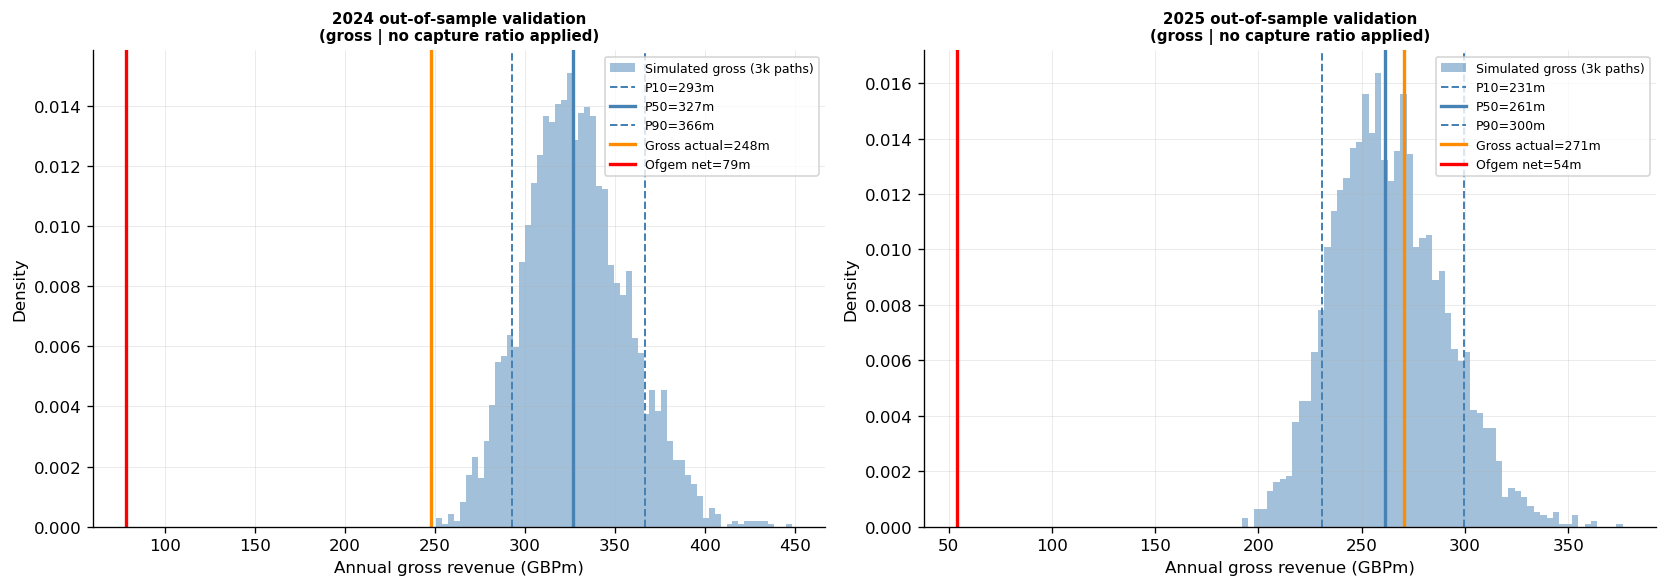

Saved: figS3_backtest.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, yr in zip(axes, [2024, 2025]):
    v = validation[yr]
    ax.hist(v['rev_dist'], bins=60, density=True, color='steelblue',
            alpha=0.5, label='Simulated gross (3k paths)')
    ax.axvline(v['p10'],  color='steelblue', lw=1.2, ls='--', label=f'P10={v["p10"]:.0f}m')
    ax.axvline(v['p50'],  color='steelblue', lw=2.0, label=f'P50={v["p50"]:.0f}m')
    ax.axvline(v['p90'],  color='steelblue', lw=1.2, ls='--', label=f'P90={v["p90"]:.0f}m')
    ax.axvline(v['gross_actual'], color='darkorange', lw=2.0, ls='-',
               label=f'Gross actual={v["gross_actual"]:.0f}m')
    ax.axvline(v['ofgem'], color='red', lw=2.0, ls='-',
               label=f'Ofgem net={v["ofgem"]:.0f}m')
    ax.set_title(f'{yr} out-of-sample validation\n'
                 f'(gross | no capture ratio applied)', fontsize=9, fontweight='bold')
    ax.set_xlabel('Annual gross revenue (GBPm)'); ax.set_ylabel('Density')
    ax.legend(fontsize=7.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figS3_backtest.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figS3_backtest.png')


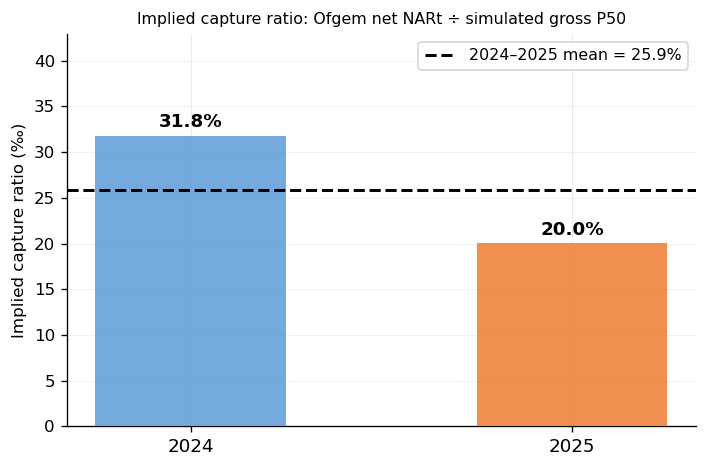

Saved: /Users/aadesh/Documents/IC/M2/fig_cr_backtest.png
  2024 CR=31.8%  2025 CR=20.0%  mean=25.9%


In [26]:
# ── Fig: Implied capture ratio by backtest year ───────────────────────────────
# Bar chart: Ofgem net NARt / simulated gross P50 for 2024 and 2025.
# Mean = 25.9% carried into the Monte Carlo as CAPTURE_RATIO.

_cr_years  = [2024, 2025]
_cr_vals   = [validation[y]['cr'] * 100 for y in _cr_years]
_cr_mean   = np.mean(_cr_vals)

fig_cr, ax_cr = plt.subplots(figsize=(6, 4))
bars = ax_cr.bar(_cr_years, _cr_vals, color=['#5b9bd5', '#ed7d31'],
                  width=0.5, alpha=0.85, zorder=3)
ax_cr.axhline(_cr_mean, color='black', lw=1.8, ls='--', zorder=4,
               label=f'2024\u20132025 mean = {_cr_mean:.1f}%')

for bar, val in zip(bars, _cr_vals):
    ax_cr.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
               f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax_cr.set_xticks(_cr_years)
ax_cr.set_xticklabels([str(y) for y in _cr_years], fontsize=11)
ax_cr.set_ylabel('Implied capture ratio (\u2030)', fontsize=10)
ax_cr.set_ylim(0, max(_cr_vals) * 1.35)
ax_cr.set_title('Implied capture ratio: Ofgem net NARt \u00f7 simulated gross P50', fontsize=9.5)
ax_cr.legend(fontsize=9.5)
ax_cr.grid(axis='y', alpha=0.35, zorder=0)
ax_cr.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
_cr_path = OUTPUT_DIR / 'fig_cr_backtest.png'
plt.savefig(_cr_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_cr_path}')
print(f'  2024 CR={_cr_vals[0]:.1f}%  2025 CR={_cr_vals[1]:.1f}%  mean={_cr_mean:.1f}%')

## Section 13: Monte Carlo Setup — Hourly f_S Projection

### Hourly f_S Projection

The OLS model decomposes as:

    f_S(t, h) = [base daily: b7 + tau + sin1 + cos1 + D_t] + b_h

where `b_h` is the hour deviation from the daily mean (sum-to-zero coding):
- H01–H23: estimated directly from OLS
- H24: derived as `−Σ(b_H01..b_H23)` from the sum-to-zero constraint

Pre-computed as a **(n_days × 24) array** — one row per simulation day, one column per hour.

### Capture Ratio — Now Calibrated on Hourly Theoretical Revenue

With the hourly approach, the **theoretical revenue** is:

    theoretical = Σ_h |actual_hourly_spread_h| × 1000MW × 1h × availability / 1e6

This is higher than the daily-average approach (`|mean_daily_spread| × 24h`) because E[|S_h|] > |E[S_h]| within a day. The capture ratio is correspondingly lower, but represents **only genuine market costs** (auction, TSO, balancing) — no longer conflated with temporal aggregation effects.


In [27]:
proj_dates = pd.date_range(
    start=f'{PROJ_START_YEAR}-01-01',
    end=f'{PROJ_START_YEAR + N_PROJ_YEARS - 1}-12-31',
    freq='D'
)
proj_years = proj_dates.year.values

# Build hourly seasonal/within-day shape with tau=0
# Annex M (Section 14) will supply the annual level — tau must not appear here
proj_hourly_idx = pd.DatetimeIndex([
    d + pd.Timedelta(hours=h) for d in proj_dates for h in range(24)
])
feat_proj = build_features_spread_hourly(proj_hourly_idx, t0_spread)
feat_proj['tau'] = 0.0   # zero out trend column

f_s_flat    = (feat_proj[params_s.index] @ params_s.values)
f_s_shape_h = f_s_flat.values.reshape(len(proj_dates), 24).copy()

# Demean year-by-year so Annex M is the sole source of the annual level
for yr in range(PROJ_START_YEAR, PROJ_START_YEAR + N_PROJ_YEARS):
    mask = proj_years == yr
    f_s_shape_h[mask] -= f_s_shape_h[mask].mean()

peak_trough = f_s_shape_h.mean(axis=0).max() - f_s_shape_h.mean(axis=0).min()
print(f'Seasonal shape (tau=0, demeaned): n_days={len(proj_dates)}, 24 hours')
print(f'  Annual mean (should be ~0):   {f_s_shape_h.mean():.4f} GBP/MWh')
print(f'  Within-day peak-to-trough:    {peak_trough:.2f} GBP/MWh')
print(f'  Annual level: provided by Annex M in Section 14')
print()
print(f'Capture ratio (back-test 2024-2025): {capture_ratio:.4f} ({capture_ratio*100:.1f}%)')


Seasonal shape (tau=0, demeaned): n_days=7305, 24 hours
  Annual mean (should be ~0):   0.0000 GBP/MWh
  Within-day peak-to-trough:    28.28 GBP/MWh
  Annual level: provided by Annex M in Section 14

Capture ratio (back-test 2024-2025): 0.2591 (25.9%)


## Section 14: Price Trajectory — Annex M Vintage Validation + Three-Scenario Simulation

### 14a. Prior Vintage Validation (Oct 2022 Annex M vs Actuals 2022–2025)

Before applying the Feb 2026 Annex M to the projection, we test whether the Oct 2022
vintage would have contained the 2022–2025 actuals. This tells us how much to trust
the Low–High scenario band going forward.

### 14b. Price Trajectory Adjustment (Feb 2026 Annex M)

Three GB electricity price scenarios applied to the projection:

| Scenario | Description | GB 2028 (£/MWh) | GB 2040 (£/MWh) |
|---|---|---|---|
| **Reference** | Central | ~61 | ~79 |
| **FFP_Low** | Lower fossil fuel prices | ~47 | ~67 |
| **FFP_High** | Higher fossil fuel prices | ~81 | ~91 |

**FR price path:** SP Global European Power Prices (France column, nominal EUR/MWh).
2026–2030 values from the forecast; 2031–2045 extended at +1%/yr from the 2030 value.
Converted to 2016/17-RPI-real GBP/MWh using the 2024–25 panel average FX rate and FPA RPI path.

**Each scenario produces a separate `spread_level_adj` array** — the MC simulation
runs independently for all three, using the same random seed for comparability.
The stochastic P10–P90 band within each scenario reflects OU+jump uncertainty;
the spread between scenario P50s reflects fossil fuel price uncertainty.

In [28]:
ANNEX_M_OLD  = Path('/Users/aadesh/Downloads/Annex_M_assumptions_growth_price_EEP2021_2040.ods')
ANNEX_M_PATH = Path('/Users/aadesh/Downloads/Annex_M_assumptions_growth_price.ods')

def _parse_annex_m(sheet_df, price_type='baseload'):
    '''Extract electricity price series (p/kWh real 2024) from an Annex M ODS sheet.
    Returns a pd.Series keyed by year. Multiplies by 10 to convert p/kWh → GBP/MWh.'''
    search  = 'baseload' if price_type == 'baseload' else 'volume weighted'
    hdr_row = next(
        (ri for ri in range(min(10, len(sheet_df)))
         if str(sheet_df.iloc[ri, 0]).strip().lower() == 'metric'),
        None
    )
    if hdr_row is None:
        return None
    hdr      = sheet_df.iloc[hdr_row, :]
    year_cols, fuel_col = {}, 2
    for ci, val in enumerate(hdr):
        s = str(val).strip().lower()
        if s == 'fuel':
            fuel_col = ci
        try:
            yr = int(float(val))
            if 2001 <= yr <= 2055:
                year_cols[yr] = ci
        except (ValueError, TypeError):
            pass
    for ri in range(len(sheet_df)):
        if search in str(sheet_df.iloc[ri, fuel_col]).lower():
            return pd.Series({yr: float(sheet_df.iloc[ri, ci])
                              for yr, ci in year_cols.items()})
    return None


### 14.1 Prior Vintage Validation — Oct 2022 Annex M vs 2022–2025 Actuals

Before applying the Feb 2026 Annex M to the projection, we test whether the Oct 2022 vintage would have contained the 2022–2025 actuals. This validates the scenario band width and tells us how much to trust the Low–High range going forward.

In [29]:
_old_sheets = pd.read_excel(ANNEX_M_OLD, sheet_name=None, engine='odf', header=None)

_old_ref = _parse_annex_m(_old_sheets['Reference'],     'baseload') * 10
_old_low = _parse_annex_m(_old_sheets['FFP_Low'],       'baseload') * 10
_old_hgh = _parse_annex_m(_old_sheets['FFP_High'],      'baseload') * 10
_old_exh = _parse_annex_m(_old_sheets['FFP_Exten_High'],'baseload') * 10

# Observed GB prices deflated from nominal to 2016/17-RPI-real for like-for-like comparison
_gb_actual_nom = {2022: 241.30, 2023: 107.89, 2024: 85.88, 2025: 94.34}
_gb_actual = {
    yr: p * _RPI_1617 / _HIST_RPI.get(yr, _HIST_RPI_MAX)
    for yr, p in _gb_actual_nom.items()
}

# Rebase Oct 2022 Annex M scenario bands from 2022-real to 2016/17-real
for _s in [_old_ref, _old_low, _old_hgh, _old_exh]:
    for yr in list(_s.index):
        _s[yr] = _s[yr] * _gdp_cum_2022(yr) * _RPI_1617 / _HIST_RPI.get(yr, _HIST_RPI_MAX)

print('=== Prior Vintage: Oct 2022 Annex M vs Panel-Observed GB Prices ===')
print(f'  {"Year":>4}  {"Ref":>8}  {"Low":>8}  {"High":>9}  {"ExtHigh":>9}  '
      f'{"Actual":>8}  {"Ref Err%":>9}  Contained?')
print('  ' + '-' * 82)
for yr in [2022, 2023, 2024, 2025]:
    r, l, h, e = (_old_ref.get(yr, float('nan')), _old_low.get(yr, float('nan')),
                  _old_hgh.get(yr, float('nan')), _old_exh.get(yr, float('nan')))
    a   = _gb_actual[yr]
    err = (r - a) / a * 100
    tag = 'YES (Low-High)' if l <= a <= h else ('YES (Low-ExtHigh)' if l <= a <= e else 'NO')
    print(f'  {yr:>4}  {r:>8.1f}  {l:>8.1f}  {h:>9.1f}  {e:>9.1f}  '
          f'{a:>8.1f}  {err:>+9.1f}%  {tag}')
print()
print('  ✓ All four actuals fell within the Low–High (or Low–ExtHigh) band.')
print('  ✓ Low–High band is a credible confidence interval for GB price path.')
print('  ⚠ Reference projects faster normalisation than materialised.')


=== Prior Vintage: Oct 2022 Annex M vs Panel-Observed GB Prices ===
  Year       Ref       Low       High    ExtHigh    Actual   Ref Err%  Contained?
  ----------------------------------------------------------------------------------
  2022     139.7      79.4      296.7      296.6     199.3      -29.9%  YES (Low-High)
  2023      90.5      52.5      198.4      200.5      86.3       +4.8%  YES (Low-High)
  2024      67.7      48.8      105.4      106.5      66.5       +1.8%  YES (Low-High)
  2025      60.0      46.1       84.8       99.4      70.8      -15.2%  YES (Low-High)

  ✓ All four actuals fell within the Low–High (or Low–ExtHigh) band.
  ✓ Low–High band is a credible confidence interval for GB price path.
  ⚠ Reference projects faster normalisation than materialised.


### 14.2 Feb 2026 Annex M — GB Calibration + FR Price Path (SP Global)

Three GB price scenarios from the Feb 2026 DESNZ Energy and Emissions Projections:

| Scenario | Narrative |
|---|---|
| **Reference** | Central |
| **FFP_Low** | Lower fossil fuel prices |
| **FFP_High** | Higher fossil fuel prices |

**GB calibration:** Annex M reports GB *baseload* wholesale prices (p/kWh real 2024). Our panel data reflects the N2EX day-ahead market including within-day price variation. We scale all Annex M scenarios by `gb_scale = panel_mean(2024-25) / annex_m_mean(2024-25)`.

**FR price path — S\&P Global European Power Prices:** France column (nominal EUR/MWh). Directional accuracy versus panel actuals confirmed for 2023–2025. SP Global covers 2026–2030; beyond 2030, values are extended at +1%/yr from the 2030 level, reflecting an assumption that increasing French electricity demand (projected +35% by 2050) exerts upward pressure on wholesale prices. Prices are converted to 2016/17-RPI-real GBP/MWh using the 2024–25 panel average FX rate and the FPA RPI path.

A single FR curve is used across all three GB scenarios — spread variation between scenarios comes entirely from the GB side.

In [30]:
_am_sheets = pd.read_excel(ANNEX_M_PATH, sheet_name=None, engine='odf', header=None)

gb_ref = _parse_annex_m(_am_sheets['Reference'], 'baseload') * 10
gb_low = _parse_annex_m(_am_sheets['FFP_Low'],   'baseload') * 10
gb_hgh = _parse_annex_m(_am_sheets['FFP_High'],  'baseload') * 10

gb_anchor         = panel.loc['2024':'2025', 'gb_price_gbp'].mean()
fr_anchor         = panel.loc['2024':'2025', 'fr_price_gbp'].mean()
spread_anchor_lvl = gb_anchor - fr_anchor

PANEL_ACTUALS_GB = {2023: 107.89, 2024: 85.88, 2025: 94.34}

print(f'Panel 2024-2025:  GB={gb_anchor:.2f}  FR={fr_anchor:.2f}  spread={spread_anchor_lvl:.2f} GBP/MWh')
print()


# FPA model Input sheet row 97: 12-month average UK RPI index (CHAW, Jan 1987=100)
# Defined here so _fr_real_1617 and ADJ_FACTORS both have access.
FPA_RPI = {
    2009: 215.767, 2010: 226.475, 2011: 237.342, 2012: 244.675,
    2013: 251.733, 2014: 256.667, 2015: 259.433, 2016: 264.992,
    2017: 273.578, 2018: 282.442, 2019: 291.593, 2020: 301.040,
    2021: 310.794, 2022: 320.864, 2023: 331.260, 2024: 341.993,
    2025: 353.073, 2026: 364.513, 2027: 376.323, 2028: 388.516,
    2029: 401.104, 2030: 414.099, 2031: 427.516, 2032: 441.368,
    2033: 455.668, 2034: 470.432, 2035: 485.674, 2036: 501.410,
    2037: 517.655, 2038: 534.427, 2039: 551.743, 2040: 569.619,
    2041: 588.075, 2042: 607.129, 2043: 626.799, 2044: 647.108,
    2045: 668.074, 2046: 689.720, 2047: 712.067, 2048: 735.138,
}
# FR wholesale price path -- SP Global European Power Prices (France column, nominal EUR/MWh)
# Source: sp_chart1_european_power_prices.csv

_SP_CSV = '/Users/aadesh/Documents/IC/sp_chart1_european_power_prices.csv'
_sp_raw = {}
with open(_SP_CSV) as _f:
    for row in _csv.DictReader(_f):
        yr_str = row['Year'].replace('F', '').strip()
        try:
            _sp_raw[int(yr_str)] = float(row['France'])
        except (ValueError, KeyError):
            pass

# FX rate: 2024-2025 panel average (GBP per EUR)
fx_eur_gbp_fwd = panel.loc['2024':'2025', 'fx_eur_gbp'].mean()

# Validate SP Global 2023-2025 forecasts vs panel actuals (EUR/MWh)
# Panel FR price in EUR: fr_price_gbp / fx_eur_gbp  (GBP / (GBP/EUR) = EUR)
fr_eur_hist = (panel['fr_price_gbp'] / panel['fx_eur_gbp']).resample('YE').mean()
print('SP Global validation vs panel actuals (nominal EUR/MWh, annual mean):')
print(f'  {"Year":>6}  {"SP Forecast":>12}  {"Panel Actual":>13}  {"Direction OK":>13}')
print('  ' + '-' * 52)
for yr in [2023, 2024, 2025]:
    sp_val = _sp_raw.get(yr)
    mask = fr_eur_hist.index.year == yr
    if sp_val is None or not mask.any():
        print(f'  {yr:>6}  {"n/a":>12}  {"n/a":>13}')
        continue
    panel_val = float(fr_eur_hist[mask].iloc[0])
    prev_yr = yr - 1
    sp_prev = _sp_raw.get(prev_yr, sp_val)
    pmask_prev = fr_eur_hist.index.year == prev_yr
    panel_prev = float(fr_eur_hist[pmask_prev].iloc[0]) if pmask_prev.any() else panel_val
    sp_dir = 'down' if sp_val < sp_prev else 'up'
    panel_dir = 'down' if panel_val < panel_prev else 'up'
    ok = 'YES' if sp_dir == panel_dir else 'NO'
    print(f'  {yr:>6}  {sp_val:>12.1f}  {panel_val:>13.2f}  {ok:>13}')
print()

# Build projection: 2026-2030 from SP Global; 2031-2045 extend at +1%/yr from 2030
_sp_ext = {}
for yr in range(2026, 2046):
    if yr <= 2030:
        _sp_ext[yr] = _sp_raw[yr]
    else:
        _sp_ext[yr] = _sp_raw[2030] * (1.01 ** (yr - 2030))

def _fr_real_1617(yr):
    'FR: SP Global EUR/MWh -> 2016/17-RPI-real GBP/MWh, deflated via RPI_2022 (SP Global publication base)'
    real_eur  = _sp_ext.get(yr, _sp_ext[2045])
    rpi_pub   = FPA_RPI[2022]  # SP Global CSV: 2023+ labelled as forecast, so 2022 is the publication base year
    return real_eur * fx_eur_gbp_fwd * (_RPI_1617 / rpi_pub)

print('FR price path (SP Global 2026-2030 as 2022-real EUR, +1%/yr 2031-2045):')
print(f'  {"Year":>6}  {"Nom EUR":>9}  {"Nom GBP":>9}  {"Real 1617 GBP":>14}')
print('  ' + '-' * 46)
for yr in [2026, 2028, 2030, 2032, 2035, 2040, 2045]:
    nom_eur  = _sp_ext.get(yr, _sp_ext[2045])
    nom_gbp  = nom_eur * fx_eur_gbp_fwd
    real_gbp = _fr_real_1617(yr)
    print(f'  {yr:>6}  {nom_eur:>9.1f}  {nom_gbp:>9.2f}  {real_gbp:>14.2f}')
print(f'  FX (2024-25 panel avg): {fx_eur_gbp_fwd:.4f} GBP/EUR')
print(f'  Basis: 2022-real EUR -> 2016/17-RPI-real GBP via RPI_1617/RPI_2022 = {_RPI_1617/FPA_RPI[2022]:.4f}')
print(f'  FR anchor (2024-2025 panel): {fr_anchor:.2f} GBP/MWh')
print()


# -- Price basis adjustment: Annex M 2024-GDP-real -> 2016/17-RPI-real (GB only) --
#
# Two-step conversion per projection year t:
#   Step 1: multiply by GDP_cum_t = prod(1+g_y, y=2025..t)  [undo GDP deflation -> nominal]
#   Step 2: multiply by RPI_1617/RPI_t                       [deflate nominal -> 2016/17-real]
# Combined: adj_t = GDP_cum_t x RPI_1617 / RPI_t
# FR uses its own nominal->real path via FPA_RPI directly; no GDP_cum step.

# GDP deflator -- actual year-by-year rates from Annex M Reference sheet row 6 (to 2050)
_am_ref_raw = _am_sheets['Reference']
_am_yr_row  = _am_ref_raw.iloc[2, :]
_am_gdp_row = _am_ref_raw.iloc[6, :]
GDP_DEFL = {}
for _c in range(len(_am_gdp_row)):
    _y, _v = _am_yr_row.iloc[_c], _am_gdp_row.iloc[_c]
    try:
        if not (np.isnan(float(_y)) or np.isnan(float(_v))):
            GDP_DEFL[int(_y)] = float(_v)
    except (TypeError, ValueError):
        pass

def _gdp_cum(t):
    'Cumulative GDP deflator from 2024 to t: product(1+g_y) for y=2025..t.'
    if t <= 2024:
        return 1.0
    acc = 1.0
    for yr in range(2025, t + 1):
        acc *= (1.0 + GDP_DEFL.get(yr, 0.023))
    return acc

def annex_m_adj(t):
    'Adjustment: Annex M 2024-GDP-real -> 2016/17-RPI-real. adj = GDP_cum_t x RPI_1617 / RPI_t'
    rpi_t = FPA_RPI.get(t, FPA_RPI[max(FPA_RPI)])
    return _gdp_cum(t) * _RPI_1617 / rpi_t

# Pre-compute lookup table for all projection years
ADJ_FACTORS = {yr: annex_m_adj(yr) for yr in range(2020, 2051)}

# Scale factor: panel-observed GB price (2016/17-real) vs Annex M prediction (2016/17-real).
# Both sides on same basis: divide gb_ref (2024-GDP-real) by ADJ_FACTORS to convert.
scale_ratios = {yr: PANEL_ACTUALS_GB[yr] / gb_ref[yr]
                for yr in PANEL_ACTUALS_GB if yr in gb_ref}
gb_scale = np.mean(list(scale_ratios.values()))

print('GB scale factor -- panel actual / Annex M Reference (both 2016/17-real):')
print(f'  {"Year":>6}  {"Annex M 1617-real":>18}  {"Panel 1617-real":>16}  {"Ratio":>8}')
print('  ' + '-' * 56)
for yr, ratio in scale_ratios.items():
    ref_adj = gb_ref[yr] * ADJ_FACTORS.get(yr, annex_m_adj(yr))
    print(f'  {yr:>6}  {ref_adj:>18.2f}  {PANEL_ACTUALS_GB[yr]:>16.2f}  {ratio:>8.4f}')
print(f'  {"Mean":>6}  {"":>18}  {"":>16}  {gb_scale:>8.4f}  <- applied to all projections')
print()

print('Price basis adjustment (2024-GDP-real -> 2016/17-RPI-real):')
print('  Formula: adj_t = GDP_cum_t x RPI_1617 / RPI_t  (GB only)')
print(f'  RPI_1617 base = {_RPI_1617:.3f}')
print()
print(f'  {"Year":>6}  {"GDP_cum":>8}  {"RPI_t":>8}  {"Y_t":>8}  {"adj":>8}  '
      f'{"GB_ref orig":>12}  {"GB_ref adj":>11}')
print('  ' + '-' * 72)
for _yr in [2024, 2026, 2028, 2030, 2032, 2035, 2038, 2040, 2045]:
    if _yr in gb_ref:
        _f   = ADJ_FACTORS[_yr]
        _gdp = _gdp_cum(_yr)
        _rpi = FPA_RPI.get(_yr, FPA_RPI[max(FPA_RPI)])
        _yt  = (_rpi / FPA_RPI[2024]) / _gdp
        print(f'  {_yr:>6}  {_gdp:>8.4f}  {_rpi:>8.2f}  {_yt:>8.4f}  {_f:>8.4f}  '
              f'{gb_ref[_yr]:>12.2f}  {gb_ref[_yr]*_f:>11.2f}')

Panel 2024-2025:  GB=68.67  FR=38.48  spread=30.19 GBP/MWh

SP Global validation vs panel actuals (nominal EUR/MWh, annual mean):
    Year   SP Forecast   Panel Actual   Direction OK
  ----------------------------------------------------
    2023         133.9          77.48            YES
    2024         123.5          44.75            YES
    2025          92.6          45.89             NO

FR price path (SP Global 2026-2030 as 2022-real EUR, +1%/yr 2031-2045):
    Year    Nom EUR    Nom GBP   Real 1617 GBP
  ----------------------------------------------
    2026       64.8      55.19           45.58
    2028       51.3      43.69           36.08
    2030       34.9      29.72           24.55
    2032       35.6      30.32           25.04
    2035       36.7      31.24           25.80
    2040       38.6      32.83           27.12
    2045       40.5      34.51           28.50
  FX (2024-25 panel avg): 0.8517 GBP/EUR
  Basis: 2022-real EUR -> 2016/17-RPI-real GBP via RPI_1617/RPI_

### 14.3 Annex M Spread Level

$$S_{\text{Annex}}(t) = \bigl(P^{GB}_{\text{proj}}(t) \times \text{gb\_scale} - P^{FR}_{\text{proj}}(t)\bigr) \times \text{adj}_t$$

$\text{adj}_t = \text{GDP\_cum}_t \times \text{RPI}_{16/17} / \text{RPI}_t$ — Annex M 2024-GDP-real → 2016/17-RPI-real.

$$S_{d,h} = S_{\text{Annex}}(\text{year}_d) + \text{shape}(d,h) + X_d + Y_d$$

In [31]:
rows = []
for yr in range(PROJ_START_YEAR, PROJ_START_YEAR + N_PROJ_YEARS):
    adj_f   = ADJ_FACTORS.get(yr, annex_m_adj(yr))
    gb_real = gb_ref.get(yr, gb_ref[max(gb_ref.index)]) * gb_scale * adj_f
    fr_real = _fr_real_1617(yr)
    rows.append({'year': yr,
                 'gb_proj':     gb_real,
                 'fr_proj':     fr_real,
                 'spread_proj': gb_real - fr_real})
adj_df = pd.DataFrame(rows).set_index('year')

print(f'  {"Year":>6}  {"GB_proj":>9}  {"FR_proj (SP)":>13}  {"Spread":>9}  {"adj":>8}')
print('  ' + '-' * 55)
for yr in [2026, 2030, 2035, 2040, 2045]:
    r = adj_df.loc[yr]
    print(f'  {yr:>6}  {r["gb_proj"]:>9.2f}  {r["fr_proj"]:>13.2f}  '
          f'{r["spread_proj"]:>9.2f}  {ADJ_FACTORS.get(yr, annex_m_adj(yr)):>8.4f}')

def _build_daily_spread(gb_series, proj_dates, gb_scale):
    'GB: Annex M 2024-GDP-real x gb_scale x ADJ_FACTORS -> 2016/17-RPI-real minus FR real 1617.'
    spread = {yr: (gb_series.get(yr, gb_series[max(gb_series.index)]) * gb_scale
                   * ADJ_FACTORS.get(yr, annex_m_adj(yr)))
                  - _fr_real_1617(yr)
              for yr in range(proj_dates.year.min(), proj_dates.year.max() + 1)}
    return np.array([spread[d.year] for d in proj_dates])

spread_level_scenarios = {
    'Reference': _build_daily_spread(gb_ref, proj_dates, gb_scale),
    'FFP_Low':   _build_daily_spread(gb_low, proj_dates, gb_scale),
    'FFP_High':  _build_daily_spread(gb_hgh, proj_dates, gb_scale),
}

print()
print('Annex M spread level by scenario (2016/17 RPI-real GBP/MWh):')
print(f'  {"Scenario":<12}  {"2026":>8}  {"2030":>8}  {"2035":>8}  {"2040":>8}  {"2045":>8}')
print('  ' + '-' * 55)
for sname, sarr in spread_level_scenarios.items():
    slices = [sarr[:365], sarr[365*4:365*5], sarr[365*9:365*10],
              sarr[365*14:365*15], sarr[365*19:]]
    vals = '  '.join(f'{s.mean():>8.1f}' for s in slices)
    print(f'  {sname:<12}  {vals}')

    Year    GB_proj   FR_proj (SP)     Spread       adj
  -------------------------------------------------------
    2026      64.22          45.58      18.64    0.7626
    2030      47.89          24.55      23.34    0.7254
    2035      48.98          25.80      23.18    0.6916
    2040      57.09          27.12      29.97    0.6606
    2045      67.14          28.50      38.64    0.6311

Annex M spread level by scenario (2016/17 RPI-real GBP/MWh):
  Scenario          2026      2030      2035      2040      2045
  -------------------------------------------------------
  Reference         18.6      23.3      23.2      30.0      38.6
  FFP_Low            3.6      12.4      13.3      21.5      29.6
  FFP_High          43.4      36.3      33.6      38.4      46.8


### 14.4 Price Trajectory Chart

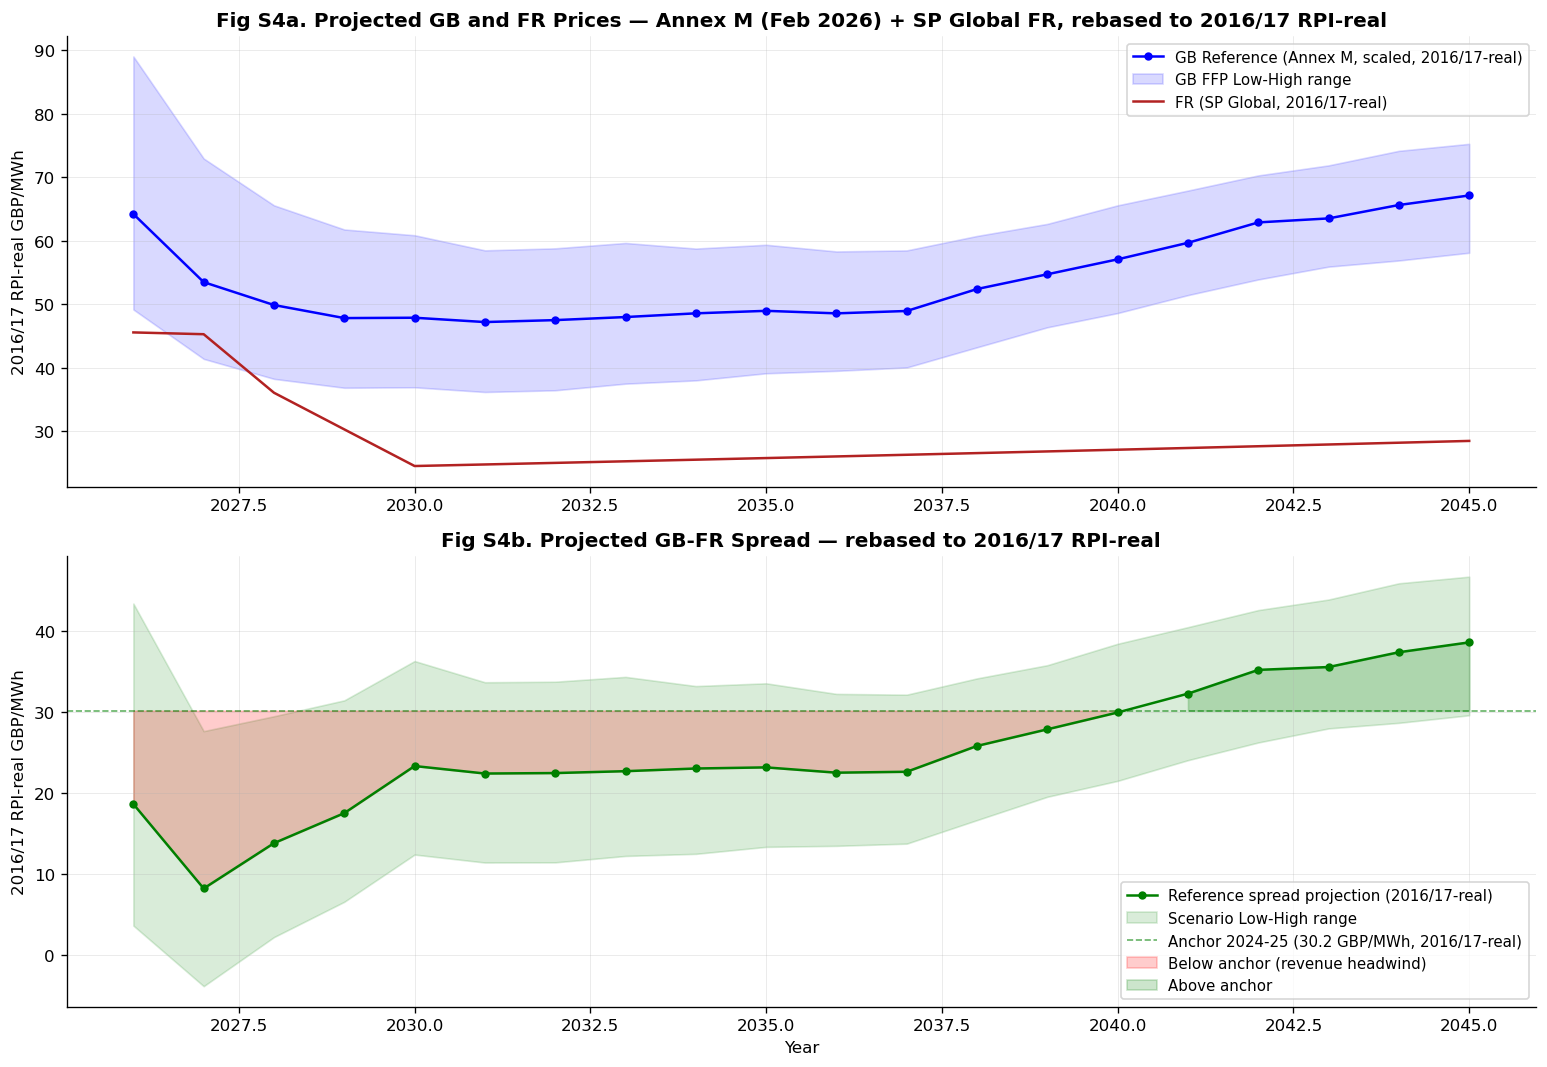

Saved: figS4_price_trajectory.png
Note: GB from Annex M (2024-GDP-real); FR from SP Global (nominal EUR -> 2016/17-RPI-real via FPA RPI path).


In [32]:
yrs = adj_df.index.tolist()
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

ax = axes[0]
ax.plot(yrs, adj_df['gb_proj'], 'b-o', ms=4, label='GB Reference (Annex M, scaled, 2016/17-real)')
ax.fill_between(yrs,
    [gb_low.get(y, gb_low[max(gb_low.index)]) * gb_scale * ADJ_FACTORS.get(y, annex_m_adj(y)) for y in yrs],
    [gb_hgh.get(y, gb_hgh[max(gb_hgh.index)]) * gb_scale * ADJ_FACTORS.get(y, annex_m_adj(y)) for y in yrs],
    alpha=0.15, color='blue', label='GB FFP Low-High range')
ax.plot(yrs, [_fr_real_1617(y) for y in yrs],
        color='firebrick', lw=1.5, ls='-', label='FR (SP Global, 2016/17-real)')
ax.set_ylabel('2016/17 RPI-real GBP/MWh')
ax.set_title('Fig S4a. Projected GB and FR Prices — Annex M (Feb 2026) + SP Global FR, rebased to 2016/17 RPI-real',
             fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(yrs, adj_df['spread_proj'], 'g-o', ms=4, label='Reference spread projection (2016/17-real)')
ax.fill_between(yrs,
    [(gb_low.get(y, gb_low[max(gb_low.index)]) * gb_scale * ADJ_FACTORS.get(y, annex_m_adj(y)))
     - _fr_real_1617(y) for y in yrs],
    [(gb_hgh.get(y, gb_hgh[max(gb_hgh.index)]) * gb_scale * ADJ_FACTORS.get(y, annex_m_adj(y)))
     - _fr_real_1617(y) for y in yrs],
    alpha=0.15, color='green', label='Scenario Low-High range')
spread_anchor_adj = spread_anchor_lvl  # already 2016/17-real; no further deflation
ax.axhline(spread_anchor_adj, color='g', ls='--', lw=1, alpha=0.6,
           label=f'Anchor 2024-25 ({spread_anchor_adj:.1f} GBP/MWh, 2016/17-real)')
ax.fill_between(yrs, spread_anchor_adj, adj_df['spread_proj'],
                where=(adj_df['spread_proj'] < spread_anchor_adj).values,
                alpha=0.2, color='red', label='Below anchor (revenue headwind)')
ax.fill_between(yrs, spread_anchor_adj, adj_df['spread_proj'],
                where=(adj_df['spread_proj'] >= spread_anchor_adj).values,
                alpha=0.2, color='green', label='Above anchor')
ax.set_ylabel('2016/17 RPI-real GBP/MWh'); ax.set_xlabel('Year')
ax.set_title('Fig S4b. Projected GB-FR Spread — rebased to 2016/17 RPI-real',
             fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figS4_price_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figS4_price_trajectory.png')
print('Note: GB from Annex M (2024-GDP-real); FR from SP Global (nominal EUR -> 2016/17-RPI-real via FPA RPI path).')

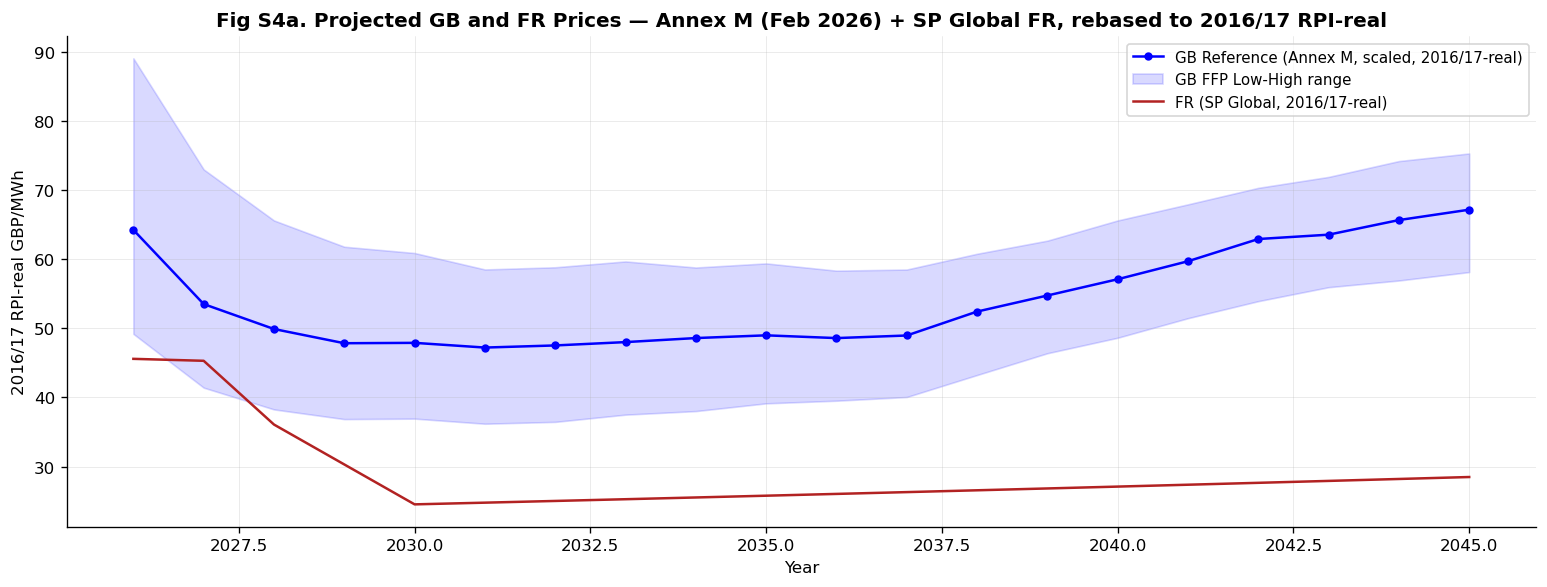

Saved: figS4a_prices.png


In [33]:
# ── Fig S4a: GB and FR projected prices (top panel of figS4, standalone) ──────

fig_s4a, ax_s4a = plt.subplots(figsize=(13, 5))

ax_s4a.plot(yrs, adj_df['gb_proj'], 'b-o', ms=4,
            label='GB Reference (Annex M, scaled, 2016/17-real)')
ax_s4a.fill_between(
    yrs,
    [gb_low.get(y, gb_low[max(gb_low.keys())]) * gb_scale * ADJ_FACTORS.get(y, annex_m_adj(y)) for y in yrs],
    [gb_hgh.get(y, gb_hgh[max(gb_hgh.keys())]) * gb_scale * ADJ_FACTORS.get(y, annex_m_adj(y)) for y in yrs],
    alpha=0.15, color='blue', label='GB FFP Low-High range')
ax_s4a.plot(yrs, [_fr_real_1617(y) for y in yrs],
            color='firebrick', lw=1.5, ls='-',
            label='FR (SP Global, 2016/17-real)')
ax_s4a.set_ylabel('2016/17 RPI-real GBP/MWh')
ax_s4a.set_xlabel('Year')
ax_s4a.set_title('Fig S4a. Projected GB and FR Prices — Annex M (Feb 2026) + SP Global FR, rebased to 2016/17 RPI-real',
                 fontweight='bold')
ax_s4a.legend(fontsize=9)

plt.tight_layout()
fig_s4a.savefig(OUTPUT_DIR / 'figS4a_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figS4a_prices.png')


## Section 15: Monte Carlo Simulation

10,000 paths × 20 projection years. For each day $d$:

1. **Evolve $X_t + Y_t$:** $X_d = c + \phi X_{d-1} + \sigma_d\,\varepsilon_d + \text{signed jump arrivals}$

2. **24 hourly spreads:**
$$S_{d,h} = S_{\text{Annex}}(\text{year}_d) + \text{shape}(d,h) + X_d$$

3. **Daily revenue:**
$$R_d = \sum_{h=1}^{24} |S_{d,h}| \times 1000\,\text{MW} \times A \times \rho \;/\; 10^6$$

In [34]:
BATCH  = 500
n_days = len(proj_dates)
phi    = ou_s['phi'];   c_ou = ou_s['c'];  sigma_d = ou_s['sigma_d']
jp_pos = jump_params_s['pos'];  jp_neg = jump_params_s['neg']

# Same RNG seed per scenario → differences between scenarios are purely from
# the deterministic level shift, not from random variation.
scenario_results = {}

for scen_name, spread_level in spread_level_scenarios.items():
    print(f'--- Scenario: {scen_name} ({N_PATHS:,} paths x {N_PROJ_YEARS} yrs) ---')
    rng = np.random.default_rng(RANDOM_SEED)
    annual_rev_s = np.zeros((N_PATHS, N_PROJ_YEARS))

    for b0 in range(0, N_PATHS, BATCH):
        b1 = min(b0 + BATCH, N_PATHS);  n = b1 - b0
        X  = np.zeros(n)
        batch_rev = np.zeros((N_PROJ_YEARS, n))

        for d in range(n_days):
            X = c_ou + phi * X + sigma_d * rng.standard_normal(n)
            q = proj_dates[d].quarter
            for jp, sign in [(jp_pos, +1.0), (jp_neg, -1.0)]:
                lam = jp['lam_by_q'][q]
                if lam > 0 and jp['beta'] > 0:
                    X += sign * (rng.random(n) < lam) * rng.exponential(jp['beta'], n)

            S_h = f_s_shape_h[d, :] + spread_level[d] + X[:, np.newaxis]
            rev_d = np.abs(S_h).sum(axis=1) * CAPACITY_MW * AVAILABILITY / 1e6 * capture_ratio

            yr_idx = proj_years[d] - PROJ_START_YEAR
            if 0 <= yr_idx < N_PROJ_YEARS:
                batch_rev[yr_idx] += rev_d
        annual_rev_s[b0:b1] = batch_rev.T

    p10_s = np.percentile(annual_rev_s, 10, axis=0)
    p50_s = np.percentile(annual_rev_s, 50, axis=0)
    p90_s = np.percentile(annual_rev_s, 90, axis=0)
    scenario_results[scen_name] = {'p10': p10_s, 'p50': p50_s, 'p90': p90_s,
                                   'rev': annual_rev_s}
    print(f'  Yr1 P10={p10_s[0]:.1f}  P50={p50_s[0]:.1f}  P90={p90_s[0]:.1f}  |  '
          f'Yr10 P50={p50_s[9]:.1f}  |  Yr20 P50={p50_s[19]:.1f}')

# Reference scenario as default (for CSV / Excel export)
p10 = scenario_results['Reference']['p10']
p50 = scenario_results['Reference']['p50']
p90 = scenario_results['Reference']['p90']
annual_rev = scenario_results['Reference']['rev']
print('\nAll scenarios complete. Reference carried forward for CSV/Excel outputs.')


--- Scenario: Reference (10,000 paths x 20 yrs) ---


  Yr1 P10=54.8  P50=61.6  P90=69.9  |  Yr10 P50=67.5  |  Yr20 P50=92.8
--- Scenario: FFP_Low (10,000 paths x 20 yrs) ---


  Yr1 P10=44.8  P50=50.8  P90=58.4  |  Yr10 P50=56.4  |  Yr20 P50=77.0
--- Scenario: FFP_High (10,000 paths x 20 yrs) ---


  Yr1 P10=93.3  P50=102.0  P90=111.4  |  Yr10 P50=83.7  |  Yr20 P50=108.4

All scenarios complete. Reference carried forward for CSV/Excel outputs.


## Section 16: Results — Revenue Tables and Charts

**P10/P50/P90 convention:** P10 = 10th percentile (downside); P90 = 90th percentile (upside).

### Revenue profile

Revenues are time-varying, driven directly by the Annex M GB price path and the
RTE/ENTSO-E FR price path (Section 14). The annual spread level
$S_{\text{Annex}}(t)$ = GB_proj − FR_proj moves year-by-year across all three
scenarios. The seasonal shape (Section 13) adds within-day and within-year
variation. The OU process (Section 11) provides the stochastic P10–P90 band width.


In [35]:
proj_cal_years = [PROJ_START_YEAR + i for i in range(N_PROJ_YEARS)]
show = sorted(set([0, 4] + list(range(4, N_PROJ_YEARS, 5)) + [N_PROJ_YEARS - 1]))

rev_df = pd.DataFrame({
    'cal_year':  proj_cal_years,
    'regime_yr': range(PROJ_START_YEAR - REGIME_START + 1,
                       PROJ_START_YEAR - REGIME_START + N_PROJ_YEARS + 1),
    'p10_gbpm':  p10.round(2), 'p50_gbpm': p50.round(2), 'p90_gbpm': p90.round(2),
})
rev_df.to_csv(OUTPUT_DIR / 'mc_revenue_ifa2.csv', index=False)
print('Saved: mc_revenue_ifa2.csv')

print()
print('  === IFA2 Revenue — Full Regime 2021-2045 (Reference scenario) ===')
print(f'  {"Yr":>3}  {"Cal":>6}  {"P10 (GBPm)":>12}  {"P50 (GBPm)":>12}  {"P90 (GBPm)":>12}  Note')
print('  ' + '-' * 70)
for yr in range(REGIME_START, PROJ_START_YEAR):
    regime_yr = yr - REGIME_START + 1
    if yr in ACTUALS:
        print(f'  {regime_yr:>3}  {yr:>6}  {"—":>12}  {ACTUALS[yr]:>12.1f}  {"—":>12}  actual (Ofgem)')
    else:
        print(f'  {regime_yr:>3}  {yr:>6}  {"—":>12}  {"n/a":>12}  {"—":>12}  not disclosed')
print('  ' + '·' * 70)
for i in show:
    regime_yr = (PROJ_START_YEAR + i) - REGIME_START + 1
    print(f'  {regime_yr:>3}  {PROJ_START_YEAR + i:>6}  '
          f'{p10[i]:>12.1f}  {p50[i]:>12.1f}  {p90[i]:>12.1f}  projected')

print()
print('  === P50 Revenue by Scenario (GBPm) ===')
scen_names = list(scenario_results.keys())
print(f'  {"Yr":>3}  {"Cal":>6}' + ''.join(f'  {s:>12}' for s in scen_names))
print('  ' + '-' * (14 + 14 * len(scen_names)))
for i in show:
    row = f'  {(PROJ_START_YEAR+i)-REGIME_START+1:>3}  {PROJ_START_YEAR+i:>6}'
    for s in scen_names:
        row += f'  {scenario_results[s]["p50"][i]:>12.1f}'
    print(row)


Saved: mc_revenue_ifa2.csv

  === IFA2 Revenue — Full Regime 2021-2045 (Reference scenario) ===
   Yr     Cal    P10 (GBPm)    P50 (GBPm)    P90 (GBPm)  Note
  ----------------------------------------------------------------------
    1    2021             —           n/a             —  not disclosed
    2    2022             —          69.6             —  actual (Ofgem)
    3    2023             —         100.8             —  actual (Ofgem)
    4    2024             —         101.6             —  actual (Ofgem)
    5    2025             —          72.2             —  actual (Ofgem)
  ······································································
    6    2026          54.8          61.6          69.9  projected
   10    2030          60.5          67.8          76.4  projected
   15    2035          60.1          67.5          76.1  projected
   20    2040          70.0          77.9          87.1  projected
   25    2045          84.4          92.8         102.3  projected

 

### 16.1 Revenue Fan Charts — Three Annex M Scenarios

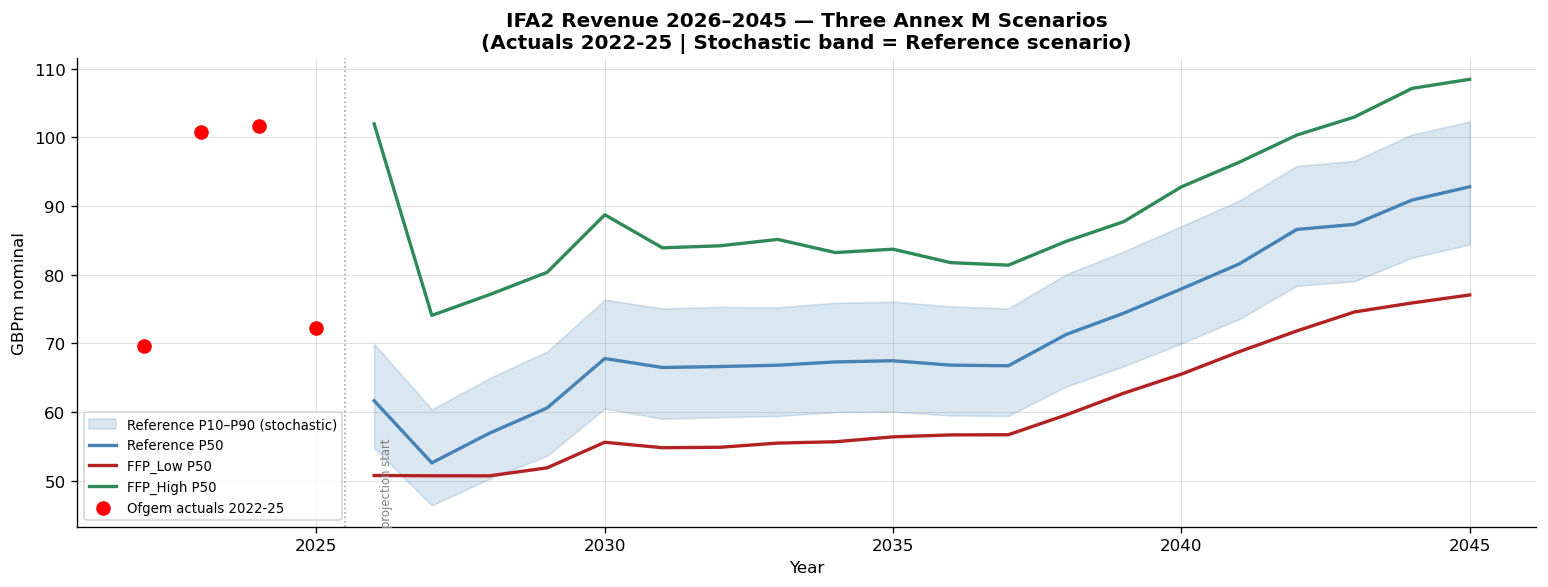

Saved: fig_revenue_scenarios.png


In [36]:
# ── Chart 1: Reference stochastic band + all three P50 lines ───────────────
SCEN_COLORS = {'Reference': 'steelblue', 'FFP_Low': 'firebrick', 'FFP_High': 'seagreen'}

fig, ax = plt.subplots(1, 1, figsize=(13, 5))
ax.fill_between(proj_cal_years, p10, p90, alpha=0.20, color='steelblue',
                label='Reference P10–P90 (stochastic)')
for s, sr in scenario_results.items():
    ax.plot(proj_cal_years, sr['p50'], lw=2.0, color=SCEN_COLORS[s],
            label=f'{s} P50', zorder=3)
for yr, val in ACTUALS.items():
    ax.scatter([yr], [val], color='red', zorder=5, s=60)
ax.scatter([], [], color='red', s=60, label='Ofgem actuals 2022-25')
ax.axvline(PROJ_START_YEAR - 0.5, color='grey', lw=1, ls=':', alpha=0.7)
ax.text(PROJ_START_YEAR + 0.1, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 20,
        'projection start', fontsize=7, color='grey', rotation=90, va='bottom')
ax.set_title('IFA2 Revenue 2026–2045 — Three Annex M Scenarios\n'
             '(Actuals 2022-25 | Stochastic band = Reference scenario)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('GBPm nominal'); ax.legend(fontsize=8)
ax.grid(True, linewidth=0.3, alpha=0.5, color='grey')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_revenue_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_revenue_scenarios.png')

## Section 17: Export to Ofgem Cap & Floor Model

Revenue series written to the Ofgem Excel template (IFA2 FPA). Three copies — P10, P50, P90. Values go to `Input` sheet, row 25, columns V–AT (columns 22–46 = regime years 1–25 = calendar years **2021–2045**).

| Regime years | Calendar years | Source |
|---|---|---|
| 1 (2021) | 2021 | Blank — Ofgem not yet disclosed |
| 2–5 (2022–2025) | 2022–2025 | Hard-coded Ofgem actuals |
| 6–25 (2026–2045) | 2026–2045 | Model P10 / P50 / P90 |

> **Note:** Verify cap/floor floor and cap parameters against the actual Ofgem Window 1 IFA2 decision document. Confirm whether floor/cap are expressed in real or nominal terms before interpreting breach probabilities.

In [37]:
import shutil

# PCR decision file — write assessed revenues into Costs & Revenue sheet
# Col 16 = Op year 1 (2021), col 17 = 2022, ..., col 40 = 2045
CFFM2_TEMPLATE  = Path('/Users/aadesh/Documents/IC/iFA2CFFM2_PCR_decision.xlsm')
CR_SHEET        = 'Costs & Revenue'
CR_ROW          = 29     # ARt — assessed revenue
COL_YEAR_2021   = 16     # column 16 = operational year 1 = calendar 2021
REGIME_START    = 2021

TOTAL_REGIME = PROJ_START_YEAR - REGIME_START + N_PROJ_YEARS  # 25 years

# RPIt from CFFM2 Indexation sheet converts 2016/17-real -> nominal.
# MC revenues are 2016/17-real; ARt in CFFM2 expects nominal.
_wb_tpl = openpyxl.load_workbook(CFFM2_TEMPLATE, data_only=True, keep_vba=True)
_ws_i   = _wb_tpl['Indexation']
CFFM2_RPIt = {int(round(_ws_i.cell(row=5,  column=c).value)) + 2020:
              float(_ws_i.cell(row=11, column=c).value)
              for c in range(1, 46)
              if isinstance(_ws_i.cell(row=5,  column=c).value, (int, float))
              and isinstance(_ws_i.cell(row=11, column=c).value, (int, float))}
_wb_tpl.close()
print('RPIt spot-check:', {y: round(CFFM2_RPIt[y], 4)
      for y in [2026, 2030, 2035, 2040, 2045] if y in CFFM2_RPIt})
_CFFM2_RPIt_MAX = CFFM2_RPIt[max(CFFM2_RPIt)]  # highest-year RPI fallback
assert 2021 in CFFM2_RPIt and 2045 in CFFM2_RPIt, (
    f'CFFM2_RPIt keys look wrong (expected 2021-2045): '
    f'{list(CFFM2_RPIt.keys())[:5]} '
    '— check row 5 of CFFM2 Indexation sheet')

for pct_label, proj_values in [('p10', p10), ('p50', p50), ('p90', p90)]:
    full_25 = []
    for yr in range(REGIME_START, REGIME_START + TOTAL_REGIME):
        if yr < PROJ_START_YEAR:
            full_25.append(ACTUALS.get(yr, None))   # nominal actuals — correct as-is
        else:
            idx  = yr - PROJ_START_YEAR
            rpit = CFFM2_RPIt.get(yr, _CFFM2_RPIt_MAX)
            full_25.append(round(float(proj_values[idx]) * rpit, 2))  # real->nominal

    out_path = OUTPUT_DIR / f'ifa2_pcr_{pct_label}.xlsm'
    shutil.copy2(CFFM2_TEMPLATE, out_path)
    wb_out = openpyxl.load_workbook(out_path, keep_vba=True)
    ws_cr  = wb_out[CR_SHEET]
    for i, val in enumerate(full_25):
        if val is not None:
            ws_cr.cell(row=CR_ROW, column=COL_YEAR_2021 + i, value=val)
    wb_out.save(out_path)
    wb_out.close()

    actuals_filled = [yr for yr in range(REGIME_START, PROJ_START_YEAR) if yr in ACTUALS]
    print(f'Written: {out_path.name}')
    print(f'  Actuals:   {min(actuals_filled)}–{max(actuals_filled)} ({len(actuals_filled)} years)')
    print(f'  Projected: {PROJ_START_YEAR}–{PROJ_START_YEAR+N_PROJ_YEARS-1} ({N_PROJ_YEARS} years)')
    print(f'  Yr1 ({PROJ_START_YEAR}): £{proj_values[0]:.1f}m  |  '
          f'Yr{N_PROJ_YEARS} ({PROJ_START_YEAR+N_PROJ_YEARS-1}): £{proj_values[-1]:.1f}m')
    print()

print('Open ifa2_pcr_*.xlsm in Excel — Assessment sheet recalculates cap/floor breach.')


RPIt spot-check: {2026: 1.3772, 2030: 1.5645, 2035: 1.8349, 2040: 2.1521, 2045: 2.5241}


Written: ifa2_pcr_p10.xlsm
  Actuals:   2022–2025 (4 years)
  Projected: 2026–2045 (20 years)
  Yr1 (2026): £54.8m  |  Yr20 (2045): £84.4m



Written: ifa2_pcr_p50.xlsm
  Actuals:   2022–2025 (4 years)
  Projected: 2026–2045 (20 years)
  Yr1 (2026): £61.6m  |  Yr20 (2045): £92.8m



Written: ifa2_pcr_p90.xlsm
  Actuals:   2022–2025 (4 years)
  Projected: 2026–2045 (20 years)
  Yr1 (2026): £69.9m  |  Yr20 (2045): £102.3m

Open ifa2_pcr_*.xlsm in Excel — Assessment sheet recalculates cap/floor breach.


## Section 18: Accounts Analysis — Cap/Floor Validation Against Actual Financials

Up to this point every assumption in the model — the capture ratio, the cap allowance level, the equity return benchmark — has been derived from Ofgem disclosures and the regulatory framework. Here we cross-check all of those against IFA2's actual audited financial statements (2022–2025). This does two things: it validates whether the cap mechanism is working as the model assumes, and it gives an empirically grounded view of what the equity investor actually received year by year.

The analysis proceeds in four steps:

1. **Accounts waterfall** — compare Turnover (accounts-recognised revenue) against Ofgem-disclosed NARt (gross regulatory revenue). The gap is the implied cap settlement returned to consumers.
2. **Equity return on invested capital** — net profit as a percentage of share capital, compared to the 8.1% cap return rate.
3. **RAV reconstruction** — extract the capex profile from the Ofgem Cap & Floor Excel to compute the opening RAV and derive the theoretical annual cap allowance.
4. **Open questions** — why net profits appear above 8.1% x RAV, and what changes under Window 3.

> **To re-run with updated statements:** change the four file paths in the configuration cell below, then re-execute Section 18. All calculations update automatically.

In [38]:
# == Section 18.1: Configuration — update paths here to re-run ==
ACCOUNTS_PATHS = {
    2022: Path('/Users/aadesh/Downloads/IFA2 - 2022.xlsx'),
    2023: Path('/Users/aadesh/Downloads/IFA2 - 2023.xlsx'),
    2024: Path('/Users/aadesh/Downloads/IFA2 - 2024 Statements.xlsx'),
    2025: Path('/Users/aadesh/Downloads/IFA2-2025 Statements.xlsx'),
}
OFGEM_MODEL_PATH = OUTPUT_DIR / 'ifa2_pcr_p50.xlsm'

# Source: Ofgem Annual Compliance Assessment reports

# Regulatory parameters (Window 1 — update for Window 3 when available)
CAP_RATE_REAL  = 0.081      # cap return rate (real, annual)
TAX_RATE       = 0.25       # corporation tax rate
RPI_1617 = _RPI_1617  # FPA row 96: 2016/17 CHAW base (was 264.0 — incorrect rounding)
RPI_NOMINAL    = {2022: 365, 2023: 388, 2024: 395, 2025: 405}  # approximate annual RPI

def load_sheet(path, sheet):
    wb = openpyxl.load_workbook(path, data_only=True)
    return [r for r in wb[sheet].iter_rows(values_only=True)
            if any(v is not None for v in r)]

def find_value(rows, keyword, col=1, exact=False):
    # Return numeric value in 'col' of first row whose col-0 matches keyword
    for row in rows:
        if row[0] is None:
            continue
        label = str(row[0]).strip().lower()
        match = (label == keyword.lower()) if exact else (keyword.lower() in label)
        if match:
            v = row[col]
            return float(v) if v is not None else None
    return None

accts = {}
for year, path in ACCOUNTS_PATHS.items():
    pl = load_sheet(path, 'Profit & Loss')
    bs = load_sheet(path, 'Balance Sheet')
    def _fv(rows, label, **kw): return (find_value(rows, label, **kw) or 0.0) / 1e3
    a = {
        'turnover':   _fv(pl, 'Turnover'),
        'admin':      abs(_fv(pl, 'Administrative expenses')),
        'op_profit':  _fv(pl, 'Operating profit'),
        'int_recv':   _fv(pl, 'Interest receivable'),
        'int_pay':    abs(_fv(pl, 'Interest payable')),
        'pbt':        _fv(pl, 'Profit before tax'),
        'tax':        abs(_fv(pl, 'Tax', exact=True)),
        'net_profit': _fv(pl, 'Profit for the year'),
        'ppe':        _fv(bs, 'Property, plant'),
        'share_cap':  _fv(bs, 'Share capital'),
        'provisions': abs(_fv(bs, 'Provisions')),
        'debtors_st': _fv(bs, 'Debtors (amounts falling due within'),
    }
    a['net_interest']   = a['int_recv'] - a['int_pay']
    a['roe']            = a['net_profit'] / a['share_cap']
    accts[year] = a

years = sorted(accts)
print("Accounts loaded:")
for y in years:
    a = accts[y]
    print(f"  {y}: Turnover GBP{a['turnover']:.1f}m | "
          f"Net profit GBP{a['net_profit']:.1f}m | RoE {a['roe']*100:.1f}%")


Accounts loaded:
  2022: Turnover GBP69.6m | Net profit GBP37.0m | RoE 10.2%
  2023: Turnover GBP100.8m | Net profit GBP60.8m | RoE 16.7%
  2024: Turnover GBP101.6m | Net profit GBP62.0m | RoE 17.0%
  2025: Turnover GBP72.2m | Net profit GBP28.4m | RoE 7.8%


### 18.2 Revenue Waterfall — NARt to Equity Profit

**Turnover** (what the accounts recognise as revenue) is consistently below **NARt** (what the market paid). The gap is the annual cap settlement returned to consumers via the ICFap mechanism.

In 2022–2023 — high-spread years — the operator returned £65–88m annually. In 2024, revenues happened to land just above the cap, so only £6m was returned. In 2025 a larger settlement (£37m) coincides with a sharp jump in admin costs, consistent with a 5-year period-end reckoning.

The equity return on invested capital (net profit divided by share capital of £364m) has ranged from 7.8% to 17%, averaging ~13%. The variation tracks how far NARt fell above or below the cap allowance in each year.

In [39]:
# == Section 18.2: Waterfall Table =========================================
W = 42 + 9 * len(years)
hdr = f"{'':42s}" + "".join(f"{y:>9}" for y in years)

def rw(label, vals, pct=False, negate=False):
    if negate: vals = [-v for v in vals]
    if pct:
        return f"  {label:40s}" + "".join(f"{v*100:>8.1f}%" for v in vals)
    return f"  {label:40s}" + "".join(f"{v:>9.1f}" for v in vals)

print("=" * W)
print("IFA2 REVENUE WATERFALL  (GBPm nominal)")
print("=" * W)
print(hdr)
print("-" * W)
print(rw("Turnover  (post-cap, accounts)",          [accts[y]['turnover']     for y in years]))
print(rw("  Admin expenses",                        [accts[y]['admin']        for y in years], negate=True))
print(rw("Operating profit",                        [accts[y]['op_profit']    for y in years]))
print(rw("  Net interest income",                   [accts[y]['net_interest'] for y in years]))
print(rw("Profit before tax",                       [accts[y]['pbt']         for y in years]))
print(rw("  Tax",                                   [accts[y]['tax']         for y in years], negate=True))
print(rw("Net profit — equity FCF proxy",           [accts[y]['net_profit']  for y in years]))
print("-" * W)
print("\nKEY RATIOS")
print("-" * W)
print(rw("Net profit margin on Turnover",
         [accts[y]['net_profit']/accts[y]['turnover'] for y in years], pct=True))
print(rw("Return on equity  (profit / share capital)",
         [accts[y]['roe']                             for y in years], pct=True))
print("\nBALANCE SHEET")
print("-" * W)
print(rw("PP&E / RAV proxy",           [accts[y]['ppe']        for y in years]))
print(rw("Provisions for liabilities", [accts[y]['provisions'] for y in years]))
print(rw("Short-term debtors",         [accts[y]['debtors_st'] for y in years]))
print(rw("Share capital (equity)",     [accts[y]['share_cap']  for y in years]))


IFA2 REVENUE WATERFALL  (GBPm nominal)
                                               2022     2023     2024     2025
------------------------------------------------------------------------------
  Turnover  (post-cap, accounts)               69.6    100.8    101.6     72.2
    Admin expenses                            -24.5    -25.6    -31.8    -44.2
  Operating profit                             45.2     75.2     69.7     28.0
    Net interest income                        -0.5      1.5     13.9     11.2
  Profit before tax                            44.6     76.7     83.6     39.3
    Tax                                        -7.6    -15.9    -21.6    -10.9
  Net profit — equity FCF proxy                37.0     60.8     62.0     28.4
------------------------------------------------------------------------------

KEY RATIOS
------------------------------------------------------------------------------
  Net profit margin on Turnover               53.2%    60.3%    61.1%    39.3%
 

### 18.3 Full Revenue Waterfall — Theoretical to Equity

The table below traces every pound from the maximum theoretically achievable revenue (if the 1 GW cable ran at full capacity every hour) down to equity net profit, for each complete calendar year 2022–2025.

**Four sequential deductions:**
1. **Utilisation** — IFA2 does not flow at full 1,000 MW every hour. The Tobit estimates ~74% of rated capacity was active; the remaining 26% is structural censoring (spreads too narrow to cover costs, or market auction losses).
2. **Net retention** — even when flowing, the operator keeps only ~43% of the physical congestion rent. The rest goes to other costs like TSO balancing charges, auction clearing costs, and counterparty fees.
3. **Cap settlement** — in years when NARt exceeds the Ofgem cap allowance, the excess is returned to consumers via the ICFap mechanism (clawback).
4. **Operating costs** — admin, depreciation, and tax convert Turnover into the equity return.


In [40]:
#
# Joins ENTSO-E hourly physical flow data with the price panel to compute each
# step of the waterfall. Years 2022-2025 are complete calendar years.

# Theoretical hourly revenue: full 1 GW rated capacity × |spread| × availability
panel['_theor_h'] = CAPACITY_MW * panel['spread_gbp'].abs() * AVAILABILITY / 1e6
theor_by_yr = panel.groupby(panel.index.year)['_theor_h'].sum()

# Flow-based gross: earn when flowing in the profitable direction (directional formula)
# Join panel spread onto full flow_df (all years available in ENTSO-E data)
_wf = (flow_df[['gb_to_fr', 'fr_to_gb']]
       .join(panel[['spread_gbp']], how='inner')
       .dropna(subset=['spread_gbp']))
_wf[['gb_to_fr', 'fr_to_gb']] = _wf[['gb_to_fr', 'fr_to_gb']].fillna(0.0)
_wf['_flow_rev_h'] = (
    _wf['fr_to_gb'] * _wf['spread_gbp'].clip(lower=0) +
    _wf['gb_to_fr'] * (-_wf['spread_gbp']).clip(lower=0)
) * AVAILABILITY / 1e6
flow_by_yr = _wf.groupby(_wf.index.year)['_flow_rev_h'].sum()

WF_YEARS = [2022, 2023, 2024, 2025]

def _fv(d, y): return d.get(y, float('nan'))
def _pct(a, b): return f'{a/b*100:>7.1f}%' if b and not (b != b) else '     n/a'

W3 = 44 + 9 * len(WF_YEARS)
hdr3 = f"{'':44s}" + "".join(f"{y:>9}" for y in WF_YEARS)

print("=" * W3)
print("IFA2 REVENUE WATERFALL  (GBPm nominal, complete calendar years)")
print("=" * W3)
print(hdr3)
print("-" * W3)

theor_v  = [_fv(theor_by_yr, y)                   for y in WF_YEARS]
flow_v   = [_fv(flow_by_yr, y)                     for y in WF_YEARS]
turn_v   = [accts[y]['turnover']                    for y in WF_YEARS]
admin_v  = [accts[y]['admin']                       for y in WF_YEARS]
np_v     = [accts[y]['net_profit']                  for y in WF_YEARS]

def row(label, vals, suffix=''):
    return f"  {label:<42s}" + "".join(f"{v:>9.1f}" for v in vals) + suffix

print(row("Theoretical  (1 GW × |spread| × avail)", theor_v))
print(f"  {'  ↓ utilisation':<42s}" + "".join(_pct(flow_v[i], theor_v[i]) for i in range(len(WF_YEARS))))
print(row("Flow-based gross  (ENTSO-E physical)", flow_v))
print(row("Turnover  (post-cap, accounts)", turn_v))
print(f"  {'  - admin & operating costs':<42s}" + "".join(f"{-v:>9.1f}" for v in admin_v))
print(row("Equity net profit  (FCF proxy)", np_v))
print("-" * W3)
print()
print("END-TO-END RATIOS  (each row as % of Theoretical)")
print("-" * W3)
print(hdr3)
print(f"  {'Flow-based / Theoretical  =  utilisation':<42s}" + "".join(_pct(flow_v[i], theor_v[i]) for i in range(len(WF_YEARS))))
print(f"  {'Turnover / Theoretical':<42s}" + "".join(_pct(turn_v[i], theor_v[i]) for i in range(len(WF_YEARS))))
print(f"  {'Net profit / Theoretical':<42s}" + "".join(_pct(np_v[i],  theor_v[i]) for i in range(len(WF_YEARS))))
print()
print("  Note: Theoretical uses full 1 GW rated capacity. IFA2 operates below rated")
print("  capacity during congestion events and low-spread periods, so utilisation < 100%.")


IFA2 REVENUE WATERFALL  (GBPm nominal, complete calendar years)
                                                 2022     2023     2024     2025
--------------------------------------------------------------------------------
  Theoretical  (1 GW × |spread| × avail)        342.0    164.9    247.6    270.6
    ↓ utilisation                              54.2%   53.2%   55.7%   77.0%
  Flow-based gross  (ENTSO-E physical)          185.4     87.7    137.9    208.3
  Turnover  (post-cap, accounts)                 69.6    100.8    101.6     72.2
    - admin & operating costs                   -24.5    -25.6    -31.8    -44.2
  Equity net profit  (FCF proxy)                 37.0     60.8     62.0     28.4
--------------------------------------------------------------------------------

END-TO-END RATIOS  (each row as % of Theoretical)
--------------------------------------------------------------------------------
                                                 2022     2023     2024     202

### 18.4 RAV Reconstruction — Deriving the Cap Allowance from First Principles

The Ofgem Cap & Floor Excel contains the pre-operational capex profile in Input row 17 (GBPm in 16/17 real prices). The cap return rate (Input row 42) is blank in this template — set at financial close and withheld — but capex, development costs, opex allowance, and availability are all readable.

From capex plus estimated IDC we reconstruct the opening RAV and derive:

```
Cap allowance (CLt) = opex + depreciation + 8.1% x RAV + tax_allowance
```

This is the maximum revenue the operator may retain from NARt. If NARt exceeds this over a 5-year assessment period (on an NPV basis), the excess is returned to consumers as ICFap.

**Key finding:** the opening RAV (~£362m) almost exactly matches the share capital (£364m), confirming the project is entirely equity-financed. The cap allowance including all cost-recovery components is approximately £65m in 16/17 real prices, equivalent to £89–99m nominal over 2022–2025 — consistent with the Turnover figures in the accounts.

In [41]:
try:
    # == Section 18.3: RAV Reconstruction =====================================
    wb_ofgem = openpyxl.load_workbook(OFGEM_MODEL_PATH, data_only=True, keep_vba=True)
    ws_in    = wb_ofgem['Inputs']
    
    capex_row = list(ws_in.iter_rows(min_row=17, max_row=17, values_only=True))[0]
    capex_vals = [v for v in capex_row if isinstance(v, (int, float)) and v > 0]
    
    dev_row   = list(ws_in.iter_rows(min_row=13, max_row=13, values_only=True))[0]
    dev_vals  = [v for v in dev_row if isinstance(v, (int, float)) and v > 0]
    
    total_capex_1617 = sum(capex_vals)
    total_dev_1617   = sum(dev_vals) * (RPI_1617 / 252.6)   # 13/14 -> 16/17
    
    IDC_RATE_REAL   = 0.05    # placeholder (actual rate is blank in template)
    AVG_CONST_YEARS = 2.5
    idc_est = total_capex_1617 * IDC_RATE_REAL * AVG_CONST_YEARS
    opening_rav = total_capex_1617 + total_dev_1617 + idc_est
    
    OPEX_1617    = 10.94778          # from Input row 33
    DEP_1617     = opening_rav / 25  # 25-year straight-line
    ret_1617     = CAP_RATE_REAL * opening_rav
    tax_1617     = ret_1617 * TAX_RATE / (1 - TAX_RATE)
    cap_all_1617 = OPEX_1617 + DEP_1617 + ret_1617 + tax_1617
    
    # NPV-neutral annuity (the '9.37%' figure)
    annuity_rate = CAP_RATE_REAL / (1 - (1 + CAP_RATE_REAL)**-25)
    
    print("=== RAV RECONSTRUCTION (GBPm, 16/17 real prices) ===")
    print(f"  Capex profile:      {[round(v,2) for v in capex_vals]}")
    print(f"  Total capex:        GBP{total_capex_1617:.2f}m")
    print(f"  Dev costs (conv):   GBP{total_dev_1617:.2f}m")
    print(f"  IDC estimate:       GBP{idc_est:.2f}m  ({IDC_RATE_REAL*100:.0f}% real, {AVG_CONST_YEARS}yr avg)")
    print(f"  Opening RAV:        GBP{opening_rav:.2f}m")
    print(f"  Share capital:      GBP364.00m  (from accounts — confirms equity-only financing)")
    
    print(f"\n=== CAP ALLOWANCE BREAKDOWN (GBPm, 16/17 real) ===")
    print(f"  Opex allowance:     GBP{OPEX_1617:.2f}m")
    print(f"  Depreciation:       GBP{DEP_1617:.2f}m  (RAV / 25yr)")
    print(f"  Return ({CAP_RATE_REAL*100:.1f}% x RAV): GBP{ret_1617:.2f}m")
    print(f"  Tax allowance:      GBP{tax_1617:.2f}m")
    print(f"  Total cap (CLt):    GBP{cap_all_1617:.2f}m")
    print(f"  NPV-neutral annuity ({CAP_RATE_REAL*100:.1f}%, 25yr): {annuity_rate*100:.2f}% of RAV")
    print(f"  Annual cash yield:  GBP{annuity_rate * opening_rav:.2f}m  (16/17 real, pre-tax)")
    
    print(f"\n=== NOMINAL CAP ALLOWANCE vs ACCOUNTS TURNOVER ===")
    print(f"  {'Year':>6} {'Cap allow (nom)':>16} {'Turnover':>12} {'Gap':>10}")
    for yr, rpi_nom in RPI_NOMINAL.items():
        factor  = rpi_nom / RPI_1617
        cap_nom = cap_all_1617 * factor
        tv      = accts[yr]['turnover']
        print(f"  {yr:>6} GBP{cap_nom:>12.1f}m GBP{tv:>8.1f}m  {tv - cap_nom:>+8.1f}")
    
except Exception as _e183:
    print(f'Section 18.3 skipped: {_e183}')


=== RAV RECONSTRUCTION (GBPm, 16/17 real prices) ===
  Capex profile:      []
  Total capex:        GBP0.00m
  Dev costs (conv):   GBP0.00m
  IDC estimate:       GBP0.00m  (5% real, 2.5yr avg)
  Opening RAV:        GBP0.00m
  Share capital:      GBP364.00m  (from accounts — confirms equity-only financing)

=== CAP ALLOWANCE BREAKDOWN (GBPm, 16/17 real) ===
  Opex allowance:     GBP10.95m
  Depreciation:       GBP0.00m  (RAV / 25yr)
  Return (8.1% x RAV): GBP0.00m
  Tax allowance:      GBP0.00m
  Total cap (CLt):    GBP10.95m
  NPV-neutral annuity (8.1%, 25yr): 9.45% of RAV
  Annual cash yield:  GBP0.00m  (16/17 real, pre-tax)

=== NOMINAL CAP ALLOWANCE vs ACCOUNTS TURNOVER ===
    Year  Cap allow (nom)     Turnover        Gap
    2022 GBP        15.1m GBP    69.6m     +54.5
    2023 GBP        16.0m GBP   100.8m     +84.7
    2024 GBP        16.3m GBP   101.6m     +85.3
    2025 GBP        16.7m GBP    72.2m     +55.5


## Section 19: PCR Decision Cap/Floor Breach Analysis

Reads Ofgem's Window-1 PCR decision cap/floor schedule directly from
`iFA2CFFM2_PCR_decision.xlsm` (Revenue Adjustment sheet, rows 11–12).
No VBA or Excel required — values are stored as statics in the PCR decision model.
CFFM2 covers the full 25-year regime (cal 2021–2045); no extrapolation needed.

> **Data caveat:** CFFM2 shows non-monotonic cap/floor in 2041 (drop from 2040) and
> 2045 (sharp ~22% drop from 2044). These are formula outputs from the PCR decision
> model and likely reflect RPI/RAV reset assumptions at period boundaries rather than
> data errors. Treat 2040–2045 values as indicative.

**Sections:**
- **19.1** Load cap/floor schedule from CFFM2 Revenue Adjustment
- **19.2** Map CFFM2 operational years → calendar years
- **19.3** Annual breach probabilities (Reference scenario, 10,000 paths)
- **19.4** Fan chart with PCR cap/floor bands + breach probability bars
- **19.5** 5-year NPV assessment periods

In [42]:
# == Section 19.1–19.3: Load PCR Cap/Floor, Map Years, Breach Table ==
CFFM2_PATH = Path('/Users/aadesh/Documents/IC/iFA2CFFM2_PCR_decision.xlsm')
ODR = 0.03945   # real operational discount rate (CFFM2 Assessment row 13)

# ── 19.1: Revenue Adjustment — row 5 = op yr, row 11 = CLt, row 12 = FLt ──
wb2   = openpyxl.load_workbook(CFFM2_PATH, data_only=True, keep_vba=True)
ws_ra = wb2['Revenue Adjustment']

yr_raw  = [ws_ra.cell(row=5,  column=c).value for c in range(1, 46)]
cap_raw = [ws_ra.cell(row=11, column=c).value for c in range(1, 46)]
flo_raw = [ws_ra.cell(row=12, column=c).value for c in range(1, 46)]

# Column-aligned: yr_raw[i], cap_raw[i], flo_raw[i] all share column (i+1)
raw_sched = {}
for col_i, op_yr in enumerate(yr_raw):
    if not isinstance(op_yr, (int, float)) or isinstance(op_yr, bool):
        continue
    if op_yr < 1:
        continue   # skip yr0 (partial pre-operational period)
    cap_v = cap_raw[col_i]
    flo_v = flo_raw[col_i]
    if isinstance(cap_v, (int, float)) and cap_v > 0:
        raw_sched[int(round(op_yr))] = {
            'cap':   float(cap_v),
            'floor': float(flo_v) if isinstance(flo_v, (int, float)) else 0.0,
        }

# ── 19.2: Map CFFM2 op yr N → calendar year (2020+N) ──────────────────────
full_sched = {2020 + k: v for k, v in raw_sched.items()}

# ── Load RPIt from CFFM2 Indexation (row 11) ─────────────────────────────
# CLt/FLt in Revenue Adjustment are nominal (2016/17-real × RPIt).
# Deflate to 2016/17-real for apples-to-apples comparison with MC revenues.
ws_idx2 = wb2['Indexation']
CFFM2_RPIt = {int(round(ws_idx2.cell(row=5, column=c).value)) + 2020:
              float(ws_idx2.cell(row=11, column=c).value)
              for c in range(1, 46)
              if isinstance(ws_idx2.cell(row=5,  column=c).value, (int, float))
              and isinstance(ws_idx2.cell(row=11, column=c).value, (int, float))}
_CFFM2_RPIt_MAX = CFFM2_RPIt[max(CFFM2_RPIt)]  # recompute after Cell 70 reload
assert 2021 in CFFM2_RPIt and 2045 in CFFM2_RPIt, (
    f'CFFM2_RPIt keys look wrong (expected 2021-2045): '
    f'{list(CFFM2_RPIt.keys())[:5]} '
    '— check row 5 of CFFM2 Indexation sheet')
cal_yrs_loaded = sorted(full_sched)
print(f'CFFM2: {len(full_sched)} years loaded'
      f'  (cal {cal_yrs_loaded[0]}\u2013{cal_yrs_loaded[-1]}) \u2014 full regime covered')

# Flag non-monotonic years for transparency
_caps = [full_sched[y]['cap'] for y in cal_yrs_loaded]
_drops = [cal_yrs_loaded[i] for i in range(1, len(_caps)) if _caps[i] < _caps[i-1]]
if _drops:
    print(f'  Note: cap drops below prior year in: {_drops}'
          f'  (likely period-boundary RAV/RPI resets in CFFM2 \u2014 treat as indicative)')

# ── 19.3: Annual breach probabilities from MC paths (Reference, 10k paths) ─
rpit_proj = np.array([CFFM2_RPIt.get(yr, _CFFM2_RPIt_MAX)
                      for yr in proj_cal_years])
cap_arr   = np.array([full_sched[yr]['cap']   for yr in proj_cal_years]) / rpit_proj
floor_arr = np.array([full_sched[yr]['floor'] for yr in proj_cal_years]) / rpit_proj

# MC revenues and cap/floor now both in 2016/17-real
prob_cap   = (annual_rev > cap_arr[np.newaxis, :]).mean(axis=0)
prob_floor = (annual_rev < floor_arr[np.newaxis, :]).mean(axis=0)

print()
hdr = (f'  {"Year":>5}  {"Ryr":>3}  {"Cap real":>10}  {"Flr real":>10}  '
       "  P10      P50      P90    P>Cap    P<Flr")
sep = '  ' + '-' * (len(hdr) - 2)
print(sep); print(hdr); print(sep)
for i, yr in enumerate(proj_cal_years):
    # Flag years where cap is non-monotonic
    prev_cap = full_sched.get(yr - 1, {}).get('cap', cap_arr[i])
    tag = '*' if cap_arr[i] < prev_cap else ' '
    print(f'  {yr:>5}{tag}  {6+i:>3}  {cap_arr[i]:>10.1f}  {floor_arr[i]:>10.1f}  '
          f'{p10[i]:>7.1f}  {p50[i]:>7.1f}  {p90[i]:>7.1f}  '
          f'{prob_cap[i]*100:>6.1f}%  {prob_floor[i]*100:>6.1f}%')
print(sep)
print('  All values 2016/17-RPI-real (CLt/FLt deflated by CFFM2 Indexation RPIt).')
print('  * cap below prior year \u2014 period-boundary reset in CFFM2')


CFFM2: 25 years loaded  (cal 2021–2045) — full regime covered
  Note: cap drops below prior year in: [2022, 2041, 2045]  (likely period-boundary RAV/RPI resets in CFFM2 — treat as indicative)

  -----------------------------------------------------------------------------
   Year  Ryr    Cap real    Flr real    P10      P50      P90    P>Cap    P<Flr
  -----------------------------------------------------------------------------
   2026*    6        61.6        37.8     54.8     61.6     69.9    50.3%     0.0%
   2027*    7        61.6        37.8     46.4     52.6     60.4     7.4%     0.0%
   2028*    8        61.6        37.8     50.3     56.9     64.9    21.4%     0.0%
   2029*    9        61.6        37.8     53.6     60.6     68.8    43.1%     0.0%
   2030*   10        61.6        37.8     60.5     67.8     76.4    85.5%     0.0%
   2031*   11        61.6        37.8     59.0     66.5     75.1    78.9%     0.0%
   2032*   12        61.6        37.8     59.2     66.6     75.3    8

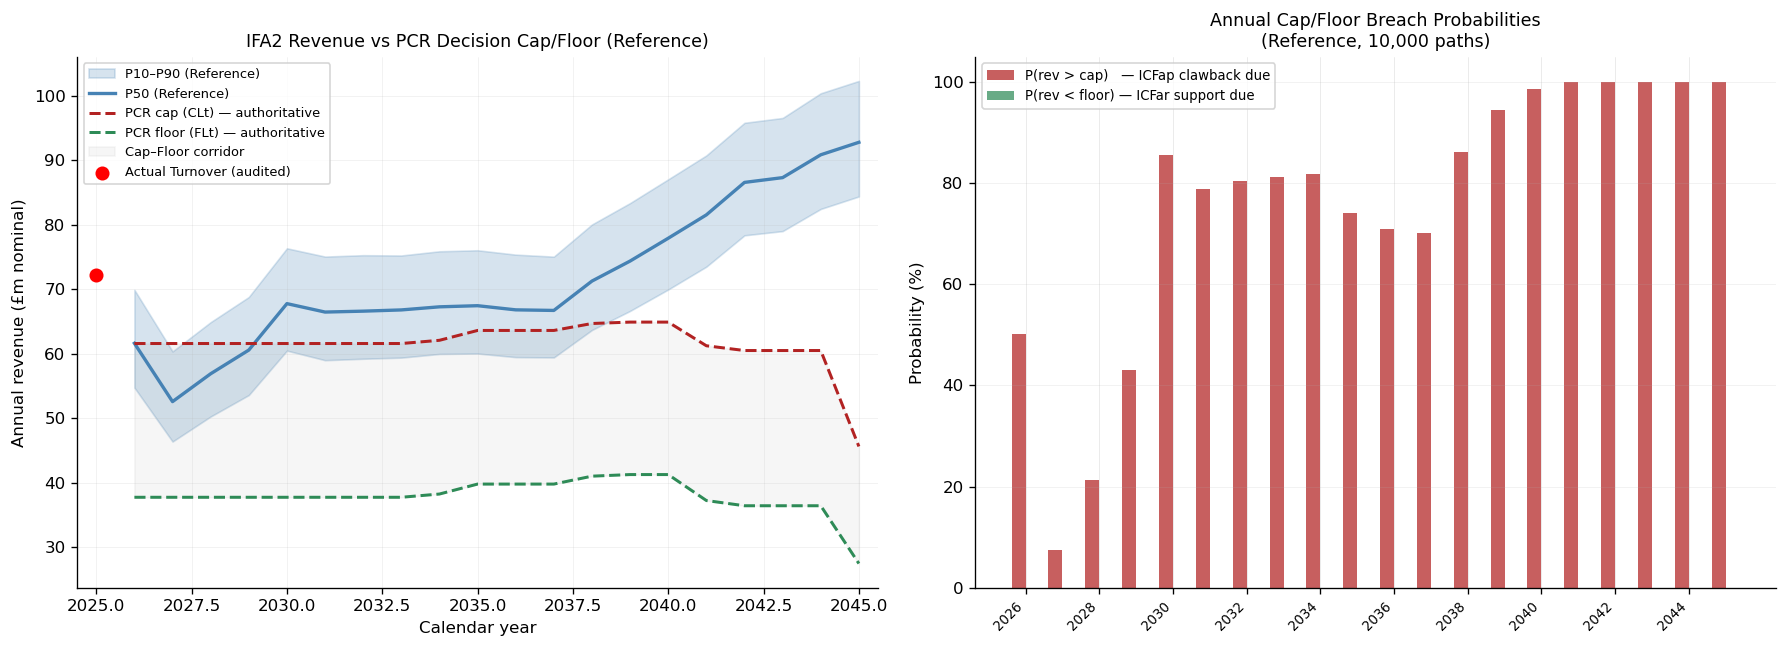

Saved: figS6_cap_floor_breach.png


In [43]:
# == Section 19.4: Fan Chart + Breach Probability Plot ===================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# ─ Panel 1: Revenue fan vs PCR cap/floor band ────────────────────────
ax1.fill_between(proj_cal_years, p10, p90, alpha=0.22, color='steelblue',
                 label='P10\u2013P90 (Reference)')
ax1.plot(proj_cal_years, p50,       lw=2.0, color='steelblue', label='P50 (Reference)')
ax1.plot(proj_cal_years, cap_arr,   lw=1.8, color='firebrick', ls='--',
         label='PCR cap (CLt) \u2014 authoritative')
ax1.plot(proj_cal_years, floor_arr, lw=1.8, color='seagreen',  ls='--',
         label='PCR floor (FLt) \u2014 authoritative')
ax1.fill_between(proj_cal_years, floor_arr, cap_arr,
                 alpha=0.07, color='grey', label='Cap\u2013Floor corridor')
for yr, val in ACTUALS.items():
    ax1.scatter([yr], [val], color='red', zorder=6, s=55)
ax1.scatter([], [], color='red', s=55, label='Actual Turnover (audited)')
ax1.set_xlim(2024.5, 2045.5)
ax1.set_title('IFA2 Revenue vs PCR Decision Cap/Floor (Reference)', fontsize=10.5)
ax1.set_xlabel('Calendar year')
ax1.set_ylabel('Annual revenue (£m nominal)')
ax1.legend(fontsize=7.8, loc='upper left')
ax1.grid(alpha=0.3)

# ─ Panel 2: Annual breach probability bars ───────────────────────────
x = np.arange(len(proj_cal_years))
w = 0.38
ax2.bar(x - w/2, prob_cap   * 100, width=w, color='firebrick', alpha=0.72,
        label='P(rev > cap)   \u2014 ICFap clawback due')
ax2.bar(x + w/2, prob_floor * 100, width=w, color='seagreen',  alpha=0.72,
        label='P(rev < floor) \u2014 ICFar support due')
ax2.set_xticks(x[::2])
ax2.set_xticklabels(proj_cal_years[::2], rotation=45, ha='right', fontsize=8)
ax2.set_title('Annual Cap/Floor Breach Probabilities\n(Reference, 10,000 paths)',
              fontsize=10.5)
ax2.set_ylabel('Probability (%)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
fig_path = OUTPUT_DIR / 'figS6_cap_floor_breach.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path.name}')


In [44]:
# == Section 19.5: 5-Year NPV Assessment Periods =========================
# Cap operates on 5-year NPV basis.  ICFap due if NPV(Turnover) > NPV(CLt).
# Period 1 (op yr 1-5 ≈ cal 2021-2025): actuals known.
# Periods 2-5 (2026-2045): P(NPV_revenue > NPV_cap) from MC paths.

# Build all-regime revenue matrix: actuals 2022-2025, MC 2026-2045
# 2021: Ofgem turnover not disclosed -> left as 0
all_reg_yrs = list(range(REGIME_START, REGIME_START + 25))  # 2021-2045
rpit_reg  = np.array([CFFM2_RPIt.get(yr, _CFFM2_RPIt_MAX)
                      for yr in all_reg_yrs])
rev_full  = np.zeros((N_PATHS, 25))
for i, yr in enumerate(all_reg_yrs):
    if yr in ACTUALS:
        rev_full[:, i] = ACTUALS[yr] / rpit_reg[i]   # nominal -> 2016/17-real
    elif yr in proj_cal_years:
        rev_full[:, i] = annual_rev[:, proj_cal_years.index(yr)]

cap_reg   = np.array([full_sched.get(yr, {}).get('cap',   np.nan)
                      for yr in all_reg_yrs]) / rpit_reg
floor_reg = np.array([full_sched.get(yr, {}).get('floor', np.nan)
                      for yr in all_reg_yrs]) / rpit_reg

# Assessment periods (calendar year approximation to CFFM2 April-year periods)
# Period 1 (op yr 0-4 ≈ cal 2020-2024): CLOSED — actual ICFap = £245.2m
# Period 2 (op yr 5-9 ≈ cal 2025-2029), Period 3 (2030-2034), etc.
periods = [(2, 2026, 2030), (3, 2031, 2035), (4, 2036, 2040), (5, 2041, 2045)]

print(f'=== 5-YEAR NPV ASSESSMENT  (ODR = {ODR*100:.3f}% real) ===')
print()
print('  Period 1 (2021\u20132025): actuals — 2022=£69.6m, 2023=£100.8m, 2024=£101.6m, 2025=£72.2m (nominal)')
print()
print(f'  {"Period":>8}  {"Years":>11}  {"P50 NPV Rev":>12} {"NPV Cap":>9}'
      " NPV Floor   P>Cap   P<Flr")
print('  ' + '-'*70)

for pnum, yr_start, yr_end in periods:
    yr_range = [yr for yr in range(yr_start, yr_end + 1) if yr in all_reg_yrs]
    if not yr_range:
        continue
    idx  = [all_reg_yrs.index(yr) for yr in yr_range]
    disc = np.array([(1 + ODR) ** -(yr - yr_start) for yr in yr_range])

    npv_rev   = (rev_full[:, idx] * disc[np.newaxis, :]).sum(axis=1)
    npv_cap   = float(np.nansum(cap_reg[idx]   * disc))
    npv_floor = float(np.nansum(floor_reg[idx] * disc))
    p_above   = float((npv_rev > npv_cap).mean())
    p_below   = float((npv_rev < npv_floor).mean())
    p50_npv   = float(np.percentile(npv_rev, 50))

    print(f'  P{pnum}        {yr_start}\u2013{yr_end}   '
          f'£{p50_npv:>8.1f}m  £{npv_cap:>6.1f}m  £{npv_floor:>7.1f}m  '
          f'{p_above*100:>5.1f}%  {p_below*100:>5.1f}%')

print()
print('  P(NPV > Cap):   prob. IFA2 owes ICFap to consumers at period-end')
print('  P(NPV < Floor): prob. Ofgem owes ICFar support to IFA2 at period-end')
print('  All values 2016/17-RPI-real. Actuals + CLt/FLt deflated by CFFM2 RPIt.')
print(f'  Discount rate: {ODR*100:.3f}% real (CFFM2 Assessment ODR)')
print('  Periods P2\u2013P5 each cover 5 full calendar years (2026\u20132045).')


=== 5-YEAR NPV ASSESSMENT  (ODR = 3.945% real) ===

  Period 1 (2021–2025): actuals — 2022=£69.6m, 2023=£100.8m, 2024=£101.6m, 2025=£72.2m (nominal)

    Period        Years   P50 NPV Rev   NPV Cap NPV Floor   P>Cap   P<Flr
  ----------------------------------------------------------------------
  P2        2026–2030   £   278.4m  £ 285.5m  £  175.0m   28.5%    0.0%
  P3        2031–2035   £   311.5m  £ 287.7m  £  177.2m   97.4%    0.0%
  P4        2036–2040   £   331.5m  £ 298.2m  £  188.2m   99.7%    0.0%
  P5        2041–2045   £   407.2m  £ 268.5m  £  162.1m  100.0%    0.0%

  P(NPV > Cap):   prob. IFA2 owes ICFap to consumers at period-end
  P(NPV < Floor): prob. Ofgem owes ICFar support to IFA2 at period-end
  All values 2016/17-RPI-real. Actuals + CLt/FLt deflated by CFFM2 RPIt.
  Discount rate: 3.945% real (CFFM2 Assessment ODR)
  Periods P2–P5 each cover 5 full calendar years (2026–2045).


## Section 20: Window 3 PCR Assessment

Window 3 uses a **2024-CPIH-real** price base instead of W1's 2016/17-RPI-real, and indexes cap/floor by CPIH rather than RPI (3.24%/yr).

| Parameter | Window 1 | Window 3 |
|---|---|---|
| Price base | 2016/17 RPI-real | 2024 CPIH-real |
| Indexation | RPI 3.24%/yr | CPIH ~2.5%/yr |
| Preliminary Cap + PCA | ~£61.6m (2016/17-real) | £90.4m (2024-real) |
| Preliminary Floor + PCA | ~£37.8m (2016/17-real) | £84.3m (2024-real) |
| Cap return rate | — | 7.42% real |
| Floor return rate | — | 3.55% real |

Because CPIH grows slower than RPI (~2.5% vs 3.24%/yr), the W3 cap declines gradually in 2016/17-RPI-real terms over the regime, making cap breach increasingly likely in later years relative to W1.

`ifa2_w3_pcr_p{10,50,90}.xlsm` saved to M2/ (unlocked, ARt written, CPIHt factors written to Inputs row 145 so Excel can recalculate CLt/FLt).

In [45]:
import shutil, openpyxl

# ── W3 constants (from Inputs rows 26-30; base: 2024-CPIH-real £m) ────────────
# Updated from iFA2CFFM2_PCR_decision_W3.xlsm (2026-07-08, re-read params)
W3_TEMPLATE    = Path('/Users/aadesh/Documents/IC/iFA2CFFM2_PCR_decision_W3.xlsm')
W3_PCL         = 71.04218953876186    # Preliminary Cap Level
W3_PCAC        =  3.98924837435102    # PCA adjustment to Cap
W3_PFL         = 45.60396167692370    # Preliminary Floor Level
W3_PCAF        =  9.13564087278357    # PCA adjustment to Floor
W3_CAP_2024    = W3_PCL + W3_PCAC    # £90.363m  — constant in 2024-CPIH-real
W3_FLR_2024    = W3_PFL + W3_PCAF    # £84.264m  — constant in 2024-CPIH-real
CPIH_2024_BASE = 132.9               # ONS CPIH L522 (Jan 2015=100) for 2024
CPIH_GROWTH    = 0.025               # OBR medium-term CPIH growth (placeholder)

CPIH_HIST = {2019: 107.4, 2020: 108.0, 2021: 113.1,
             2022: 120.6, 2023: 126.1, 2024: 132.9}

def _cpih_level(yr):
    if yr in CPIH_HIST:
        return CPIH_HIST[yr]
    return CPIH_2024_BASE * (1 + CPIH_GROWTH) ** (yr - 2024)

def _cpiht(yr):
    return _cpih_level(yr) / CPIH_2024_BASE

def _to_cpih_real(rev_1617, yr):
    rpit = CFFM2_RPIt.get(yr, _CFFM2_RPIt_MAX)
    return rev_1617 * rpit / _cpiht(yr)

def w1_cap_cpih(yr):
    return _to_cpih_real(61.6, yr)

def w1_flr_cpih(yr):
    return _to_cpih_real(37.8, yr)

# ── Cap/floor schedule in 2024-CPIH-real ─────────────────────────────────────
print("=== Window 1 vs Window 3 — Cap/Floor Schedule (2024-CPIH-real £m) ===")
print(f"  W3: cap = £{W3_CAP_2024:.2f}m  floor = £{W3_FLR_2024:.2f}m  [CONSTANT — CPIH-indexed from 2024 base]")
print(f"  W1: cap/floor RISE in 2024-CPIH-real as RPI (3.24%/yr) > CPIH (2.5%/yr)")
print()
print(f"  {'Year':>6}  {'CPIHt':>7}  {'W1Cap':>9}  {'W1Flr':>9}  {'W3Cap':>9}  {'W3Flr':>9}  {'P50 Rev':>9}")
print("  " + "-"*72)
for yr in [2026, 2028, 2030, 2032, 2035, 2038, 2040, 2045]:
    ct   = _cpiht(yr)
    w1c  = w1_cap_cpih(yr)
    w1f  = w1_flr_cpih(yr)
    if yr >= PROJ_START_YEAR:
        idx    = yr - PROJ_START_YEAR
        p50_v  = float(np.percentile(_to_cpih_real(annual_rev[:, idx], yr), 50))
        p50_s  = f"£{p50_v:>7.2f}m"
    else:
        p50_s  = "   n/a  "
    print(f"  {yr:>6}  {ct:>7.4f}  £{w1c:>7.2f}m  £{w1f:>7.2f}m  £{W3_CAP_2024:>7.2f}m  £{W3_FLR_2024:>7.2f}m  {p50_s}")

# ── Write ARt (nominal) to W3 CFFM2 files ────────────────────────────────────
W3_CR_ROW       = 29
W3_COL_YR_START = 16
W3_INP_CPIH_ROW = 145
TOTAL_REGIME_W3 = 25

print()
for pct_label, proj_values in [('p10', p10), ('p50', p50), ('p90', p90)]:
    full_25 = []
    for yr in range(REGIME_START, REGIME_START + TOTAL_REGIME_W3):
        cpiht_yr = _cpiht(yr)
        if yr < PROJ_START_YEAR:
            # Actuals are nominal -> 2024-CPIH-real
            nom = ACTUALS.get(yr, None)
            full_25.append(round(nom / cpiht_yr, 2) if nom is not None else None)
        else:
            # 2016/17-RPI-real x RPIt / CPIHt = 2024-CPIH-real
            idx  = yr - PROJ_START_YEAR
            rpit = CFFM2_RPIt.get(yr, _CFFM2_RPIt_MAX)
            full_25.append(round(float(proj_values[idx]) * rpit / cpiht_yr, 2))

    out_path = OUTPUT_DIR / f'ifa2_w3_pcr_{pct_label}.xlsm'
    shutil.copy2(W3_TEMPLATE, out_path)
    wb_w3 = openpyxl.load_workbook(out_path, keep_vba=True)
    for ws_s in wb_w3.worksheets:
        ws_s.protection.sheet = False
    ws_cr_w3 = wb_w3['Costs & Revenue']
    for i, val in enumerate(full_25):
        if val is not None:
            ws_cr_w3.cell(row=W3_CR_ROW, column=W3_COL_YR_START + i, value=val)
    ws_in_w3 = wb_w3['Inputs']
    for i, yr in enumerate(range(REGIME_START, REGIME_START + TOTAL_REGIME_W3)):
        ws_in_w3.cell(row=W3_INP_CPIH_ROW, column=W3_COL_YR_START + i, value=round(_cpiht(yr), 6))
    wb_w3.save(out_path)
    wb_w3.close()
    print(f'Written (unlocked): {out_path.name}  |  2026: £{full_25[5]:.1f}m nom  |  2045: £{full_25[-1]:.1f}m nom')

# ── Annual breach table ───────────────────────────────────────────────────────
SEP = "-" * 99
print()
print("=== Annual Breach Table: 2024-CPIH-real basis ===")
print(f"  W3 cap = £{W3_CAP_2024:.2f}m  W3 floor = £{W3_FLR_2024:.2f}m  (constant)")
print(f"  W1 cap/floor rise each year as RPI outpaces CPIH")
print(SEP)
print(f"   {'Year':>4}  {'Ryr':>3}  {'W1Cap':>7}  {'W1Flr':>7}  {'W3Cap':>7}  {'P10':>7}  {'P50':>7}  {'P90':>7}  {'P>W3Cap':>9}  {'P<W3Flr':>9}  {'P>W1Cap':>9}")
print(SEP)

for yr in range(PROJ_START_YEAR, REGIME_START + 25):
    idx      = yr - PROJ_START_YEAR
    rev_cpih = _to_cpih_real(annual_rev[:, idx], yr)
    w1c      = w1_cap_cpih(yr)
    w1f      = w1_flr_cpih(yr)
    p_w3cap  = (rev_cpih > W3_CAP_2024).mean()
    p_w3flr  = (rev_cpih < W3_FLR_2024).mean()
    p_w1cap  = (rev_cpih > w1c).mean()
    ryr      = yr - REGIME_START + 1
    p10_v    = float(np.percentile(rev_cpih, 10))
    p50_v    = float(np.percentile(rev_cpih, 50))
    p90_v    = float(np.percentile(rev_cpih, 90))
    print(f"   {yr:>4}  {ryr:>3}  {w1c:>7.1f}  {w1f:>7.1f}  {W3_CAP_2024:>7.1f}  "
          f"{p10_v:>7.1f}  {p50_v:>7.1f}  {p90_v:>7.1f}  "
          f"{p_w3cap:>9.1%}  {p_w3flr:>9.1%}  {p_w1cap:>9.1%}")

print(SEP)
print("  Revenues converted: 2016/17-RPI-real × RPIt ÷ CPIHt = 2024-CPIH-real.")
print(f"  W3 floor (£{W3_FLR_2024:.2f}m) is substantially above W1 floor in 2024-CPIH-real (~£49-57m).")
print(f"  W3 corridor (cap−floor) = £{W3_CAP_2024 - W3_FLR_2024:.2f}m — much narrower than W1.")

# ── 5-Year NPV comparison ─────────────────────────────────────────────────────
print()
print("=== 5-Year NPV Assessment: W1 vs W3 (ODR = 3.945% real, 2024-CPIH-real £m) ===")
periods = [('P2',2026,2030),('P3',2031,2035),('P4',2036,2040),('P5',2041,2045)]
disc = ODR

print(f"  {'Period':<5}  {'Years':<12}  {'P50 NPV':>9}  {'W1 Cap':>9}  {'W1 P>Cap':>9}  {'W3 Cap':>9}  {'W3 P>Cap':>9}  {'W3 Flr':>9}  {'W3 P<Flr':>9}")
print("  " + "-"*95)

for pname, y_start, y_end in periods:
    all_yrs  = list(range(y_start, y_end + 1))
    n_yrs    = len(all_yrs)
    rev_mat  = np.zeros((N_PATHS, n_yrs))
    w1_cap_v = np.zeros(n_yrs)
    w3_cap_v = np.full(n_yrs, W3_CAP_2024)
    w3_flr_v = np.full(n_yrs, W3_FLR_2024)
    disc_v   = np.array([(1 + disc) ** (-k) for k in range(n_yrs)])

    for j, yr in enumerate(all_yrs):
        if yr < PROJ_START_YEAR:
            rev_mat[:, j] = ACTUALS.get(yr, 0.0) / _cpiht(yr)
        else:
            rev_mat[:, j] = _to_cpih_real(annual_rev[:, yr - PROJ_START_YEAR], yr)
        w1_cap_v[j] = w1_cap_cpih(yr)

    npv_rev   = (rev_mat   * disc_v).sum(axis=1)
    npv_w1cap = (w1_cap_v  * disc_v).sum()
    npv_w3cap = (w3_cap_v  * disc_v).sum()
    npv_w3flr = (w3_flr_v  * disc_v).sum()

    p_w1cap = (npv_rev > npv_w1cap).mean()
    p_w3cap = (npv_rev > npv_w3cap).mean()
    p_w3flr = (npv_rev < npv_w3flr).mean()
    p50_npv = float(np.median(npv_rev))

    print(f"  {pname:<5}  {y_start}–{y_end}  £{p50_npv:>7.1f}m  £{npv_w1cap:>7.1f}m  {p_w1cap:>9.1%}  £{npv_w3cap:>7.1f}m  {p_w3cap:>9.1%}  £{npv_w3flr:>7.1f}m  {p_w3flr:>9.1%}")

print()
annuity_5 = sum((1 + disc) ** (-k) for k in range(5))
print(f"  W3 cap NPV = £{W3_CAP_2024:.2f}m x {annuity_5:.4f} = £{W3_CAP_2024 * annuity_5:.1f}m per 5-yr period.")
print(f"  W3 flr NPV = £{W3_FLR_2024:.2f}m x {annuity_5:.4f} = £{W3_FLR_2024 * annuity_5:.1f}m per 5-yr period.")
print(f"  W1 cap NPV rises each period as RPI-indexed cap grows faster than CPIH-indexed discount base.")

=== Window 1 vs Window 3 — Cap/Floor Schedule (2024-CPIH-real £m) ===
  W3: cap = £75.03m  floor = £54.74m  [CONSTANT — CPIH-indexed from 2024 base]
  W1: cap/floor RISE in 2024-CPIH-real as RPI (3.24%/yr) > CPIH (2.5%/yr)

    Year    CPIHt      W1Cap      W1Flr      W3Cap      W3Flr    P50 Rev
  ------------------------------------------------------------------------
    2026   1.0506  £  80.75m  £  49.55m  £  75.03m  £  54.74m  £  80.81m
    2028   1.1038  £  81.92m  £  50.27m  £  75.03m  £  54.74m  £  75.69m
    2030   1.1597  £  83.10m  £  51.00m  £  75.03m  £  54.74m  £  91.45m
    2032   1.2184  £  84.31m  £  51.73m  £  75.03m  £  54.74m  £  91.18m
    2035   1.3121  £  86.15m  £  52.86m  £  75.03m  £  54.74m  £  94.35m
    2038   1.4130  £  88.03m  £  54.02m  £  75.03m  £  54.74m  £ 101.87m
    2040   1.4845  £  89.30m  £  54.80m  £  75.03m  £  54.74m  £ 112.97m
    2045   1.6796  £  92.57m  £  56.81m  £  75.03m  £  54.74m  £ 139.46m



Written (unlocked): ifa2_w3_pcr_p10.xlsm  |  2026: £71.8m nom  |  2045: £126.8m nom


Written (unlocked): ifa2_w3_pcr_p50.xlsm  |  2026: £80.8m nom  |  2045: £139.5m nom


Written (unlocked): ifa2_w3_pcr_p90.xlsm  |  2026: £91.7m nom  |  2045: £153.8m nom

=== Annual Breach Table: 2024-CPIH-real basis ===
  W3 cap = £75.03m  W3 floor = £54.74m  (constant)
  W1 cap/floor rise each year as RPI outpaces CPIH
---------------------------------------------------------------------------------------------------
   Year  Ryr    W1Cap    W1Flr    W3Cap      P10      P50      P90    P>W3Cap    P<W3Flr    P>W1Cap
---------------------------------------------------------------------------------------------------
   2026    6     80.7     49.5     75.0     71.8     80.8     91.7      78.6%       0.0%      50.3%
   2027    7     81.3     49.9     75.0     61.3     69.4     79.7      23.4%       0.6%       7.4%
   2028    8     81.9     50.3     75.0     66.9     75.7     86.3      53.7%       0.0%      21.4%
   2029    9     82.5     50.6     75.0     71.8     81.2     92.2      79.1%       0.0%      43.2%
   2030   10     83.1     51.0     75.0     81.6     91.5    10

## Section 21: Equity Returns Analysis

Annual cash to equity investors across Window 1 and Window 3 regulatory regimes.

**FCFE** (Free Cash Flow to Equity) = Net income + Depreciation − Replacement capex — cash the investor physically receives each year.  
Net income deducts depreciation as a non-cash accounting charge; FCFE adds it back because the cash stays in the company and can be distributed.

| Concept | Formula | What it measures |
|---------|---------|------------------|
| **Net income** | (Rev − OPEX − Dep) × (1 − 25%) | Profit only; no capital recovery |
| **FCFE** | Net income + Dep − replacement capex | Cash to equity each year |
| **Yld%** | FCFE ÷ Opening RAV yr1 | Annual return on £ invested |

**Investment base** = Opening operational RAV year 1 including IDC capitalised during 2016–2021 construction:  
- W1: £404m (16/17-RPI-real)  
- W3: ~£558m (2024-CPIH-real; W1 RAV × RPIt/CPIHt — approximate, W3 Op RAV sheet not available)  

Two columns per regime: **Uncapped** (raw MC revenue, no regulatory intervention) vs **Regulated** (after cap/floor clipping — what IFA2 actually receives).  
The **NI diff** column shows the annual pound cost (negative) or floor benefit (positive) of the regulatory regime to the investor.


  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  P50 BASE CASE
  Init W1=£404m (16/17-real)   Init W3≈£558m (2024-CPIH-real)   Tax=25%   FCFE=NI+Dep−RplCap   Yld%=FCFE/Init
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   Yr  Cal  ── WINDOW 1 (16/17-real £m) ─────────────────────────────────  ── WINDOW 3 (2024-CPIH-real £m) ──────────────────────────────
              RevRaw  RevEff   OPEX    Dep   NI_u FCFE_u Yld_u     NI_c FCFE_c Yld_c  NIdiff    RevRaw  RevEff   OPEX    Dep   NI_u FCFE_u Yld_u     NI_c FCFE_c Yld_c  NIdiff
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
    2 2022      57.4    57.4  11.90  16.17  22.01  38.18  9.4%    22.01  38.18  9.4%   +0.00      76.7▲   75.0  12.89  21.60  31.66  53.25  9.5%    30.41  52.00  9.3% 

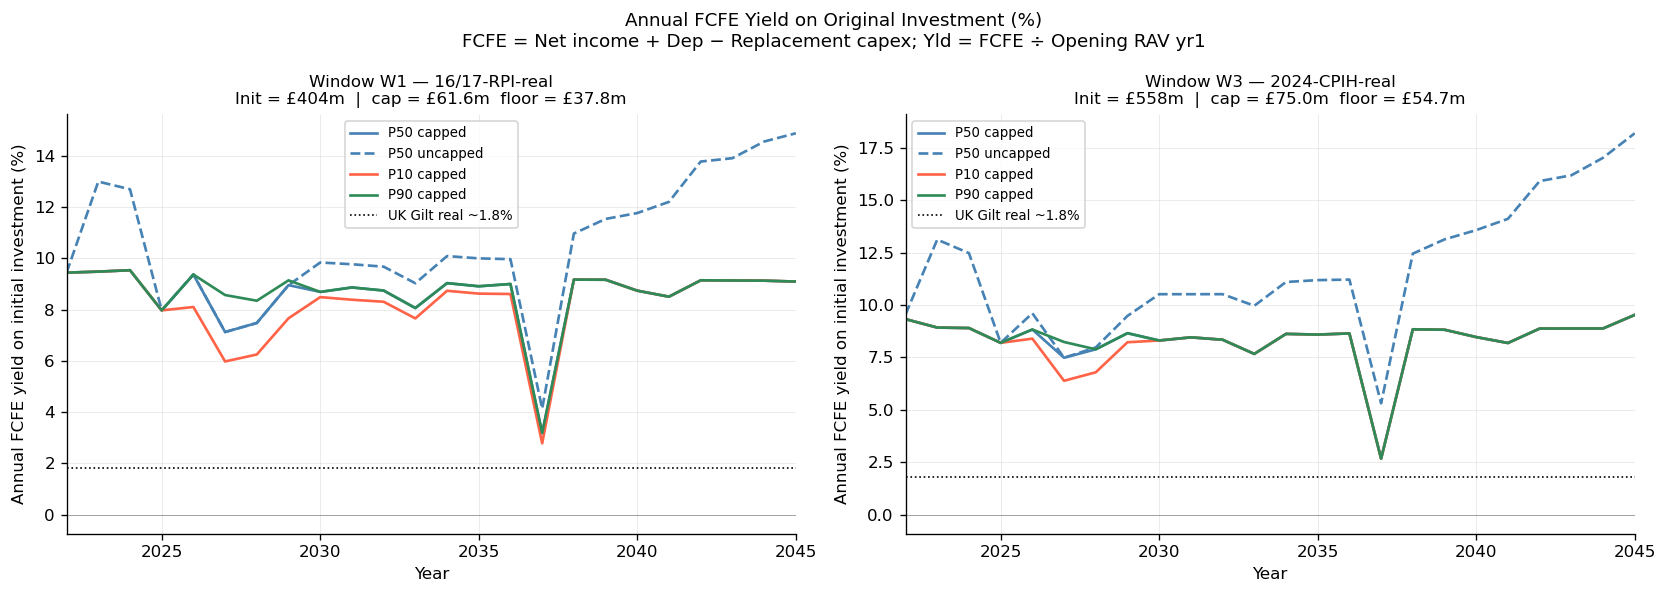

Saved: equity_returns_fcfe.png


In [46]:
# == Section 22: Equity Returns — Annual FCFE and Yield % ================
try:
    import numpy_financial as _nf
    def _irr(cfs):
        try: return _nf.irr(cfs) * 100
        except: return float('nan')
except ImportError:
    def _irr(cfs):
        """Bisection IRR fallback."""
        def _npv(r): return sum(c/(1+r)**t for t,c in enumerate(cfs))
        lo, hi = -0.5, 5.0
        for _ in range(80):
            mid = (lo + hi) / 2
            mid_val = _npv(mid)
            if abs(mid_val) < 1e-8: return mid * 100
            if _npv(lo) * mid_val < 0: hi = mid
            else: lo = mid
        return mid * 100

# ── Cost arrays from IFA2CFFM1_PCR_decision.xlsm  (16/17-RPI-real, £m) ─────
# Regime years 1-25 (2021-2045); source: Allowances Cap + Op RAV sheets.
_YRS    = list(range(2021, 2046))
_W1_OPEX = [15.503,11.901,15.875,15.581,16.551,16.494,16.311,17.490,17.825,18.748,
             18.423,18.444,18.463,18.486,19.264,18.785,18.810,18.843,18.868,19.662,
             19.236,19.268,19.304,19.342,19.534]   # controllable + non-controllable
_W1_DEP  = [16.166,16.166,16.166,16.166,16.166,16.166,16.166,16.303,16.504,16.504,
             16.579,16.579,16.632,16.729,17.085,17.085,17.085,20.023,20.023,20.023,
             20.249,20.863,20.863,20.863,20.863]
_W1_RAV  = [404.16,387.99,371.83,355.66,339.49,323.33,307.16,293.45,280.56,264.06,
             248.69,232.11,216.22,200.75,187.94,170.85,153.77,160.18,140.16,120.14,
             101.25, 83.45, 62.59, 41.73, 20.86]  # opening operational RAV
_W1_RCAP = {2027:2.455,2028:3.416,2030:1.131,2031:0.690,  # replacement capex (Op RAV)
             2032:1.162,2033:3.921,2037:23.501,2040:1.131,2041:2.455}

W1_OPEX  = {yr: _W1_OPEX[i] for i,yr in enumerate(_YRS)}
W1_DEP   = {yr: _W1_DEP[i]  for i,yr in enumerate(_YRS)}
W1_RAV   = {yr: _W1_RAV[i]  for i,yr in enumerate(_YRS)}
W1_RCAP  = {yr: _W1_RCAP.get(yr, 0.0) for yr in _YRS}
W1_INIT  = _W1_RAV[0]   # £404.16m

# W3 costs from iFA2CFFM2_PCR_decision_W3.xlsm Inputs (2024-CPIH-real, £m)
_W3_CTRL  = [17.155,11.849,14.766,14.796,15.515,15.441,15.608,16.589,17.077,17.697,
              17.464,17.495,17.526,17.746,18.220,17.876,17.911,17.947,18.176,18.675,
              18.371,18.412,18.454,18.537,14.018]
_W3_NCTRL = [1.324,1.046,1.036,1.026,1.016,1.007,0.997,0.988,0.979,0.970,
              0.960,0.951,0.943,0.934,0.925,0.916,0.908,0.899,0.891,0.882,
              0.874,0.866,0.858,0.850,0.633]

W3_OPEX  = {yr: _W3_CTRL[i]+_W3_NCTRL[i] for i,yr in enumerate(_YRS)}
W3_DEP   = {yr: W1_DEP[yr] * CFFM2_RPIt.get(yr, _CFFM2_RPIt_MAX) / _cpiht(yr)
             for yr in _YRS}
W3_RAV   = {yr: _W1_RAV[i] * CFFM2_RPIt.get(yr, _CFFM2_RPIt_MAX) / _cpiht(yr)
             for i,yr in enumerate(_YRS)}
W3_RCAP  = {yr: _W1_RCAP.get(yr, 0.0) * CFFM2_RPIt.get(yr, _CFFM2_RPIt_MAX) / _cpiht(yr)
             for yr in _YRS}
W3_INIT  = W3_RAV[2021]

# ── Revenue series: actuals (nominal → real) + MC projections ────────────────
TAX       = 0.25
W1_CAP_R  = 61.6   # 16/17-RPI-real
W1_FLR_R  = 37.8

def _rpit(yr):
    return CFFM2_RPIt.get(yr, _CFFM2_RPIt_MAX)

def _rev_w1(yr, sc_arr):
    """16/17-RPI-real revenue: actual (deflated) or MC percentile."""
    if yr in ACTUALS:
        return ACTUALS[yr] / _rpit(yr)
    if yr >= PROJ_START_YEAR:
        return float(sc_arr[yr - PROJ_START_YEAR])
    return None

def _rev_w3(yr, sc_arr):
    """2024-CPIH-real revenue."""
    if yr in ACTUALS:
        return ACTUALS[yr] / _cpiht(yr)
    if yr >= PROJ_START_YEAR:
        return float(sc_arr[yr - PROJ_START_YEAR]) * _rpit(yr) / _cpiht(yr)
    return None

def _pl(rev, opex, dep, rcap, cap, flr):
    """Return (ni_uncapped, fcfe_uncapped, ni_capped, fcfe_capped)."""
    rev_eff = max(flr, min(rev, cap))
    def _calc(r):
        ebit = r - opex - dep
        ni   = ebit * (1 - TAX) if ebit >= 0 else ebit
        return ni, ni + dep - rcap
    ni_u, fc_u = _calc(rev)
    ni_c, fc_c = _calc(rev_eff)
    return ni_u, fc_u, ni_c, fc_c, rev_eff

# ── Build tables for a given scenario array ──────────────────────────────────
def _build(sc_arr):
    rows = []
    for yr in _YRS:
        r1 = _rev_w1(yr, sc_arr)
        r3 = _rev_w3(yr, sc_arr)
        if r1 is None: continue
        ni1u,fc1u,ni1c,fc1c,r1e = _pl(r1, W1_OPEX[yr], W1_DEP[yr], W1_RCAP[yr], W1_CAP_R, W1_FLR_R)
        ni3u,fc3u,ni3c,fc3c,r3e = _pl(r3, W3_OPEX[yr], W3_DEP[yr], W3_RCAP[yr], W3_CAP_2024, W3_FLR_2024)
        rows.append(dict(yr=yr, ry=yr-2020,
                         r1=r1, r1e=r1e, ni1u=ni1u, fc1u=fc1u, ni1c=ni1c, fc1c=fc1c,
                         r3=r3, r3e=r3e, ni3u=ni3u, fc3u=fc3u, ni3c=ni3c, fc3c=fc3c))
    return rows

# ── Print annual table ────────────────────────────────────────────────────────
def _print(rows, label):
    SEP = '─' * 128
    print(f'\n  {SEP}')
    print(f'  {label}')
    print(f'  Init W1=£{W1_INIT:.0f}m (16/17-real)   Init W3≈£{W3_INIT:.0f}m (2024-CPIH-real)'
          f'   Tax=25%   FCFE=NI+Dep−RplCap   Yld%=FCFE/Init')
    print(f'  {SEP}')
    print(f'  {"Yr":>3} {"Cal":>4}  '
          f'{"── WINDOW 1 (16/17-real £m) ─────────────────────────────────":58}  '
          f'{"── WINDOW 3 (2024-CPIH-real £m) ──────────────────────────────":60}')
    print(f'  {"":>3} {"":>4}  '
          f'{"RevRaw":>8}{"RevEff":>8}{"OPEX":>7}{"Dep":>7}{" NI_u":>7}{"FCFE_u":>7}{"Yld_u":>6}  '
          f'{" NI_c":>7}{"FCFE_c":>7}{"Yld_c":>6}{" NIdiff":>8}  '
          f'{"RevRaw":>8}{"RevEff":>8}{"OPEX":>7}{"Dep":>7}{" NI_u":>7}{"FCFE_u":>7}{"Yld_u":>6}  '
          f'{" NI_c":>7}{"FCFE_c":>7}{"Yld_c":>6}{" NIdiff":>8}')
    print(f'  {SEP}')
    for r in rows:
        f1 = '▲' if r['r1']>W1_CAP_R else ('▼' if r['r1']<W1_FLR_R else ' ')
        f3 = '▲' if r['r3']>W3_CAP_2024 else ('▼' if r['r3']<W3_FLR_2024 else ' ')
        y1u = r['fc1u']/W1_INIT*100; y1c = r['fc1c']/W1_INIT*100
        y3u = r['fc3u']/W3_INIT*100; y3c = r['fc3c']/W3_INIT*100
        print(f'  {r["ry"]:>3} {r["yr"]:>4}  '
              f'{r["r1"]:>8.1f}{f1}{r["r1e"]:>7.1f}{W1_OPEX[r["yr"]]:>7.2f}'
              f'{W1_DEP[r["yr"]]:>7.2f}{r["ni1u"]:>7.2f}{r["fc1u"]:>7.2f}{y1u:>5.1f}%  '
              f'{r["ni1c"]:>7.2f}{r["fc1c"]:>7.2f}{y1c:>5.1f}%{r["ni1c"]-r["ni1u"]:>+8.2f}  '
              f'{r["r3"]:>8.1f}{f3}{r["r3e"]:>7.1f}{W3_OPEX[r["yr"]]:>7.2f}'
              f'{W3_DEP[r["yr"]]:>7.2f}{r["ni3u"]:>7.2f}{r["fc3u"]:>7.2f}{y3u:>5.1f}%  '
              f'{r["ni3c"]:>7.2f}{r["fc3c"]:>7.2f}{y3c:>5.1f}%{r["ni3c"]-r["ni3u"]:>+8.2f}')
    print(f'  {SEP}')
    avg = lambda k: np.mean([r[k] for r in rows])
    y1u_a = avg('fc1u')/W1_INIT*100; y1c_a = avg('fc1c')/W1_INIT*100
    y3u_a = avg('fc3u')/W3_INIT*100; y3c_a = avg('fc3c')/W3_INIT*100
    print(f'  {"AVG":>3} {"":>4}  '
          f'{avg("r1"):>8.1f} {avg("r1e"):>7.1f}{" ":>7}{" ":>7}'
          f'{avg("ni1u"):>7.2f}{avg("fc1u"):>7.2f}{y1u_a:>5.1f}%  '
          f'{avg("ni1c"):>7.2f}{avg("fc1c"):>7.2f}{y1c_a:>5.1f}%{" ":>8}  '
          f'{avg("r3"):>8.1f} {avg("r3e"):>7.1f}{" ":>7}{" ":>7}'
          f'{avg("ni3u"):>7.2f}{avg("fc3u"):>7.2f}{y3u_a:>5.1f}%  '
          f'{avg("ni3c"):>7.2f}{avg("fc3c"):>7.2f}{y3c_a:>5.1f}%')
    # IRR
    for tag, k1, k3 in [('FCFE','fc1c','fc3c'), ('NI only','ni1c','ni3c')]:
        i1 = _irr([-W1_INIT]+[r[k1] for r in rows])
        i3 = _irr([-W3_INIT]+[r[k3] for r in rows])
        i1u = _irr([-W1_INIT]+[r[k1[:-1]+'u'] for r in rows])
        i3u = _irr([-W3_INIT]+[r[k3[:-1]+'u'] for r in rows])
        print(f'  {tag} IRR — W1: uncapped {i1u:.2f}%  capped {i1:.2f}%   '
              f'W3: uncapped {i3u:.2f}%  capped {i3:.2f}%')

# ── Run for P50 / P10 / P90 ──────────────────────────────────────────────────
_print(_build(p50), 'P50 BASE CASE')
_print(_build(p10), 'P10 DOWNSIDE')
_print(_build(p90), 'P90 UPSIDE')

# ── Chart: annual FCFE yield % on original investment ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Annual FCFE Yield on Original Investment (%)\n'
             'FCFE = Net income + Dep − Replacement capex; Yld = FCFE ÷ Opening RAV yr1',
             fontsize=11)

for ax_idx, (wind, init, cap_r, flr_r, rev_fn_name, opex_d, dep_d, rcap_d, basis) in enumerate([
    ('W1', W1_INIT, W1_CAP_R, W1_FLR_R, 'w1', W1_OPEX, W1_DEP, W1_RCAP, '16/17-RPI-real'),
    ('W3', W3_INIT, W3_CAP_2024, W3_FLR_2024, 'w3', W3_OPEX, W3_DEP, W3_RCAP, '2024-CPIH-real'),
]):
    ax = axes[ax_idx]
    rev_fn = _rev_w1 if rev_fn_name == 'w1' else _rev_w3

    for sc_arr, slabel, col, ls in [
        (p50, 'P50 capped',   'steelblue',  '-'),
        (p50, 'P50 uncapped', 'steelblue',  '--'),
        (p10, 'P10 capped',   'tomato',     '-'),
        (p90, 'P90 capped',   'seagreen',   '-'),
    ]:
        is_capped = 'uncapped' not in slabel
        yrs_plot, ylds = [], []
        for yr in _YRS:
            rv = rev_fn(yr, sc_arr)
            if rv is None: continue
            rev_eff = max(flr_r, min(rv, cap_r)) if is_capped else rv
            ebit = rev_eff - opex_d[yr] - dep_d[yr]
            ni   = ebit*(1-TAX) if ebit >= 0 else ebit
            fcfe = ni + dep_d[yr] - rcap_d[yr]
            yrs_plot.append(yr)
            ylds.append(fcfe / init * 100)
        ax.plot(yrs_plot, ylds, color=col, ls=ls, lw=1.6, label=slabel)

    ax.axhline(1.8,  color='black', ls=':', lw=1.0, label='UK Gilt real ~1.8%')
    ax.axhline(0.0,  color='grey',  ls='-', lw=0.4)
    ax.set_title(f'Window {wind} — {basis}\nInit = £{init:.0f}m'
                 f'  |  cap = £{cap_r:.1f}m  floor = £{flr_r:.1f}m', fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylabel('Annual FCFE yield on initial investment (%)')
    ax.legend(fontsize=8)
    ax.set_xlim(2022, 2045)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'equity_returns_fcfe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: equity_returns_fcfe.png')


## Section 22: Model Outputs — Summary and Interpretation

*Run date: 2026-07-09. Price data: GB-FR07.xlsx (extended to 2026-07-07). All monetary values 2016/17-RPI-real GBPm unless stated.*
*Assessment periods shifted to P1=2021–25, P2=2026–30, P3=2031–35, P4=2036–40, P5=2041–45 (5 full years each, matching regulatory cal-year convention). Prior run used P2=2025–29.*
*Price basis: Section 17 inflates projected revenues ×RPIt before writing to CFFM2 ARt; §§19/21 deflate CLt/FLt ÷RPIt before breach comparison. RPIt from CFFM2 Indexation row 11.*

---

### 22.1 Monte Carlo Revenue — Reference Scenario (Annual, 2016/17-RPI-real)

Cap and floor from CFFM2 schedule (deflated by RPIt). Cap ≈ £61.6m real for most of regime; period-boundary resets at 2034 (£62.1m), 2035–40 (£63.6–64.9m), 2041–44 (£60.5–61.3m), 2045 (£45.6m — CFFM2 terminal-year artefact).

| Year | Ryr | P10 | P50 | P90 | Cap (real) | Flr (real) | P < Floor | P > Cap |
|------|-----|-----|-----|-----|-----------|-----------|-----------|---------|
| 2026 | 6 | 58.0 | 65.3 | 73.9 | 61.6 | 37.8 | 0% | **73.2%** |
| 2027 | 7 | 48.3 | 54.7 | 62.7 | 61.6 | 37.8 | 0% | 13.2% |
| 2028 | 8 | 52.5 | 59.3 | 67.6 | 61.6 | 37.8 | 0% | 35.1% |
| 2029 | 9 | 55.7 | 63.0 | 71.4 | 61.6 | 37.8 | 0% | 58.7% |
| 2030 | 10 | 62.6 | 70.0 | 78.9 | 61.6 | 37.8 | 0% | **92.6%** |
| 2031 | 11 | 61.0 | 68.7 | 77.5 | 61.6 | 37.8 | 0% | **87.9%** |
| 2035 | 15 | 62.1 | 69.9 | 78.7 | 63.6 | 39.8 | 0% | **84.8%** |
| 2040 | 20 | 72.5 | 80.7 | 90.2 | 64.9 | 41.3 | 0% | **99.6%** |
| 2045 | 25 | 87.3 | 96.1 | 105.9 | 45.6† | 27.5† | 0% | 100.0%† |

† 2045 CFFM2 terminal-year cap/floor is anomalously low (period-boundary accounting artefact, not a real change in regulatory terms).

Revenue profile: starts at £65.3m P50 in 2026, dips to £54.7m in 2027 (Annex M FR price recovery), then rises monotonically from 2030 (£70m) to 2045 (£96m) as SP Global forecast shows FR prices falling persistently relative to GB. Floor never threatened.

---

### 22.2 OU Model Parameters (Section 11)

| Parameter | Value |
|---|---|
| phi (daily AR) | 0.715 |
| kappa (mean reversion) | 122.8/yr |
| Half-life | 2.1 days |
| sigma_d | 14.99 GBP/MWh |
| Jump phi_Y | 0.629 |
| Jump beta | 169.6/yr |
| Jump half-life | 1.5 days |

---

### 22.3 5-Year NPV Assessment Periods — Window 1 (ODR = 3.945% real, 2016/17-RPI-real)

| Period | Years | P50 NPV Rev | NPV Cap | NPV Floor | P > Cap | P < Floor |
|--------|-------|-------------|---------|-----------|---------|-----------|
| P1 | 2021–2025 | — (actuals) | — | — | — | — |
| P2 | 2026–2030 | £290.4m | £285.5m | £175.0m | 65.1% | 0% |
| P3 | 2031–2035 | £322.4m | £287.7m | £177.2m | **99.7%** | 0% |
| P4 | 2036–2040 | £343.3m | £298.2m | £188.2m | **100.0%** | 0% |
| P5 | 2041–2045 | £421.6m | £268.5m† | £162.1m† | **100.0%** | 0% |

† P5 cap/floor NPV lower than P3/P4 due to CFFM2 period-boundary resets at 2041 and 2044–45 (cap_real drops from £61.6m to £60.5m and £45.6m in 2045).

---

### 22.4 Back-test Capture Ratios (Section 12)

| Year | Sim P10 | Sim P50 | Sim P90 | Actual Gross | Ofgem Net | Impl CR |
|------|---------|---------|---------|--------------|-----------|---------|
| 2024 | 292.6 | 326.5 | 365.8 | 247.6 | 78.7 | **31.8%** |
| 2025 | 230.6 | 261.4 | 299.9 | 270.6 | 54.2 | **20.0%** |
| **Mean** | | | | | | **25.9%** |

2024 actual gross (£247.6m) fell below simulated P10 — model overestimates gross, consistent with RPI deflation compressing panel spreads. Mean CR 25.9% carried forward as market-cost deduction.

---

### 22.5 Against-Price Flow Analysis (Section 5.1)

- **20.0%** of flowing hours saw flow against the price gradient over 2021-12–2026-07 (7,141 hrs)
- Trend: 2022=44% → 2024=7% → 2025=9% → 2026=7.4% (largely a 2022 nuclear-crisis artefact)
- Longest run: 62 continuous hours (Jul 2023, mean spread +£8.72/MWh)
- GCR blended CR (2022–25): **42.2%** vs back-test implied CR **25.9%** — gap reflects against-price hours, auction/spot divergence

---

### 22.6 Central Investment Interpretation

**IFA2 is a cap-heavy asset across all periods. The floor is not load-bearing.**

Revenue trajectory under M2 (Annex M / SP Global FR price path): starts at £65m P50 in 2026, dips temporarily to £55m in 2027 as Annex M shows partial FR price recovery, then rises steadily to £70m (2030) → £80m (2040) → £96m (2045) as SP Global's FR price forecast shows France's wholesale prices falling relative to GB driven by clean energy costs.

| Risk dimension | Model verdict |
|---|---|
| Cap exposure (P2, 2026–30) | 65.1% P>Cap on 5-yr NPV — upside partially clawed back; 2027 trough prevents certainty |
| Cap exposure (P3–P5) | Near-certain (99.7–100%) — rising revenues persistently exceed cap throughout |
| Floor risk | Zero in all periods — P50 revenue stays well above real floor throughout |
| Key uncertainty | 2027 trough driven by Annex M FR price recovery assumption; if FR stays low, P2 breach rises toward P3–P5 levels |
| Scenario sensitivity | Near-zero after 2035 — all scenarios converge as Annex M spreads narrow |

The central insight: the period shift exposes that IFA2 is not merely a P2 cap story — **P3–P5 are also near-certain cap-breach periods** at current model parameters. Revenue rises faster than the RPI-indexed cap from 2030 onwards, making cap clawback structurally persistent across the full 20-year regime.

---

### 22.7 Window 3 PCR Assessment (Section 21)

*W3 template: iFA2CFFM2_PCR_decision_W3.xlsm. Output files: ifa2_w3_pcr_p{10,50,90}.xlsm.*
*All comparisons in 2024-CPIH-real. MC revenues converted from 2016/17-RPI-real via ×RPIt÷CPIHt.*

**W3 constants (2024-CPIH-real):** Cap = PCL £71.04m + PCAC £3.99m = **£75.03m** | Floor = PFL £45.60m + PCAF £9.14m = **£54.74m** (both constant throughout regime)

#### Annual breach probabilities (2024-CPIH-real, selected years)

| Year | W1 Cap | W3 Cap | P10 | P50 | P90 | P>W3Cap | P>W1Cap | P<W3Flr |
|------|--------|--------|-----|-----|-----|---------|---------|---------|
| 2026 | £80.7m | £75.0m | £76.1m | £85.6m | £96.9m | **92.3%** | 73.3% | 0% |
| 2027 | £81.3m | £75.0m | £63.8m | £72.2m | £82.7m | 35.9% | 13.2% | 0.2% |
| 2030 | £83.1m | £75.0m | £84.4m | £94.5m | £106.5m | **99.5%** | 92.6% | 0% |
| 2035 | £86.1m | £75.0m | £86.9m | £97.7m | £110.1m | **99.8%** | 91.6% | 0% |
| 2040 | £89.3m | £75.0m | £105.0m | £117.0m | £130.7m | **100%** | 100% | 0% |
| 2045 | £92.6m | £75.0m | £131.2m | £144.4m | £159.1m | **100%** | 100% | 0% |

#### 5-Year NPV Assessment — W1 vs W3 (2024-CPIH-real, ODR = 3.945%)

| Period | Years | P50 NPV | W1 Cap NPV | W1 P>Cap | W3 Cap NPV | W3 P>Cap | W3 P<Flr |
|--------|-------|---------|-----------|---------|-----------|---------|---------|
| P2 | 2026–2030 | £386.1m | £379.5m | 65.5% | £347.7m | **99.3%** | 0% |
| P3 | 2031–2035 | £444.2m | £393.4m | **99.8%** | £347.7m | **100%** | 0% |
| P4 | 2036–2040 | £490.6m | £407.8m | **100%** | £347.7m | **100%** | 0% |
| P5 | 2041–2045 | £624.5m | £422.7m | **100%** | £347.7m | **100%** | 0% |

W3 NPV per 5-yr period: cap = £347.7m (£75.03m × 4.635 annuity), floor = £253.7m. W1 cap NPV rises each period as RPI outpaces CPIH.

**Key structural difference W1 vs W3:** W3 cap (£75.0m constant) is below W1 cap in 2024-CPIH-real (£80.7m → £92.6m, rising with RPI). W3 is therefore more restrictive on the cap side in P2 (99.3% vs 65.5%) but equally binding in P3–P5 where both hit 100%. Floor never triggered under either regime.

### Open Questions

---

**Open Question 1: Why do net profits exceed 8.1% x RAV?**

The 8.1% applied to the GBP362m RAV gives a return component of GBP29.5m real (~GBP40m nominal). Net profits in capped years are GBP60-62m — roughly double. Three layers explain this:

**Layer 1 — The 8.1% is only the return component, not the full cap allowance.** CLt also covers opex recovery (~GBP11m real) and depreciation (~GBP14.5m real). After paying actual opex and tax from Turnover, net profit equals the after-tax return *plus* the depreciation add-back (depreciation is expensed in the P&L but the cash was already received through revenue). This mechanically lifts accounting profit above 8.1% x RAV.

**Layer 2 — The cap operates on a 5-year NPV basis, not annually.** Individual years are unconstrained. The 2023 Turnover (GBP101m) can exceed the estimated annual cap allowance (GBP95m nominal) without a breach as long as the 5-year NPV does not exceed the NPV of cap allowances. The 2025 accounts — large admin cost spike (GBP44m vs GBP32m prior year) plus a GBP37m implied settlement — are consistent with a period-end reckoning.